<a href="https://colab.research.google.com/github/juuaa01/Pengantar-Penambangan-Data-/blob/main/Pengantar-Penambangan-Data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**CAPSTONE PROJEK 1 MATA KULIAH DATA MINING**

KELOMPOK B
1. Muhamad Riyo Dwi Pangga (11230940000048)
2. Nazwah Laeza Camelia (11230940000034)
3. Levina Vita Damayanti (11230940000013)
4. Titi Pramudita Wijayanti (11230940000041)

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

try: # Running Locally, yakinkan "file_" berada di folder "data"
    dfJ = pd.read_csv("data/jakarta.csv")
    dfD = pd.read_csv("data/depok.csv")
    dfB = pd.read_csv("data/bogor.csv")
    dfT = pd.read_csv("data/tangerang.csv")
    dfX = pd.read_csv("data/bekasi.csv")
except: # Running in Google Colab
    !mkdir datas
    !wget -P data/ https://raw.githubusercontent.com/taudataanalytics/Data-Mining--Penambangan-Data--Ganjil-2024/master/data/jakarta.csv
    !wget -P data/ https://raw.githubusercontent.com/taudataanalytics/Data-Mining--Penambangan-Data--Ganjil-2024/master/data/depok.csv
    !wget -P data/ https://raw.githubusercontent.com/taudataanalytics/Data-Mining--Penambangan-Data--Ganjil-2024/master/data/bogor.csv
    !wget -P data/ https://raw.githubusercontent.com/taudataanalytics/Data-Mining--Penambangan-Data--Ganjil-2024/master/data/tangerang.csv
    !wget -P data/ https://raw.githubusercontent.com/taudataanalytics/Data-Mining--Penambangan-Data--Ganjil-2024/master/data/bekasi.csv
    dfJ = pd.read_csv("data/jakarta.csv")
    dfD = pd.read_csv("data/depok.csv")
    dfB = pd.read_csv("data/bogor.csv")
    dfT = pd.read_csv("data/tangerang.csv")
    dfX = pd.read_csv("data/bekasi.csv")

dfJ.shape, dfD.shape, dfB.shape, dfT.shape, dfX.shape

--2025-09-30 13:01:44--  https://raw.githubusercontent.com/taudataanalytics/Data-Mining--Penambangan-Data--Ganjil-2024/master/data/jakarta.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.111.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.111.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 63832 (62K) [text/plain]
Saving to: ‘data/jakarta.csv’

jakarta.csv         100%[===================>]  62.34K  --.-KB/s    in 0.06s   

2025-09-30 13:01:44 (976 KB/s) - ‘data/jakarta.csv’ saved [63832/63832]

--2025-09-30 13:01:44--  https://raw.githubusercontent.com/taudataanalytics/Data-Mining--Penambangan-Data--Ganjil-2024/master/data/depok.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.109.133, 185.199.110.133, 185.199.108.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.109.133|:443... connected.
H

((1024, 26), (998, 26), (999, 26), (128, 26), (992, 26))

# **Menangani Missing Value**

In [ ]:
# Melihat Informasi Tiap Data
print(dfJ.info(), dfD.info(), dfB.info(), dfT.info(), dfX.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1024 entries, 0 to 1023
Data columns (total 26 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   created_at   121 non-null    object 
 1   LT           121 non-null    float64
 2   LB           121 non-null    float64
 3   KT           121 non-null    float64
 4   KM           121 non-null    float64
 5   garasi       44 non-null     float64
 6   carport      90 non-null     float64
 7   lokasi       121 non-null    object 
 8   sertifikat   119 non-null    object 
 9   listrik      120 non-null    float64
 10  hadap        36 non-null     object 
 11  harga        121 non-null    float64
 12  URL          121 non-null    object 
 13  deskripsi    112 non-null    object 
 14  Unnamed: 14  0 non-null      float64
 15  Unnamed: 15  0 non-null      float64
 16  Unnamed: 16  0 non-null      float64
 17  Unnamed: 17  0 non-null      float64
 18  Unnamed: 18  0 non-null      float64
 19  Unname

Berdasarkan pemeriksaan diatas didapatkan 12 kolom tidak terdefinisi dimasing-masing dataset dengan semua entry berisi NaN.

In [ ]:
# Menghapus Kolom Unnamed 14-25 di Setiap Data karena Missing value semua
dfJ_baru = dfJ.drop(dfJ.columns[14:26], axis=1)
dfD_baru = dfD.drop(dfD.columns[14:26], axis=1)
dfB_baru = dfB.drop(dfB.columns[14:26], axis=1)
dfT_baru = dfT.drop(dfT.columns[14:26], axis=1)
dfX_baru = dfX.drop(dfX.columns[14:26], axis=1)

In [ ]:
# Melihat Informasi Baru Tiap Data
print(dfJ_baru.info(), dfD_baru.info(), dfB_baru.info(), dfT_baru.info(), dfX_baru.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1024 entries, 0 to 1023
Data columns (total 14 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   created_at  121 non-null    object 
 1   LT          121 non-null    float64
 2   LB          121 non-null    float64
 3   KT          121 non-null    float64
 4   KM          121 non-null    float64
 5   garasi      44 non-null     float64
 6   carport     90 non-null     float64
 7   lokasi      121 non-null    object 
 8   sertifikat  119 non-null    object 
 9   listrik     120 non-null    float64
 10  hadap       36 non-null     object 
 11  harga       121 non-null    float64
 12  URL         121 non-null    object 
 13  deskripsi   112 non-null    object 
dtypes: float64(8), object(6)
memory usage: 112.1+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 998 entries, 0 to 997
Data columns (total 14 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  ----

In [ ]:
# Melihat 5 data teratas di Jakarta
dfJ_baru.head()

,created_at,LT,LB,KT,KM,garasi,carport,lokasi,sertifikat,listrik,hadap,harga,URL,deskripsi
0,06-12-2021,202.0,198.0,8.0,3.0,NaN,NaN,Jakarta Pusat,SHM,2200.0,NaN,4.500000e+09,https://www.rumah.com/listing-properti/dijual-...,Dekat Cikini Salemba Taman Isamail Marzuki Kam...
1,02-12-2021,30.0,55.0,2.0,1.0,NaN,1.0,Jakarta Pusat,SHM,2200.0,NaN,1.100000e+09,https://www.rumah.com/listing-properti/dijual-...,"Mengusung konsep minimalis, dan didukung denga..."
2,06-12-2021,19.0,35.0,2.0,1.0,NaN,NaN,Jakarta Pusat,SHM,2200.0,NaN,3.950000e+08,https://www.rumah.com/listing-properti/dijual-...,"Dekat dengan Mall Atrium Senen, dekat dengan a..."
3,06-12-2021,33.0,42.0,2.0,2.0,NaN,1.0,Jakarta Pusat,SHM,2200.0,NaN,8.350000e+08,https://www.rumah.com/listing-properti/dijual-...,"Berlokasi sangat strategis, sangat dekat ke Tu..."
4,06-12-2021,30.0,55.0,2.0,2.0,NaN,1.0,Jakarta Pusat,SHM,2200.0,NaN,1.100000e+09,https://www.rumah.com/listing-properti/dijual-...,"Bisa request ubah tata ruang, beli 2 unit mend..."


In [ ]:
# Melihat 5 data teratas di Bekasi
dfX_baru.head()

,created_at,LT,LB,KT,KM,garasi,carport,lokasi,sertifikat,listrik,hadap,harga,URL,deskripsi
0,08-12-2021,71.0,43.0,2.0,1.0,NaN,1.0,Kabupaten Bekasi,SHM,1300.0,NaN,5.500000e+08,Rumah murah di metland cibitung bekasi - Dijua...,"Selangkah ke stasiun krl telaga murni, Dekat d..."
1,08-12-2021,59.0,60.0,2.0,1.0,NaN,1.0,Kabupaten Bekasi,SHM,NaN,NaN,4.400000e+08,Rumah dijual di Griya gandasari cibitung - Dij...,"Rumah sangat nyaman,dan terbukti bebas banjir,..."
2,08-12-2021,124.0,95.0,2.0,1.0,NaN,1.0,Kabupaten Bekasi,SHM,NaN,NaN,6.990000e+08,Jual cepat rumah huuk di metland cibitung beka...,"Bebas banjir, Carport dan tanah luas ada taman..."
3,08-12-2021,144.0,100.0,2.0,1.0,NaN,1.0,Kabupaten Bekasi,SHM,2200.0,Selatan,1.350000e+09,https://www.realoka.com/216243-rumah-rapi-siap...,(Harapan Indah) Cluster Aralia Kota Harapan In...
4,08-12-2021,108.0,100.0,3.0,2.0,NaN,1.0,Kabupaten Bekasi,SHM,2200.0,Timur,1.400000e+09,https://www.realoka.com/207964-jual-rumah-bagu...,(Harapan Indah) Cluster Harmoni Perumahan Kota...


In [ ]:
# Melihat 5 data teratas di Tangerang
dfT_baru.head()

,created_at,LT,LB,KT,KM,garasi,carport,lokasi,sertifikat,listrik,hadap,harga,URL,deskripsi
0,12-06-2021,60.0,50.0,3.0,2.0,NaN,NaN,"BSD CITY, TANGERANG",SHM,1300.0,Selatan,500.0,https://www.rumah123.com/properti/tangerang/ho...,"Rumah 2 Lantai Akses Strategis, Keamanan 24jam..."
1,12-06-2021,72.0,54.0,2.0,1.0,1.0,1.0,"CISAUK, TANGERANG",SHM,1300.0,NaN,480.0,https://www.rumah123.com/properti/tangerang/ho...,"lokasi strategis dekat gading serpong, dekat a..."
2,12-06-2021,60.0,48.0,3.0,2.0,2.0,2.0,"CILEDUG, TANGERANG",SHM,2200.0,NaN,600.0,https://www.rumah123.com/properti/tangerang/ho...,"Boston Village Bintaro, Cluster dengan konsep ..."
3,12-06-2021,200.0,225.0,5.0,4.0,NaN,NaN,"LIPPO KARAWACI, TANGERANG",SHM,5500.0,NaN,4250.0,https://www.rumah123.com/properti/tangerang/ho...,"DIJUAL RUMAH BARU SELESAI DIBANGUN, LIPPO KARA..."
4,12-06-2021,76.0,123.0,3.0,3.0,NaN,2.0,"PONDOK CABE, TANGERANG",SHM,2200.0,NaN,1700.0,https://www.rumah123.com/properti/tangerang/ho...,"diapit oleh 3 tol besar, JOR 2, Cinere-Jagoraw..."


In [ ]:
# Melihat 5 data teratas di Bogor
dfB_baru.head()

,created_at,LT,LB,KT,KM,garasi,carport,lokasi,sertifikat,listrik,hadap,harga,URL,deskripsi
0,03-12-2021,75.0,38.0,2.0,1.0,1.0,1.0,Bojonggede,SHM,1300.0,Barat,6.925500e+08,https://rumahdijual.com/bekasi/10799791-rumah-...,"Dekat tol jati warna, dekat sutle busway, deka..."
1,06-12-2021,60.0,40.0,1.0,1.0,0.0,1.0,Babakan Madang,SHM,2200.0,NaN,8.114000e+08,https://www.rumah123.com/perumahan-baru/proper...,Destinasi menarik di kawasan Babakan Madang; G...
2,06-12-2021,60.0,50.0,2.0,2.0,0.0,1.0,Babakan Madang,SHM,2200.0,NaN,9.005000e+08,https://www.rumah123.com/perumahan-baru/proper...,Destinasi menarik di kawasan Babakan Madang; G...
3,06-12-2021,60.0,70.0,3.0,2.0,0.0,1.0,Babakan Madang,SHM,2200.0,NaN,1.001900e+09,https://www.rumah123.com/perumahan-baru/proper...,Destinasi menarik di kawasan Babakan Madang; G...
4,06-12-2021,90.0,60.0,3.0,2.0,0.0,2.0,Babakan Madang,SHM,2200.0,NaN,1.200800e+09,https://www.rumah123.com/perumahan-baru/proper...,Destinasi menarik di kawasan Babakan Madang; G...


In [ ]:
# Melihat 5 data teratas di Depok
dfD_baru.head()

,created_at,LT,LB,KT,KM,garasi,carport,lokasi,sertifikat,listrik,hadap,harga,URL,deskripsi
0,6-12-2021,165,200.0,4.0,2.0,NaN,1.0,Sukmajaya,SHM,2200.0,Selatan,2100.0,https://www.rumah123.com/properti/depok/hos928...,Rumah siap huni komplek Pelni
1,6-12-2021,50,45.0,2.0,1.0,NaN,NaN,Cipayung,SHM,1300.0,NaN,250.0,https://www.rumah123.com/properti/depok/hos928...,rumah minimalis termurah di citayam
2,6-12-2021,50,36.0,2.0,1.0,NaN,1.0,Sawangan,SHM,1300.0,Barat,250.0,https://www.rumah123.com/properti/depok/hos928...,CLUSTER TERMURAH DI SAWANGAN KOTA DEPOK
3,6-12-2021,50,45.0,2.0,1.0,NaN,NaN,Cimanggis,SHM,1300.0,NaN,250.0,https://www.rumah123.com/properti/depok/hos928...,RUMAH SIAP HUNI HARGA NEGO DEKAT STASIUN CITAYAM
4,6-12-2021,72,45.0,2.0,1.0,NaN,1.0,Sawangan,SHM,1300.0,Timur,350.0,https://www.rumah123.com/properti/depok/hos928...,Rumah Cluster Siap Huni Depok


,LT,LB,KT,KM,garasi,carport,listrik,harga
count,121.000000,121.000000,121.000000,121.000000,44.000000,90.000000,120.000000,1.210000e+02
mean,247.586777,279.495868,4.272727,3.380165,1.863636,1.955556,5425.000000,8.985955e+09
std,368.384642,285.275631,1.901754,1.709075,1.518734,1.475730,7891.589502,1.587610e+10
min,16.000000,21.000000,1.000000,1.000000,1.000000,1.000000,900.000000,3.800000e+08
25%,84.000000,97.000000,3.000000,2.000000,1.000000,1.000000,2200.000000,1.600000e+09
50%,135.000000,200.000000,4.000000,3.000000,1.000000,2.000000,3500.000000,3.400000e+09
75%,250.000000,350.000000,5.000000,4.000000,2.000000,2.000000,4425.000000,7.250000e+09
max,3422.000000,2000.000000,10.000000,10.000000,8.000000,10.000000,66000.000000,1.050000e+11


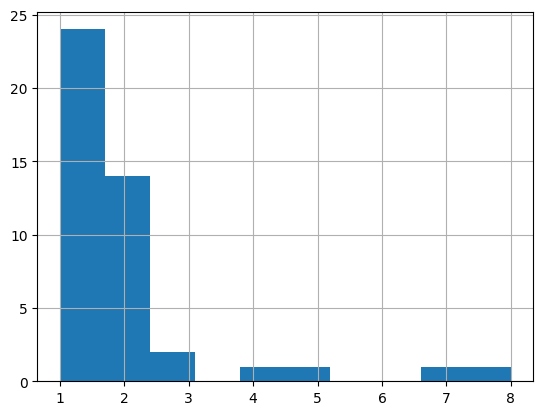

In [ ]:
dfJ_baru['garasi'].hist()
dfJ_baru.describe()

In [ ]:
dfJ_baru['garasi'].value_counts()

,count
garasi,
1.0,24
2.0,14
3.0,2
4.0,1
7.0,1
8.0,1
5.0,1


In [ ]:
dfJ.isnull()

,created_at,LT,LB,KT,KM,garasi,carport,lokasi,sertifikat,listrik,...,Unnamed: 16,Unnamed: 17,Unnamed: 18,Unnamed: 19,Unnamed: 20,Unnamed: 21,Unnamed: 22,Unnamed: 23,Unnamed: 24,Unnamed: 25
0,False,False,False,False,False,True,True,False,False,False,...,True,True,True,True,True,True,True,True,True,True
1,False,False,False,False,False,True,False,False,False,False,...,True,True,True,True,True,True,True,True,True,True
2,False,False,False,False,False,True,True,False,False,False,...,True,True,True,True,True,True,True,True,True,True
3,False,False,False,False,False,True,False,False,False,False,...,True,True,True,True,True,True,True,True,True,True
4,False,False,False,False,False,True,False,False,False,False,...,True,True,True,True,True,True,True,True,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1019,True,True,True,True,True,True,True,True,True,True,...,True,True,True,True,True,True,True,True,True,True
1020,True,True,True,True,True,True,True,True,True,True,...,True,True,True,True,True,True,True,True,True,True
1021,True,True,True,True,True,True,True,True,True,True,...,True,True,True,True,True,True,True,True,True,True
1022,True,True,True,True,True,True,True,True,True,True,...,True,True,True,True,True,True,True,True,True,True


Berdasarkan pemeriksaan diatas ditemukan juga baris-baris berisi full NaN

In [ ]:
# Menghapus Baris yang Berisi Missing Value Semua ditiap Kolom
dfJ_2 = dfJ_baru.dropna(how = 'all')
dfB_2 = dfB_baru.dropna(how = 'all')
dfD_2 = dfD_baru.dropna(how = 'all')
dfT_2 = dfT_baru.dropna(how = 'all')
dfX_2 = dfX_baru.dropna(how = 'all')

Akhirnya kami memutuskan untuk menghapus baris-baris yang berisi NaN disemua kolom. Berikut merupakan sisa NaN pada baris dan kolom setelah dihapus.

In [ ]:
dfs1 = {
    "dfJ_2": dfJ_2,
    "dfX_2": dfX_2,
    "dfT_2": dfT_2,
    "dfB_2": dfB_2,
    "dfD_2": dfD_2
}

# Gabungkan jumlah NaN (hasilnya otomatis horizontal)
null_count = pd.DataFrame({name: df.isnull().sum() for name, df in dfs1.items()})
display(null_count)

,dfJ_2,dfX_2,dfT_2,dfB_2,dfD_2
created_at,0,0,0,0,1
LT,0,0,0,0,0
LB,0,0,0,0,2
KT,0,0,0,0,2
KM,0,1,0,0,2
garasi,77,74,86,0,95
carport,31,26,32,0,26
lokasi,0,0,0,0,2
sertifikat,2,1,2,0,2
listrik,1,6,13,0,17


In [ ]:
dfs2 = {
    "dfJ_2": dfJ_2,
    "dfX_2": dfX_2,
    "dfT_2": dfT_2,
    "dfB_2": dfB_2,
    "dfD_2": dfD_2
}

# Gabungkan persentase NaN lalu transpose agar melebar ke kanan
null_percent = pd.DataFrame({name: (df.isnull().sum() / len(df) * 100)
                             for name, df in dfs2.items()})
display(null_percent.round(2))   # dibulatkan 2 desimal

,dfJ_2,dfX_2,dfT_2,dfB_2,dfD_2
created_at,0.00,0.00,0.00,0.00,0.83
LT,0.00,0.00,0.00,0.00,0.00
LB,0.00,0.00,0.00,0.00,1.67
KT,0.00,0.00,0.00,0.00,1.67
KM,0.00,0.93,0.00,0.00,1.67
garasi,63.64,69.16,69.35,0.00,79.17
carport,25.62,24.30,25.81,0.00,21.67
lokasi,0.00,0.00,0.00,0.00,1.67
sertifikat,1.65,0.93,1.61,0.00,1.67
listrik,0.83,5.61,10.48,0.00,14.17


Dapat dilihat pada hasil dua tabel diatas, masih terdapat banyak nilai NaN pada kelima data yang ada. Dengan kolom yang memiliki Nilai NaN yang banyak ada pada Garasi (dengan rata-rata dari kelima data 70%), Hadap (dengan rata-rata dari kelima data 60%), dan Carport (dengan rata-rata dari kelima data 20%).

In [ ]:
import pandas as pd

dfs1 = {
    "dfJ_2": dfJ_2,
    "dfX_2": dfX_2,
    "dfT_2": dfT_2,
    "dfB_2": dfB_2,
    "dfD_2": dfD_2
}

# Hitung jumlah duplikat untuk setiap DataFrame
dup_count = {name: df.duplicated().sum() for name, df in dfs1.items()}

# Masukkan ke DataFrame biar rapi
dup_summary = pd.DataFrame.from_dict(dup_count, orient="index", columns=["Jumlah Duplikat"])
display(dup_summary)


,Jumlah Duplikat
dfJ_2,0
dfX_2,0
dfT_2,0
dfB_2,0
dfD_2,0


In [ ]:
dfJ_2['hadap'].value_counts()

,count
hadap,
Timur,10
Utara,10
Selatan,5
Barat,4
timur,2
timur utara,1
Selatan & Barat,1
Timur Laut,1
Barat & Selatan,1


In [ ]:
dfX_2['hadap'].value_counts()

,count
hadap,
Selatan,23
Timur,16
Utara,5
Barat,4


In [ ]:
dfT_2['hadap'].value_counts()

,count
hadap,
Utara,18
Selatan,12
Timur,7
Tenggara,4
Barat,4
Timur Laut,3
Barat Daya,1


In [ ]:
dfB_2['hadap'].value_counts()

,count
hadap,
Selatan,5
Timur,5
Barat,3
Utara,3
"Timur, Utara",1
"Selatan, Utara",1
Danau,1


In [ ]:
dfD_2['hadap'].value_counts()

,count
hadap,
Utara,19
Barat,15
Timur,15
Selatan,11
Barat Daya,1
Timur Laut,1


Kami melakukan pemeriksaan keragaman kategori yang tersedia pada kolom hadap di masing-masing data, dan didapatkan beragam format yang berbeda sehingga kami memutuskan untuk menghapus kolom hadap. Selain itu kami juga memutuskan untuk menghapus kolom garasi dikarenakan jumlah *Missing Value* yang melebihi setengahnya dari jumlah entri pada kolom tersebut.

In [ ]:
dfJ_22 = dfJ_2.drop(dfJ_2.columns[10], axis=1)
dfB_22 = dfB_2.drop(dfB_2.columns[10], axis=1)
dfD_22 = dfD_2.drop(dfD_2.columns[10], axis=1)
dfT_22 = dfT_2.drop(dfT_2.columns[10], axis=1)
dfX_22 = dfX_2.drop(dfX_2.columns[10], axis=1)

In [ ]:
dfJ_3 = dfJ_22.drop(dfJ_2.columns[5], axis=1)
dfB_3 = dfB_22.drop(dfB_2.columns[5], axis=1)
dfD_3 = dfD_22.drop(dfD_2.columns[5], axis=1)
dfT_3 = dfT_22.drop(dfT_2.columns[5], axis=1)
dfX_3 = dfX_22.drop(dfX_2.columns[5], axis=1)

In [ ]:
dfJ_3

,created_at,LT,LB,KT,KM,carport,lokasi,sertifikat,listrik,harga,URL,deskripsi
0,06-12-2021,202.0,198.0,8.0,3.0,NaN,Jakarta Pusat,SHM,2200.0,4.500000e+09,https://www.rumah.com/listing-properti/dijual-...,Dekat Cikini Salemba Taman Isamail Marzuki Kam...
1,02-12-2021,30.0,55.0,2.0,1.0,1.0,Jakarta Pusat,SHM,2200.0,1.100000e+09,https://www.rumah.com/listing-properti/dijual-...,"Mengusung konsep minimalis, dan didukung denga..."
2,06-12-2021,19.0,35.0,2.0,1.0,NaN,Jakarta Pusat,SHM,2200.0,3.950000e+08,https://www.rumah.com/listing-properti/dijual-...,"Dekat dengan Mall Atrium Senen, dekat dengan a..."
3,06-12-2021,33.0,42.0,2.0,2.0,1.0,Jakarta Pusat,SHM,2200.0,8.350000e+08,https://www.rumah.com/listing-properti/dijual-...,"Berlokasi sangat strategis, sangat dekat ke Tu..."
4,06-12-2021,30.0,55.0,2.0,2.0,1.0,Jakarta Pusat,SHM,2200.0,1.100000e+09,https://www.rumah.com/listing-properti/dijual-...,"Bisa request ubah tata ruang, beli 2 unit mend..."
...,...,...,...,...,...,...,...,...,...,...,...,...
116,22-11-2021,220.0,239.0,5.0,4.0,2.0,Jakarta Timur,PPJB,3500.0,3.850000e+09,https://www.rumah.com/listing-properti/dijual-...,Rumah Mewah siap huni 2 lantai 220m 10x22 type...
117,06-12-2021,70.0,57.0,3.0,2.0,2.0,Jakarta Timur,SHM,2200.0,8.800000e+08,https://www.rumah.com/listing-properti/dijual-...,Rumah Signature Location & Access :\n• 2 Menit...
118,06-12-2021,315.0,280.0,4.0,3.0,2.0,Jakarta Timur,SHM + IMB,3500.0,4.300000e+09,https://www.rumah.com/listing-properti/dijual-...,"Rumah 1, 5 Lantai Luas Strategis di Pondok Bam..."
119,06-12-2021,135.0,190.0,5.0,5.0,2.0,Jakarta Timur,SHM + IMB,2200.0,3.400000e+09,https://www.rumah.com/listing-properti/dijual-...,Rumah Baru Non Komplek Posisi Hook Lokasi Stra...


In [ ]:
dfs3 = {
    "dfJ_3": dfJ_3,
    "dfX_3": dfX_3,
    "dfT_3": dfT_3,
    "dfB_3": dfB_3,
    "dfD_3": dfD_3
}

# Gabungkan jumlah NaN (hasilnya otomatis horizontal)
null_count = pd.DataFrame({name: df.isnull().sum() for name, df in dfs3.items()})
display(null_count)

,dfJ_3,dfX_3,dfT_3,dfB_3,dfD_3
created_at,0,0,0,0,1
LT,0,0,0,0,0
LB,0,0,0,0,2
KT,0,0,0,0,2
KM,0,1,0,0,2
carport,31,26,32,0,26
lokasi,0,0,0,0,2
sertifikat,2,1,2,0,2
listrik,1,6,13,0,17
harga,0,0,0,0,2


In [ ]:
dfs4 = {
    "dfJ_3": dfJ_3,
    "dfX_3": dfX_3,
    "dfT_3": dfT_3,
    "dfB_3": dfB_3,
    "dfD_3": dfD_3
}

# Gabungkan persentase NaN lalu transpose agar melebar ke kanan
null_percent = pd.DataFrame({name: (df.isnull().sum() / len(df) * 100)
                             for name, df in dfs4.items()})
display(null_percent.round(2))   # dibulatkan 2 desimal

,dfJ_3,dfX_3,dfT_3,dfB_3,dfD_3
created_at,0.00,0.00,0.00,0.0,0.83
LT,0.00,0.00,0.00,0.0,0.00
LB,0.00,0.00,0.00,0.0,1.67
KT,0.00,0.00,0.00,0.0,1.67
KM,0.00,0.93,0.00,0.0,1.67
carport,25.62,24.30,25.81,0.0,21.67
lokasi,0.00,0.00,0.00,0.0,1.67
sertifikat,1.65,0.93,1.61,0.0,1.67
listrik,0.83,5.61,10.48,0.0,14.17
harga,0.00,0.00,0.00,0.0,1.67


Diatas kami melakukan pemeriksaan *Missing Value* ulang setelah melakukan pembersihan di masing-masing data, dan didapatkan kolom carport dengan Missing Value yang masih cukup tinggi namun kurang dari 50%. Selain itu kami juga menemukan sebuah keanehan pada data Depok dengan persentase *Missing Value* yang sama pada angka 1,67 dibeberapa variabelnya.

## Menangani Missing Value pada Kolom carport

In [ ]:
dfJ_3['carport'].value_counts()

,count
carport,
1.0,39
2.0,38
3.0,6
4.0,2
6.0,2
5.0,1
8.0,1
10.0,1


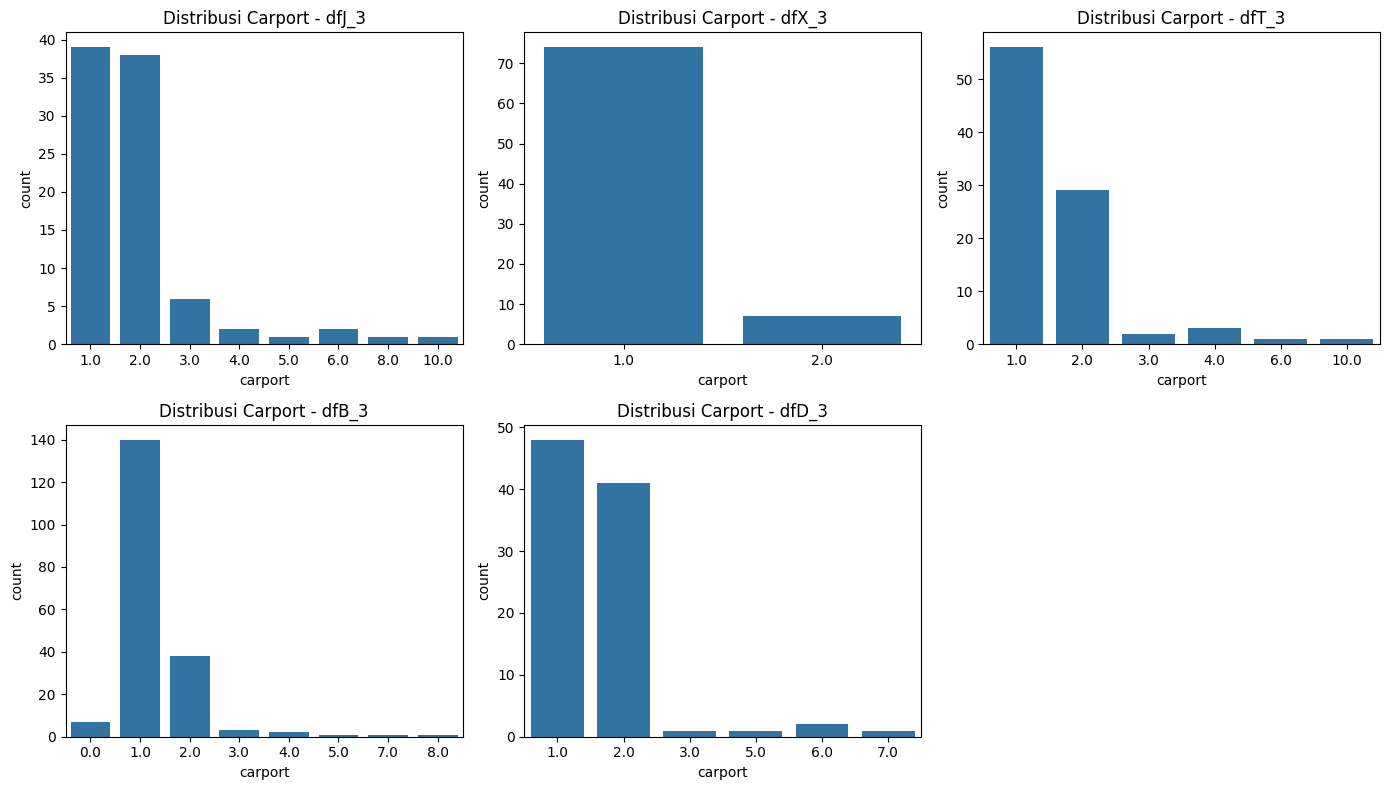

In [ ]:
# Bikin figure
plt.figure(figsize=(14, 8))

# Plot 1
plt.subplot(2, 3, 1)
sns.countplot(x="carport", data=dfJ_3)
plt.title("Distribusi Carport - dfJ_3")

# Plot 2
plt.subplot(2, 3, 2)
sns.countplot(x="carport", data=dfX_3)
plt.title("Distribusi Carport - dfX_3")

# Plot 3
plt.subplot(2, 3, 3)
sns.countplot(x="carport", data=dfT_3)
plt.title("Distribusi Carport - dfT_3")

# Plot 4
plt.subplot(2, 3, 4)
sns.countplot(x="carport", data=dfB_3)
plt.title("Distribusi Carport - dfB_3")

# Plot 5
plt.subplot(2, 3, 5)
sns.countplot(x="carport", data=dfD_3)
plt.title("Distribusi Carport - dfD_3")

plt.tight_layout()
plt.show()

In [ ]:
dfJ_3['carport'] = dfJ_3['carport'].fillna(dfJ_3['carport'].mode()[0])
dfX_3['carport'] = dfX_3['carport'].fillna(dfX_3['carport'].mode()[0])
dfT_3['carport'] = dfT_3['carport'].fillna(dfT_3['carport'].mode()[0])
dfB_3['carport'] = dfB_3['carport'].fillna(dfB_3['carport'].mode()[0])
dfD_3['carport'] = dfD_3['carport'].fillna(dfD_3['carport'].mode()[0])

Setelah melakukan pemeriksaan distribusi pada kolom carport disetiap data, kami memutuskan untuk melakukan imputasi dengan modus pada variabel carport. Semua data memiliki modus yang sama pada variabel carport yaitu 1.

## Menangani Missing Value pada Kolom Sertifikat

In [ ]:
print(dfJ_3['sertifikat'].isnull().sum())

2


In [ ]:
dfJ_3['sertifikat'].value_counts()

,count
sertifikat,
SHM,90
SHM + IMB,11
SHGB,8
PPJB,7
SHM + IMB + PBB,1
SHM + Hak Pakai,1
AJB,1


In [ ]:
dfJ_3[dfJ_3['sertifikat'].isna()]


,created_at,LT,LB,KT,KM,carport,lokasi,sertifikat,listrik,harga,URL,deskripsi
94,07-12-2021,120.0,160.0,3.0,3.0,1.0,Jakarta Utara,NaN,4400.0,4.500000e+09,https://www.rumah123.com/properti/jakarta-utar...,"Baru! Rumah PIK 2, Cluster Scarlet Type Amaryl..."
109,25-11-2021,69.0,102.0,3.0,2.0,2.0,Jakarta Timur,NaN,2200.0,2.230000e+09,https://www.rumah123.com/properti/jakarta-timu...,"Cluster La Seine Type 6, Jakarta Garden City, ..."


In [ ]:
dfT_3['sertifikat'].value_counts()

,count
sertifikat,
SHM,96
"lainnya(PPJB, GIRIK, ADAT, dll)",15
HGB,11


In [ ]:
dfT_3[dfT_3['sertifikat'].isna()]

,created_at,LT,LB,KT,KM,carport,lokasi,sertifikat,listrik,harga,URL,deskripsi
20,12-06-2021,276.0,441.0,4.0,4.0,2.0,"BSD CITY, TANGERANG",NaN,11000.0,13000.0,https://www.rumah123.com/properti/tangerang/ho...,Miliki Hunian Eksklusif dengan akses langsung ...
100,12-06-2021,3087.0,2500.0,5.0,5.0,10.0,"BSD BUKIT GOLF, TANGERANG",NaN,66000.0,100000.0,https://www.rumah123.com/properti/tangerang/ho...,Rumah Super Mewah Bukit Golf BSD City rumah me...


In [ ]:
dfB_3['sertifikat'].value_counts()

,count
sertifikat,
SHM,155
SHGB,33
Lainnya,5


In [ ]:
dfB_3[dfB_3['sertifikat'].isna()]

,created_at,LT,LB,KT,KM,carport,lokasi,sertifikat,listrik,harga,URL,deskripsi


In [ ]:
dfX_3['sertifikat'].value_counts()

,count
sertifikat,
SHM,95
HGB,9
"SHM,IMB",2


In [ ]:
dfX_3[dfX_3['sertifikat'].isna()]

,created_at,LT,LB,KT,KM,carport,lokasi,sertifikat,listrik,harga,URL,deskripsi
76,03-12-2021,364.0,494.0,5.0,NaN,1.0,Kota Bekasi,NaN,NaN,2.485000e+09,https://www.iklanrumah.com/list/detail/37392/r...,Rumah Mewah Pondok Pekayon Indah Siap Huni di ...


In [ ]:
dfD_3['sertifikat'].value_counts()

,count
sertifikat,
SHM,116
Lainnya,2


In [ ]:
dfD_3[dfD_3['sertifikat'].isna()]

,created_at,LT,LB,KT,KM,carport,lokasi,sertifikat,listrik,harga,URL,deskripsi
120,NOTE:,- lokasi yang kami gunakan hanya per kecamatan,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN
121,NaN,-harga yang kami gunakan adalah per satuan juta,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN


Setelah melakukan pengecekan banyaknya macam kategori pada kolom sertifikat, ditemukan bahwa SHM adalah modus dari ke-lima dataset.

## Imputasi Kolom Sertifikat Tiap Dataset

In [ ]:
dfJ_3['sertifikat'] = dfJ_3['sertifikat'].fillna(dfJ_3['sertifikat'].mode()[0])
dfD_3['sertifikat'] = dfD_3['sertifikat'].fillna(dfD_3['sertifikat'].mode()[0])
dfB_3['sertifikat'] = dfB_3['sertifikat'].fillna(dfB_3['sertifikat'].mode()[0])
dfT_3['sertifikat'] = dfT_3['sertifikat'].fillna(dfT_3['sertifikat'].mode()[0])
dfX_3['sertifikat'] = dfX_3['sertifikat'].fillna(dfX_3['sertifikat'].mode()[0])

Kami melakukan imputasi untuk setiap *Missing Value* yang ada pada kolom sertifikat di semua dataset dengan nilai sertifikat yang paling sering muncul (modus) di kolom tersebut.

## Menangani Missing Value pada Kolom Listrik

In [ ]:
dfJ_3[dfJ_3['listrik'].isna()]

,created_at,LT,LB,KT,KM,carport,lokasi,sertifikat,listrik,harga,URL,deskripsi
46,06-12-2021,840.0,800.0,5.0,4.0,1.0,Jakarta Selatan,SHM,NaN,5.000000e+10,https://rumahdijual.com/jakarta-pusat/11761428...,Kawasan Rasuna Epicentrum


In [ ]:
dfJ_3['listrik'].value_counts()

,count
listrik,
2200.0,41
3500.0,23
4400.0,13
1300.0,10
5500.0,7
7700.0,4
11000.0,3
6600.0,3
33000.0,2


In [ ]:
import numpy as np
# Jakarta
# Daftar kategori resmi PLN (umum dipakai rumah tangga dan daya besar menengah)
kategori_pln = [450, 900, 1300, 2200, 3300, 3500, 4400, 5500,
                6600, 7700, 8000, 9900, 10600, 11000, 13200, 16500, 18000, 23000, 33000, 66000]

def nearest_pln_daya(value, kategori=kategori_pln):
    """Membulatkan value ke kategori PLN terdekat"""
    return min(kategori, key=lambda x: abs(x - value))

# ----------------------
# Imputasi dengan metode rasio median
# ----------------------
rasioJ = dfJ_3.loc[dfJ_3['listrik'].notna(), 'listrik'] / dfJ_3.loc[dfJ_3['listrik'].notna(), 'LB']
median_rasioJ = rasioJ.median()

# Prediksi awal numerik
prediksi_awalJ = dfJ_3.loc[dfJ_3['listrik'].isna(), 'LB'] * median_rasioJ

# Bulatkan ke kategori PLN terdekat
dfJ_3.loc[dfJ_3['listrik'].isna(), 'listrik'] = prediksi_awalJ.apply(nearest_pln_daya)

In [ ]:
dfJ_3.loc[46]

,46
created_at,06-12-2021
LT,840.0
LB,800.0
KT,5.0
KM,4.0
carport,1.0
lokasi,Jakarta Selatan
sertifikat,SHM
listrik,16500.0
harga,50000000000.0


In [ ]:
dfB_3[dfB_3['listrik'].isna()]

,created_at,LT,LB,KT,KM,carport,lokasi,sertifikat,listrik,harga,URL,deskripsi


In [ ]:
dfB_3['listrik'].value_counts()

,count
listrik,
1300.0,100
2200.0,68
5500.0,9
3500.0,8
4400.0,4
900.0,2
17600.0,1
6600.0,1


In [ ]:
dfT_3[dfT_3['listrik'].isna()]

,created_at,LT,LB,KT,KM,carport,lokasi,sertifikat,listrik,harga,URL,deskripsi
30,12-06-2021,84.0,85.0,3.0,2.0,1.0,"BSD EMINENT, TANGERANG","lainnya(PPJB, GIRIK, ADAT, dll)",NaN,2050.0,https://www.rumah123.com/properti/tangerang/ho...,"PPJB siap AJB, luas tanah 84m², luas bangunan ..."
34,12-06-2021,105.0,45.0,2.0,1.0,2.0,"BSD THE ICON, TANGERANG","lainnya(PPJB, GIRIK, ADAT, dll)",NaN,1550.0,https://www.rumah123.com/properti/tangerang/ho...,"PPJB, Luas tanah 105m², Luas bangunan 45m², Ka..."
37,12-06-2021,96.0,138.0,4.0,3.0,1.0,"BSD THE ICON, TANGERANG",SHM,NaN,2300.0,https://www.rumah123.com/properti/tangerang/ho...,"SHM, LT 96, LB 138, KT 4+1, KM 3+1, Bonus kitc..."
42,12-06-2021,385.0,380.0,5.0,5.0,2.0,"BSD, TANGERANG",HGB,NaN,5900.0,https://www.rumah123.com/properti/tangerang/ho...,"The Green Cluster Manhattan Forum, Lt 385 LB 3..."
43,12-06-2021,184.0,125.0,3.0,2.0,1.0,"BSD NUSALOKA, TANGERANG",SHM,NaN,1950.0,https://www.rumah123.com/properti/tangerang/ho...,"Spec : LT 184 MÂ², LB +/- 125 MÂ², KT 3+1, KM ..."
44,12-06-2021,105.0,105.0,2.0,2.0,1.0,"BSD THE GREEN, TANGERANG","lainnya(PPJB, GIRIK, ADAT, dll)",NaN,2300.0,https://www.rumah123.com/properti/tangerang/ho...,"DIJUAL Rumah 2 Lantai Bangunan Standart, Posis..."
46,12-06-2021,385.0,380.0,5.0,5.0,2.0,"BSD THE GREEN, TANGERANG",HGB,NaN,5900.0,https://www.rumah123.com/properti/tangerang/ho...,"FOR SALE\nThe Green Cluster Manhattan Forum, L..."
50,12-06-2021,162.0,153.0,3.0,3.0,1.0,"BSD PROVANCE PARKLAND, TANGERANG",SHM,NaN,2410.0,https://www.rumah123.com/properti/tangerang/ho...,"Dibawah pasaran, Rumah Lelang, Perumahan prove..."
56,12-06-2021,385.0,380.0,5.0,5.0,1.0,"BSD CITY, TANGERANG",HGB,NaN,5900.0,https://www.rumah123.com/properti/tangerang/ho...,"FOR SALE, The Green Cluster Manhattan Forum, L..."
65,12-06-2021,77.0,70.0,3.0,2.0,1.0,"BSD GREEN WICH, TANGERANG","lainnya(PPJB, GIRIK, ADAT, dll)",NaN,1600.0,https://www.rumah123.com/properti/tangerang/ho...,"Rumah nyaman di Cluster Hyland Greenwich BSD, ..."


In [ ]:
dfT_3['listrik'].value_counts()

,count
listrik,
2200.0,60
1300.0,13
4400.0,13
3500.0,7
5500.0,6
11000.0,3
16500.0,2
3300.0,2
2000.0,2


In [ ]:
# Tangerang

# ----------------------
# Imputasi dengan metode rasio median
# ----------------------
rasioT = dfT_3.loc[dfT_3['listrik'].notna(), 'listrik'] / dfT_3.loc[dfT_3['listrik'].notna(), 'LB']
median_rasioT = rasioT.median()

# Prediksi awal numerik
prediksi_awalT = dfT_3.loc[dfT_3['listrik'].isna(), 'LB'] * median_rasioT

# Bulatkan ke kategori PLN terdekat
dfT_3.loc[dfT_3['listrik'].isna(), 'listrik'] = prediksi_awalT.apply(nearest_pln_daya)

In [ ]:
dfT_3.loc[30]

,30
created_at,12-06-2021
LT,84.0
LB,85.0
KT,3.0
KM,2.0
carport,1.0
lokasi,"BSD EMINENT, TANGERANG"
sertifikat,"lainnya(PPJB, GIRIK, ADAT, dll)"
listrik,2200.0
harga,2050.0


In [ ]:
dfX_3[dfX_3['listrik'].isna()]

,created_at,LT,LB,KT,KM,carport,lokasi,sertifikat,listrik,harga,URL,deskripsi
1,08-12-2021,59.0,60.0,2.0,1.0,1.0,Kabupaten Bekasi,SHM,NaN,4.400000e+08,Rumah dijual di Griya gandasari cibitung - Dij...,"Rumah sangat nyaman,dan terbukti bebas banjir,..."
2,08-12-2021,124.0,95.0,2.0,1.0,1.0,Kabupaten Bekasi,SHM,NaN,6.990000e+08,Jual cepat rumah huuk di metland cibitung beka...,"Bebas banjir, Carport dan tanah luas ada taman..."
43,05-12-2021,102.0,80.0,3.0,2.0,1.0,Kota Bekasi,SHM,NaN,8.950000e+08,https://www.rumah123.com/properti/bekasi/hos92...,Lokasi strategis lingkungan aman rumah nyaman ...
57,04-12-2021,84.0,141.0,3.0,3.0,1.0,Kota Bekasi,SHM,NaN,1.250000e+09,https://www.rumah123.com/properti/bekasi/hos92...,Dijual rumah Furnished siap huni 2 lantai di K...
75,03-12-2021,145.0,96.0,4.0,2.0,1.0,Kabupaten Bekasi,SHM,NaN,9.650000e+08,https://www.olx.co.id/item/dijual-rumah-murah-...,Dijual Rumah Murah di Perumahan Kirana Cibitun...
76,03-12-2021,364.0,494.0,5.0,NaN,1.0,Kota Bekasi,SHM,NaN,2.485000e+09,https://www.iklanrumah.com/list/detail/37392/r...,Rumah Mewah Pondok Pekayon Indah Siap Huni di ...


In [ ]:
dfX_3['listrik'].value_counts()

,count
listrik,
2200.0,53
1300.0,35
5500.0,4
900.0,4
4400.0,3
3300.0,1
3500.0,1


In [ ]:
# Bekasi

# ----------------------
# Imputasi dengan metode rasio median
# ----------------------
rasioX = dfX_3.loc[dfX_3['listrik'].notna(), 'listrik'] / dfX_3.loc[dfX_3['listrik'].notna(), 'LB']
median_rasioX = rasioX.median()

# Prediksi awal numerik
prediksi_awalX = dfX_3.loc[dfX_3['listrik'].isna(), 'LB'] * median_rasioX

# Bulatkan ke kategori PLN terdekat
dfX_3.loc[dfX_3['listrik'].isna(), 'listrik'] = prediksi_awalX.apply(nearest_pln_daya)

In [ ]:
dfX_3.loc[1]

,1
created_at,08-12-2021
LT,59.0
LB,60.0
KT,2.0
KM,1.0
carport,1.0
lokasi,Kabupaten Bekasi
sertifikat,SHM
listrik,1300.0
harga,440000000.0


In [ ]:
dfD_3[dfD_3['listrik'].isna()]

,created_at,LT,LB,KT,KM,carport,lokasi,sertifikat,listrik,harga,URL,deskripsi
11,6-12-2021,210,250.0,4.0,4.0,1.0,Cimanggis,SHM,NaN,2100.0,https://www.rumah123.com/properti/depok/hos928...,RUMAH DALAM KOMPLEK BESAR. JLN LEBAR. DEPOK
18,6-12-2021,97,45.0,2.0,2.0,2.0,Sawangan,SHM,NaN,800.0,https://www.rumah123.com/properti/depok/hos928...,New Diamond
19,6-12-2021,50,36.0,2.0,1.0,1.0,Sawangan,SHM,NaN,260.0,https://www.rumah123.com/properti/depok/hos928...,Rumah Murah Dekat Stasiun dan Tol di Depok Saw...
20,6-12-2021,112,109.0,3.0,4.0,1.0,Sawangan,SHM,NaN,1700.0,https://www.rumah123.com/properti/depok/hos928...,Rumah 2 Lantai 2 Bangunan Gaya Art Deco di Kot...
34,5-12-2021,54,47.0,2.0,2.0,1.0,Tapos,SHM,NaN,498.0,https://www.rumah123.com/properti/depok/hos928...,Cluster Mewah Harga 1 Lantai Dapat 2 Lantai Ha...
35,5-12-2021,50,36.0,2.0,1.0,1.0,Sawangan,SHM,NaN,260.0,https://www.rumah123.com/properti/depok/hos928...,Rumah Murah Dekat Stasiun dan Tol di Depok Saw...
36,5-12-2021,112,109.0,3.0,4.0,1.0,Sawangan,SHM,NaN,1700.0,https://www.rumah123.com/properti/depok/hos928...,Rumah 2 Lantai 2 Bangunan Gaya Art Deco di Kot...
41,5-12-2021,50,36.0,2.0,1.0,1.0,Sawangan,SHM,NaN,260.0,https://www.rumah123.com/properti/depok/hos928...,Rumah Murah Dekat Stasiun dan Tol di Depok Saw...
48,5-12-2021,120,100.0,3.0,2.0,2.0,Beji,SHM,NaN,1500.0,https://www.rumah123.com/properti/depok/hos928...,Rumah 2 lantai lokasi premium di beji timur de...
53,5-12-2021,112,109.0,3.0,4.0,1.0,Sawangan,SHM,NaN,1700.0,https://www.rumah123.com/properti/depok/hos928...,Rumah 2 Lantai 2 Bangunan Gaya Art Deco di Kot...


In [ ]:
dfD_3['listrik'].value_counts()

,count
listrik,
2200.0,62
1300.0,32
5500.0,2
3500.0,2
4400.0,1
6600.0,1
3300.0,1
10000.0,1
900.0,1


In [ ]:
# Depok

# ----------------------
# Imputasi dengan metode rasio median
# ----------------------
rasioD = dfD_3.loc[dfD_3['listrik'].notna(), 'listrik'] / dfD_3.loc[dfD_3['listrik'].notna(), 'LB']
median_rasioD = rasioD.median()

# Prediksi awal numerik
prediksi_awalD = dfD_3.loc[dfD_3['listrik'].isna(), 'LB'] * median_rasioD

# Bulatkan ke kategori PLN terdekat
dfD_3.loc[dfD_3['listrik'].isna(), 'listrik'] = prediksi_awalD.apply(nearest_pln_daya)

In [ ]:
dfD_3.loc[11]

,11
created_at,6-12-2021
LT,210
LB,250.0
KT,4.0
KM,4.0
carport,1.0
lokasi,Cimanggis
sertifikat,SHM
listrik,7700.0
harga,2100.0


Pada tahap ini kami melakukan pengecekan dimana saja missing value pada kolom listrik di setiap dataset. Kemudian kami mengecek banyaknya ragam kategori yang ada pada setiap kolom. Didapatkan kategorinya itu ada 450, 900, 1300, 2200, 3300, 3500, 4400, 5500, 6600, 7700, 8000, 9900, 10600, 11000, 13200, 16500, 18000, 23000, 33000, 66000. Lalu kami melakukan imputasi dengan cara melakukan prediksi awal nilai listrik dengan median rasio listrik/LB dikalikan dengan LB. Setelah di dapat nilai awalnya, kami melakukan pembulatan angka untuk nilai prediksi awal sesuai dengan banyaknya kategori yang ada. Misalnya, nilai prediksi awal 1400, maka akan menjadi 1300

In [ ]:
dfs4 = {
    "dfJ_3": dfJ_3,
    "dfX_3": dfX_3,
    "dfT_3": dfT_3,
    "dfB_3": dfB_3,
    "dfD_3": dfD_3
}

# Gabungkan persentase NaN lalu transpose agar melebar ke kanan
null_percent = pd.DataFrame({name: (df.isnull().sum() / len(df) * 100)
                             for name, df in dfs4.items()})
print("Table Persentase Missing Value")
display(null_percent.round(2))   # dibulatkan 2 desimal

Table Persentase Missing Value


,dfJ_3,dfX_3,dfT_3,dfB_3,dfD_3
created_at,0.00,0.00,0.0,0.0,0.83
LT,0.00,0.00,0.0,0.0,0.00
LB,0.00,0.00,0.0,0.0,1.67
KT,0.00,0.00,0.0,0.0,1.67
KM,0.00,0.93,0.0,0.0,1.67
carport,0.00,0.00,0.0,0.0,0.00
lokasi,0.00,0.00,0.0,0.0,1.67
sertifikat,0.00,0.00,0.0,0.0,0.00
listrik,0.00,0.00,0.0,0.0,0.00
harga,0.00,0.00,0.0,0.0,1.67


Selanjutnya kami melakukan pengecekan akhir persentase *Missing Value* dan ternyata masih ada keanehan pada data Depok, karena masih terdapat 1.67% *Missing Value* di beberapa kolom.

## LT tidak konsisten

In [ ]:
dfD_3['LT'].value_counts()

,count
LT,
50,12
60,7
112,5
100,5
66,5
70,4
71,4
63,4
79,4


Kami melakukan pengecekan pada kolom LT di data Depok, dan didapatkan 2 unik entri yang tidak wajar dan tidak memenuhi format LT

In [ ]:
dfD_3.loc[120:121]

,created_at,LT,LB,KT,KM,carport,lokasi,sertifikat,listrik,harga,URL,deskripsi
120,NOTE:,- lokasi yang kami gunakan hanya per kecamatan,NaN,NaN,NaN,1.0,NaN,SHM,450.0,NaN,NaN,NaN
121,NaN,-harga yang kami gunakan adalah per satuan juta,NaN,NaN,NaN,1.0,NaN,SHM,450.0,NaN,NaN,NaN


Setelah kami telusuri 2 entri unik tersebut merupakan sebuah Note tambahan untuk deskripsi data-data, jadi kami memustuskan untuk menyimpan informasi tersebut untuk langkah dan EDA selanjutnya. Tetapi, tetap kami hapus pada data utama.

In [ ]:
dfD_3 = dfD_3.drop(index=[120,121])

In [ ]:
dfD_3['LT'].value_counts()

,count
LT,
50,12
60,7
100,5
112,5
66,5
70,4
79,4
120,4
63,4


In [ ]:
dfs4 = {
    "dfJ_3": dfJ_3,
    "dfX_3": dfX_3,
    "dfT_3": dfT_3,
    "dfB_3": dfB_3,
    "dfD_3": dfD_3
}

# Gabungkan persentase NaN lalu transpose agar melebar ke kanan
null_percent = pd.DataFrame({name: (df.isnull().sum() / len(df) * 100)
                             for name, df in dfs4.items()})
display(null_percent.round(2))   # dibulatkan 2 desimal

,dfJ_3,dfX_3,dfT_3,dfB_3,dfD_3
created_at,0.00,0.00,0.0,0.0,0.0
LT,0.00,0.00,0.0,0.0,0.0
LB,0.00,0.00,0.0,0.0,0.0
KT,0.00,0.00,0.0,0.0,0.0
KM,0.00,0.93,0.0,0.0,0.0
carport,0.00,0.00,0.0,0.0,0.0
lokasi,0.00,0.00,0.0,0.0,0.0
sertifikat,0.00,0.00,0.0,0.0,0.0
listrik,0.00,0.00,0.0,0.0,0.0
harga,0.00,0.00,0.0,0.0,0.0


Dapat dilihat, hasil pengecekan *Missing Value* tersisa *Missing Value* pada kolom deskripsi di data Jakarta, dan KM di data Bekasi.

In [ ]:
dfJ_3[dfJ_3['deskripsi'].isna()]

,created_at,LT,LB,KT,KM,carport,lokasi,sertifikat,listrik,harga,URL,deskripsi
5,06-12-2021,217.0,245.0,6.0,4.0,2.0,Jakarta Pusat,SHM,4400.0,5.500000e+09,https://www.rumah.com/listing-properti/dijual-...,NaN
19,02-12-2021,21.0,37.0,2.0,1.0,1.0,Jakarta Pusat,SHM,1300.0,5.330000e+08,https://www.rumah.com/listing-properti/dijual-...,NaN
57,22-11-2021,400.0,750.0,4.0,3.0,2.0,Jakarta Barat,SHM,5500.0,8.000000e+09,https://www.rumah.com/listing-properti/dijual-...,NaN
58,22-11-2021,119.0,154.0,2.0,2.0,1.0,Jakarta Barat,SHM,3500.0,2.500000e+09,https://www.rumah.com/listing-properti/dijual-...,NaN
59,22-11-2021,184.0,250.0,5.0,4.0,3.0,Jakarta Barat,SHM,4400.0,3.200000e+09,https://www.rumah.com/listing-properti/dijual-...,NaN
65,07-12-2021,200.0,248.0,4.0,4.0,2.0,Jakarta Barat,SHM,3500.0,6.518000e+09,https://www.rumah.com/listing-properti/dijual-...,NaN
68,04-12-2021,128.0,250.0,4.0,3.0,2.0,Jakarta Barat,SHGB,5500.0,3.099000e+09,https://www.rumah.com/listing-properti/dijual-...,NaN
69,03-12-2021,300.0,400.0,5.0,4.0,2.0,Jakarta Barat,SHM,5500.0,4.200000e+09,https://www.rumah.com/listing-properti/dijual-...,NaN
71,06-11-2021,168.0,220.0,4.0,4.0,1.0,Jakarta Barat,SHM,3300.0,4.500000e+09,https://www.rumah.com/listing-properti/dijual-...,NaN


## Menangani Missing Value pada Kolom KM (Kamar Mandi)

In [ ]:
dfX_3[dfX_3['KM'].isna()]

,created_at,LT,LB,KT,KM,carport,lokasi,sertifikat,listrik,harga,URL,deskripsi
76,03-12-2021,364.0,494.0,5.0,NaN,1.0,Kota Bekasi,SHM,11000.0,2.485000e+09,https://www.iklanrumah.com/list/detail/37392/r...,Rumah Mewah Pondok Pekayon Indah Siap Huni di ...


<Axes: xlabel='KM', ylabel='count'>

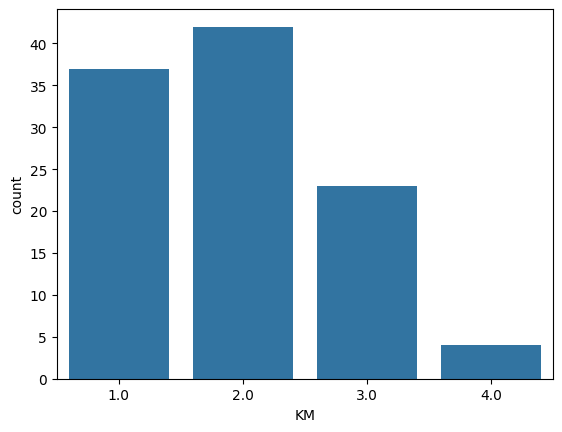

In [ ]:
sns.countplot(x='KM', data=dfX_3)

In [ ]:
dfX_3['deskripsi'][76]

'Rumah Mewah Pondok Pekayon Indah Siap Huni di Kota Bekasi, lokasi strategi yang dekat dengan fasilitas umum, dan row jalan lebar'

In [ ]:
dfX_3['KM'] = dfX_3['KM'].fillna(dfX_3['KM'].mode()[0])

Berdasarkan hasil pengecekan, kami memutuskan untuk melakukan imputasi pada kolom KM dengan modus yaitu 2

In [ ]:
dfs4 = {
    "dfJ_3": dfJ_3,
    "dfX_3": dfX_3,
    "dfT_3": dfT_3,
    "dfB_3": dfB_3,
    "dfD_3": dfD_3
}

# Gabungkan persentase NaN lalu transpose agar melebar ke kanan
null_percent = pd.DataFrame({name: (df.isnull().sum() / len(df) * 100)
                             for name, df in dfs4.items()})
display(null_percent.round(2))   # dibulatkan 2 desimal

,dfJ_3,dfX_3,dfT_3,dfB_3,dfD_3
created_at,0.00,0.0,0.0,0.0,0.0
LT,0.00,0.0,0.0,0.0,0.0
LB,0.00,0.0,0.0,0.0,0.0
KT,0.00,0.0,0.0,0.0,0.0
KM,0.00,0.0,0.0,0.0,0.0
carport,0.00,0.0,0.0,0.0,0.0
lokasi,0.00,0.0,0.0,0.0,0.0
sertifikat,0.00,0.0,0.0,0.0,0.0
listrik,0.00,0.0,0.0,0.0,0.0
harga,0.00,0.0,0.0,0.0,0.0


Dapat dilihat, hasil pengecekan missing value tersisa missing value pada kolom deskripsi di data Jakarta. Kolom deskripsi tetap dipertahankan meskipun memiliki sekitar 7,44% data yang hilang karena berupa teks narasi yang sulit diimputasi secara akurat dan mengandung informasi penting sehingga tidak memungkinkan untuk dihapus.


# **Menangani Noise**

In [ ]:
dfJ_3.head()

,created_at,LT,LB,KT,KM,carport,lokasi,sertifikat,listrik,harga,URL,deskripsi
0,06-12-2021,202.0,198.0,8.0,3.0,1.0,Jakarta Pusat,SHM,2200.0,4.500000e+09,https://www.rumah.com/listing-properti/dijual-...,Dekat Cikini Salemba Taman Isamail Marzuki Kam...
1,02-12-2021,30.0,55.0,2.0,1.0,1.0,Jakarta Pusat,SHM,2200.0,1.100000e+09,https://www.rumah.com/listing-properti/dijual-...,"Mengusung konsep minimalis, dan didukung denga..."
2,06-12-2021,19.0,35.0,2.0,1.0,1.0,Jakarta Pusat,SHM,2200.0,3.950000e+08,https://www.rumah.com/listing-properti/dijual-...,"Dekat dengan Mall Atrium Senen, dekat dengan a..."
3,06-12-2021,33.0,42.0,2.0,2.0,1.0,Jakarta Pusat,SHM,2200.0,8.350000e+08,https://www.rumah.com/listing-properti/dijual-...,"Berlokasi sangat strategis, sangat dekat ke Tu..."
4,06-12-2021,30.0,55.0,2.0,2.0,1.0,Jakarta Pusat,SHM,2200.0,1.100000e+09,https://www.rumah.com/listing-properti/dijual-...,"Bisa request ubah tata ruang, beli 2 unit mend..."


## Menangani Noise pada Kolom harga didataset Tangerang dan Depok


In [ ]:
dfT_3['harga'].value_counts()

,count
harga,
600.0,7
2300.0,6
1950.0,4
4700.0,4
1250.0,3
...,...
2150.0,1
1900.0,1
711.0,1


In [ ]:
dfT_3['harga'] = dfT_3['harga']*1000000

In [ ]:
dfT_3['harga'].value_counts()

,count
harga,
6.000000e+08,7
2.300000e+09,6
1.950000e+09,4
4.700000e+09,4
1.250000e+09,3
...,...
2.150000e+09,1
1.900000e+09,1
7.110000e+08,1


In [ ]:
dfD_3['harga'].value_counts()

,count
harga,
1700.0,6
250.0,5
498.0,5
260.0,4
350.0,3
...,...
320.0,1
750.0,1
195.0,1


In [ ]:
dfD_3['harga'] = dfD_3['harga']*1000000

In [ ]:
dfD_3['harga'].value_counts()

,count
harga,
1.700000e+09,6
2.500000e+08,5
4.980000e+08,5
2.600000e+08,4
3.500000e+08,3
...,...
3.200000e+08,1
7.500000e+08,1
1.950000e+08,1


Berdasarkan petunjuk yang didapatkan sebagai entri tidak normal sebelumnya dan hasil pemeriksaan keragaman data pada variabel Harga, dapat disimpulkan bahwa dataset dfD untuk Depok dan dfT untuk Tangerang memiliki satuan nilai yang berbeda di variabel Harga. Untuk melanjutkan proses selanjutnya, kami meratakan satuan entri pada variabel harga dengan mengalikan 1000000 dengan entri-entri di variabel Harga di dfD dan dfT .

## Mengangani Noise Pada Kolom Lokasi (Membuat Kolom Baru Kota untuk Clustering)



In [ ]:
dfJ_3['lokasi'].value_counts()

,count
lokasi,
Jakarta Barat,25
Jakarta Utara,25
Jakarta Selatan,24
Jakarta Timur,24
Jakarta Pusat,23


In [ ]:
dfB_3['lokasi'].value_counts()

,count
lokasi,
Gunung Putri,26
Babakan Madang,25
Parung,20
Bogor Barat,16
Bojonggede,12
Cibinong,12
Cileungsi,11
Bogor Utara,11
Jonggol,7


In [ ]:
dfT_3['lokasi'].value_counts()

,count
lokasi,
"BSD, TANGERANG",27
"BSD CITY, TANGERANG",21
"CISAUK, TANGERANG",8
"GADING SERPONG, TANGERANG",8
"BSD THE ICON, TANGERANG",6
"CIKUPA CITRA JAYA, TANGERANG",3
"CILEDUG, TANGERANG",3
"LIPPO KARAWACI, TANGERANG",3
"PONDOK CABE, TANGERANG",3


In [ ]:
mapping_tangerang = {
    # Kota Tangerang
    "CILEDUG, TANGERANG": "KOTA TANGERANG",
    "CIPONDOH, TANGERANG": "KOTA TANGERANG",
    "PINANG, TANGERANG": "KOTA TANGERANG",
    "BENDA, TANGERANG": "KOTA TANGERANG",
    "GRAHA RAYA, TANGERANG": "KOTA TANGERANG",
    "BANJAR WIJAYA, TANGERANG": "KOTA TANGERANG",
    "Poris, Tangerang": "KOTA TANGERANG",

    # Kabupaten Tangerang
    "CISAUK, TANGERANG": "KABUPATEN TANGERANG",
    "CIKUPA CITRA JAYA, TANGERANG": "KABUPATEN TANGERANG",
    "PASAR KEMIS, TANGERANG": "KABUPATEN TANGERANG",
    "MAUK, TANGERANG": "KABUPATEN TANGERANG",
    "SEPATAN, TANGERANG": "KABUPATEN TANGERANG",
    "LEGOK, TANGERANG": "KABUPATEN TANGERANG",
    "RAWAKALONG, TANGERANG": "KABUPATEN TANGERANG",
    "CITRA MAJA RAYA, TANGERANG": "KABUPATEN TANGERANG",
    "PAGEDANGAN, TANGERANG": "KABUPATEN TANGERANG",
    "Pagedangan, Tangerang": "KABUPATEN TANGERANG",

    # Kota Tangerang Selatan
    "BSD, TANGERANG": "KOTA TANGERANG SELATAN",
    "BSD CITY, TANGERANG": "KOTA TANGERANG SELATAN",
    "BSD THE ICON, TANGERANG": "KOTA TANGERANG SELATAN",
    "BSD FORESTA, TANGERANG": "KOTA TANGERANG SELATAN",
    "BSD PUSPITA LOKA, TANGERANG": "KOTA TANGERANG SELATAN",
    "BSD NUSALOKA, TANGERANG": "KOTA TANGERANG SELATAN",
    "BSD DELATINOS, TANGERANG": "KOTA TANGERANG SELATAN",
    "BSD EMINENT, TANGERANG": "KOTA TANGERANG SELATAN",
    "BSD THE GREEN, TANGERANG": "KOTA TANGERANG SELATAN",
    "BSD DUTA BINTARO, TANGERANG": "KOTA TANGERANG SELATAN",
    "BSD DE PARK, TANGERANG": "KOTA TANGERANG SELATAN",
    "BSD PROVANCE PARKLAND, TANGERANG": "KOTA TANGERANG SELATAN",
    "BSD GREEN WICH, TANGERANG": "KOTA TANGERANG SELATAN",
    "BSD GRIYA LOKA, TANGERANG": "KOTA TANGERANG SELATAN",
    "BSD BUKIT GOLF, TANGERANG": "KOTA TANGERANG SELATAN",
    "BSD Griya Loka, Tangerang": "KOTA TANGERANG SELATAN",
    "GADING SERPONG, TANGERANG": "KOTA TANGERANG SELATAN",
    "LIPPO KARAWACI, TANGERANG": "KOTA TANGERANG SELATAN",
    "KARAWACI, TANGERANG": "KOTA TANGERANG SELATAN",
    "ALAM SUTERA, TANGERANG": "KOTA TANGERANG SELATAN",
    "PONDOK CABE, TANGERANG": "KOTA TANGERANG SELATAN",
    "PONDOK JAGUNG, TANGERANG": "KOTA TANGERANG SELATAN",
    "SERPONG, TANGERANG SELATAN": "KOTA TANGERANG SELATAN",
    "Ciater, Tangerang": "KOTA TANGERANG SELATAN"
}

dfT_3['kota'] = dfT_3['lokasi'].map(mapping_tangerang)


In [ ]:
dfT_3['kota'].value_counts()

,count
kota,
KOTA TANGERANG SELATAN,93
KABUPATEN TANGERANG,19
KOTA TANGERANG,12


In [ ]:
mapping_bogor = {
    # Kota Bogor
    "Bogor Barat": "Kota Bogor",
    "Bogor Utara": "Kota Bogor",
    "Bogor Selatan": "Kota Bogor",
    "Tanah Sareal": "Kota Bogor",
    "Bogor Timur": "Kota Bogor",
    "Bogor Tengah": "Kota Bogor",

    # Kab. Bogor Utara
    "Cibinong": "Kabupaten Bogor - Utara",
    "Sukaraja": "Kabupaten Bogor - Utara",

    # Kab. Bogor Timur
    "Gunung Putri": "Kabupaten Bogor - Timur",
    "Cileungsi": "Kabupaten Bogor - Timur",
    "Jonggol": "Kabupaten Bogor - Timur",

    # Kab. Bogor Barat
    "Parung": "Kabupaten Bogor - Barat",
    "Gunungsindur": "Kabupaten Bogor - Barat",
    "Tajurhalang": "Kabupaten Bogor - Barat",
    "Ciseeng": "Kabupaten Bogor - Barat",
    "Rumpin": "Kabupaten Bogor - Barat",
    "Parung Panjang": "Kabupaten Bogor - Barat",
    "Tenjo": "Kabupaten Bogor - Barat",
    "Kemang": "Kabupaten Bogor - Barat",
    "Ranca Bungur": "Kabupaten Bogor - Barat",
    "Bojonggede": "Kabupaten Bogor - Barat",

    # Kab. Bogor Selatan
    "Babakan Madang": "Kabupaten Bogor - Selatan",
    "Ciomas": "Kabupaten Bogor - Selatan",
    "Ciampea": "Kabupaten Bogor - Selatan",
    "Megamendung": "Kabupaten Bogor - Selatan",
    "Cipanas": "Kabupaten Bogor - Selatan",
    "Dramaga": "Kabupaten Bogor - Selatan"
}

dfB_3['kota'] = dfB_3['lokasi'].map(mapping_bogor)



In [ ]:
dfB_3['kota'].value_counts()

,count
kota,
Kabupaten Bogor - Barat,52
Kota Bogor,45
Kabupaten Bogor - Timur,44
Kabupaten Bogor - Selatan,37
Kabupaten Bogor - Utara,15


In [ ]:
dfD_3['lokasi'].value_counts()

,count
lokasi,
Sawangan,30
Cimanggis,25
Cinere,12
Tapos,12
Sukmajaya,9
Cipayung,9
Pancoran Mas,9
Beji,5
Cilodong,3


In [ ]:
mapping_depok = {
    # Depok Utara
    "Cimanggis": "Depok Utara",
    "Tapos": "Depok Utara",
    "Cilodong": "Depok Utara",

    # Depok Tengah
    "Beji": "Depok Tengah",
    "Sukmajaya": "Depok Tengah",
    "Cipayung": "Depok Tengah",
    "Pancoran Mas": "Depok Tengah",

    # Depok Selatan
    "Sawangan": "Depok Selatan",
    "Cinere": "Depok Selatan",
    "Limo": "Depok Selatan",
    "Bojong Sari": "Depok Selatan"
}

dfD_3['kota'] = dfD_3['lokasi'].map(mapping_depok)


In [ ]:
dfD_3['kota'].value_counts()

,count
kota,
Depok Selatan,46
Depok Utara,40
Depok Tengah,32


In [ ]:
dfX_3['lokasi'].value_counts()

,count
lokasi,
Kota Bekasi,73
Kabupaten Bekasi,34


Untuk tujuan membandingkan per masing-masing Kota, kami memutuskan untuk menambahkan satu kolom pada data yang memiliki keterangan lokasi berupa Kecamatan (ada pada data Tangerang, data Bogor, dan data Depok). Untuk menghindari kemunculan NaN pada saat di-Concat kami menambahkan satu kolom dengan isi yang sama dengan lokasi pada data Jakarta dan Bekasi.

## Menambahkan kolom kota pada data Bekasi dan Jakarta (Agar Tidak NaN saat diconcat)

In [ ]:
dfJ_3['kota'] = dfJ_3['lokasi']
dfX_3['kota'] = dfX_3['lokasi']

In [ ]:
dfX_3

,created_at,LT,LB,KT,KM,carport,lokasi,sertifikat,listrik,harga,URL,deskripsi,kota
0,08-12-2021,71.0,43.0,2.0,1.0,1.0,Kabupaten Bekasi,SHM,1300.0,5.500000e+08,Rumah murah di metland cibitung bekasi - Dijua...,"Selangkah ke stasiun krl telaga murni, Dekat d...",Kabupaten Bekasi
1,08-12-2021,59.0,60.0,2.0,1.0,1.0,Kabupaten Bekasi,SHM,1300.0,4.400000e+08,Rumah dijual di Griya gandasari cibitung - Dij...,"Rumah sangat nyaman,dan terbukti bebas banjir,...",Kabupaten Bekasi
2,08-12-2021,124.0,95.0,2.0,1.0,1.0,Kabupaten Bekasi,SHM,2200.0,6.990000e+08,Jual cepat rumah huuk di metland cibitung beka...,"Bebas banjir, Carport dan tanah luas ada taman...",Kabupaten Bekasi
3,08-12-2021,144.0,100.0,2.0,1.0,1.0,Kabupaten Bekasi,SHM,2200.0,1.350000e+09,https://www.realoka.com/216243-rumah-rapi-siap...,(Harapan Indah) Cluster Aralia Kota Harapan In...,Kabupaten Bekasi
4,08-12-2021,108.0,100.0,3.0,2.0,1.0,Kabupaten Bekasi,SHM,2200.0,1.400000e+09,https://www.realoka.com/207964-jual-rumah-bagu...,(Harapan Indah) Cluster Harmoni Perumahan Kota...,Kabupaten Bekasi
...,...,...,...,...,...,...,...,...,...,...,...,...,...
102,01-12-2021,180.0,220.0,5.0,3.0,1.0,Kota Bekasi,SHM,2200.0,1.600000e+09,https://www.rumah123.com/properti/bekasi/hos92...,Akses pintu tol Bekasibarat; Dekat Mall Summar...,Kota Bekasi
103,01-12-2021,140.0,250.0,3.0,2.0,1.0,Kabupaten Bekasi,SHM,2200.0,8.500000e+08,https://www.rumah123.com/properti/bekasi/hos92...,"DIJUAL RUMAH, Taman Kebalen bekasi cluster, Ju...",Kabupaten Bekasi
104,01-12-2021,60.0,55.0,2.0,1.0,1.0,Kabupaten Bekasi,SHM,1300.0,2.500000e+08,https://www.rumah123.com/properti/bekasi/hos92...,"Di jual Rumah Lelang Bank Pondok Ungu Permai, ...",Kabupaten Bekasi
105,01-12-2021,36.0,60.0,2.0,1.0,1.0,Kabupaten Bekasi,SHM,1300.0,3.000000e+08,https://www.rumah123.com/properti/bekasi/hos92...,"Lokasi Super Strategis, Selangkah menuju Kota ...",Kabupaten Bekasi


Kolom **kota** ditambahkan pada data Bekasi dan Jakarta dengan menyalin nilai dari kolom **lokasi** agar kedua dataset memiliki struktur yang sama, sehingga saat digabung tidak muncul nilai **NaN** dan informasi kota tetap tersedia untuk analisis selanjutnya.

# **Mengubah Tipe Data**

In [ ]:
dfJ_3['created_at'].value_counts()

,count
created_at,
06-12-2021,41
07-12-2021,14
05-12-2021,12
02-12-2021,8
22-11-2021,7
06-11-2021,7
29-11-2021,6
03-12-2021,4
04-12-2021,4


In [ ]:
dfX_3['created_at'].value_counts()

,count
created_at,
06-12-2021,30
04-12-2021,19
03-12-2021,15
05-12-2021,15
01-12-2021,11
02-12-2021,8
08-12-2021,7
07-12-2021,2


In [ ]:
dfB_3['created_at'].value_counts()

,count
created_at,
06-12-2021,52
07-12-2021,40
03-12-2021,21
02-12-2021,20
01-12-2021,20
04-12-2021,20
05-12-2021,20


In [ ]:
dfD_3['created_at'].value_counts()

,count
created_at,
5-12-2021,74
6-12-2021,22
4-12-2021,22


In [ ]:
dfT_3['created_at'].value_counts()

,count
created_at,
12-06-2021,102
12-08-2021,12
12-07-2021,10


In [ ]:
# Pastikan string
dfT_3['created_at'] = dfT_3['created_at'].astype(str)

In [ ]:
# Parsing dari format salah (bulan-tanggal-tahun)
dfT_3['created_at'] = pd.to_datetime(dfT_3['created_at'], format='%m-%d-%Y', errors='coerce')

In [ ]:
# Konversi ulang jadi format benar (tanggal-bulan-tahun)
dfT_3['created_at'] = dfT_3['created_at'].dt.strftime('%d-%m-%Y')

In [ ]:
# Cek hasil unik
print(dfT_3['created_at'].unique()[:20])

['06-12-2021' '07-12-2021' '08-12-2021']


In [ ]:
dfJ_3['created_at'].value_counts()

,count
created_at,
06-12-2021,41
07-12-2021,14
05-12-2021,12
02-12-2021,8
22-11-2021,7
06-11-2021,7
29-11-2021,6
03-12-2021,4
04-12-2021,4


In [ ]:
dfX_3['created_at'].value_counts()

,count
created_at,
06-12-2021,30
04-12-2021,19
03-12-2021,15
05-12-2021,15
01-12-2021,11
02-12-2021,8
08-12-2021,7
07-12-2021,2


In [ ]:
dfB_3['created_at'].value_counts()

,count
created_at,
06-12-2021,52
07-12-2021,40
03-12-2021,21
02-12-2021,20
01-12-2021,20
04-12-2021,20
05-12-2021,20


In [ ]:
dfD_3['created_at'].value_counts()

,count
created_at,
5-12-2021,74
6-12-2021,22
4-12-2021,22


In [ ]:
dfT_3['created_at'].value_counts()

,count
created_at,
06-12-2021,102
08-12-2021,12
07-12-2021,10


In [ ]:
# Ubah tipe data Jakarta
dfJ_3['created_at'] = pd.to_datetime(dfJ_3['created_at'], format='%d-%m-%Y')
dfJ_3['lokasi'] = dfJ_3['lokasi'].astype('category')
dfJ_3['sertifikat'] = dfJ_3['sertifikat'].astype('category')
dfJ_3['LT'] = dfJ_3['LT'].astype('int')
dfJ_3['LB'] = dfJ_3['LB'].astype('int')
dfJ_3['KM'] = dfJ_3['KM'].astype('category')
dfJ_3['KT'] = dfJ_3['KT'].astype('category')
dfJ_3['carport'] = dfJ_3['carport'].astype('int')
dfJ_3['listrik'] = dfJ_3['listrik'].astype('int')
dfJ_3['harga'] = dfJ_3['harga'].astype('int')

# Ubah tipe data Bogor
dfB_3['created_at'] = pd.to_datetime(dfB_3['created_at'], format='%d-%m-%Y')
dfB_3['lokasi'] = dfB_3['lokasi'].astype('category')
dfB_3['sertifikat'] = dfB_3['sertifikat'].astype('category')
dfB_3['LT'] = dfB_3['LT'].astype('int')
dfB_3['LB'] = dfB_3['LB'].astype('int')
dfB_3['KM'] = dfB_3['KM'].astype('category')
dfB_3['KT'] = dfB_3['KT'].astype('category')
dfB_3['carport'] = dfB_3['carport'].astype('int')
dfB_3['listrik'] = dfB_3['listrik'].astype('int')
dfB_3['harga'] = dfB_3['harga'].astype('int')

# Ubah tipe data Depok
dfD_3['created_at'] = pd.to_datetime(dfD_3['created_at'], format='%d-%m-%Y')
dfD_3['lokasi'] = dfD_3['lokasi'].astype('category')
dfD_3['sertifikat'] = dfD_3['sertifikat'].astype('category')
dfD_3['LT'] = dfD_3['LT'].astype('int')
dfD_3['LB'] = dfD_3['LB'].astype('int')
dfD_3['KM'] = dfD_3['KM'].astype('category')
dfD_3['KT'] = dfD_3['KT'].astype('category')
dfD_3['carport'] = dfD_3['carport'].astype('int')
dfD_3['listrik'] = dfD_3['listrik'].astype('int')
dfD_3['harga'] = dfD_3['harga'].astype('int')

# Ubah tipe data Tangerang
dfT_3['created_at'] = pd.to_datetime(dfT_3['created_at'], format='%d-%m-%Y')
dfT_3['lokasi'] = dfT_3['lokasi'].astype('category')
dfT_3['sertifikat'] = dfT_3['sertifikat'].astype('category')
dfT_3['LT'] = dfT_3['LT'].astype('int')
dfT_3['LB'] = dfT_3['LB'].astype('int')
dfT_3['KM'] = dfT_3['KM'].astype('category')
dfT_3['KT'] = dfT_3['KT'].astype('category')
dfT_3['carport'] = dfT_3['carport'].astype('int')
dfT_3['listrik'] = dfT_3['listrik'].astype('int')
dfT_3['harga'] = dfT_3['harga'].astype('int')

# Ubah tipe data Bekasi
dfX_3['created_at'] = pd.to_datetime(dfX_3['created_at'], format='%d-%m-%Y')
dfX_3['lokasi'] = dfX_3['lokasi'].astype('category')
dfX_3['sertifikat'] = dfX_3['sertifikat'].astype('category')
dfX_3['LT'] = dfX_3['LT'].astype('int')
dfX_3['LB'] = dfX_3['LB'].astype('int')
dfX_3['KM'] = dfX_3['KM'].astype('category')
dfX_3['KT'] = dfX_3['KT'].astype('category')
dfX_3['carport'] = dfX_3['carport'].astype('int')
dfX_3['listrik'] = dfX_3['listrik'].astype('int')
dfX_3['harga'] = dfX_3['harga'].astype('int')

In [ ]:
dfJ_3.info()
dfB_3.info()
dfD_3.info()
dfT_3.info()
dfX_3.info()

<class 'pandas.core.frame.DataFrame'>
Index: 121 entries, 0 to 120
Data columns (total 13 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   created_at  121 non-null    datetime64[ns]
 1   LT          121 non-null    int64         
 2   LB          121 non-null    int64         
 3   KT          121 non-null    category      
 4   KM          121 non-null    category      
 5   carport     121 non-null    int64         
 6   lokasi      121 non-null    category      
 7   sertifikat  121 non-null    category      
 8   listrik     121 non-null    int64         
 9   harga       121 non-null    int64         
 10  URL         121 non-null    object        
 11  deskripsi   112 non-null    object        
 12  kota        121 non-null    object        
dtypes: category(4), datetime64[ns](1), int64(5), object(3)
memory usage: 15.3+ KB
<class 'pandas.core.frame.DataFrame'>
Index: 193 entries, 0 to 192
Data columns (total 13 columns

# **Mengecek Distribusi Tiap Data Numerik**

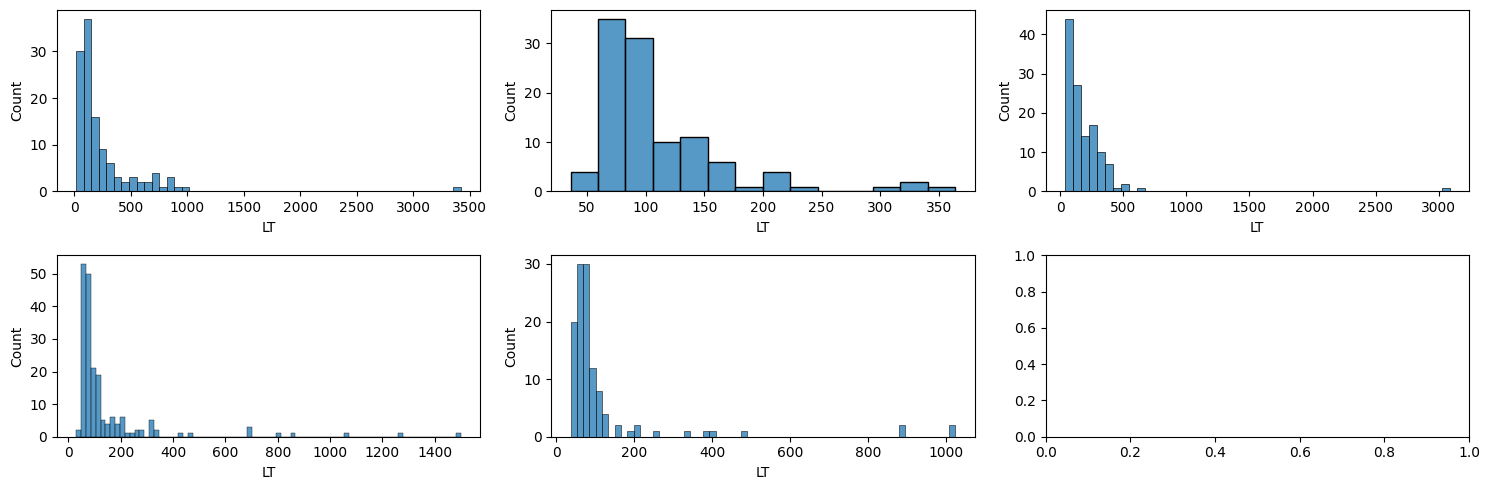

In [ ]:
# Mengecek distribusi kolom LT
fig, axes = plt.subplots(2, 3, figsize=(15, 5), sharey=False)
sns.histplot(dfJ_3['LT'], ax=axes[0, 0])
sns.histplot(dfX_3['LT'], ax=axes[0, 1])
sns.histplot(dfT_3['LT'], ax=axes[0, 2])
sns.histplot(dfB_3['LT'], ax=axes[1, 0])
sns.histplot(dfD_3['LT'], ax=axes[1, 1])
plt.tight_layout()
plt.show()

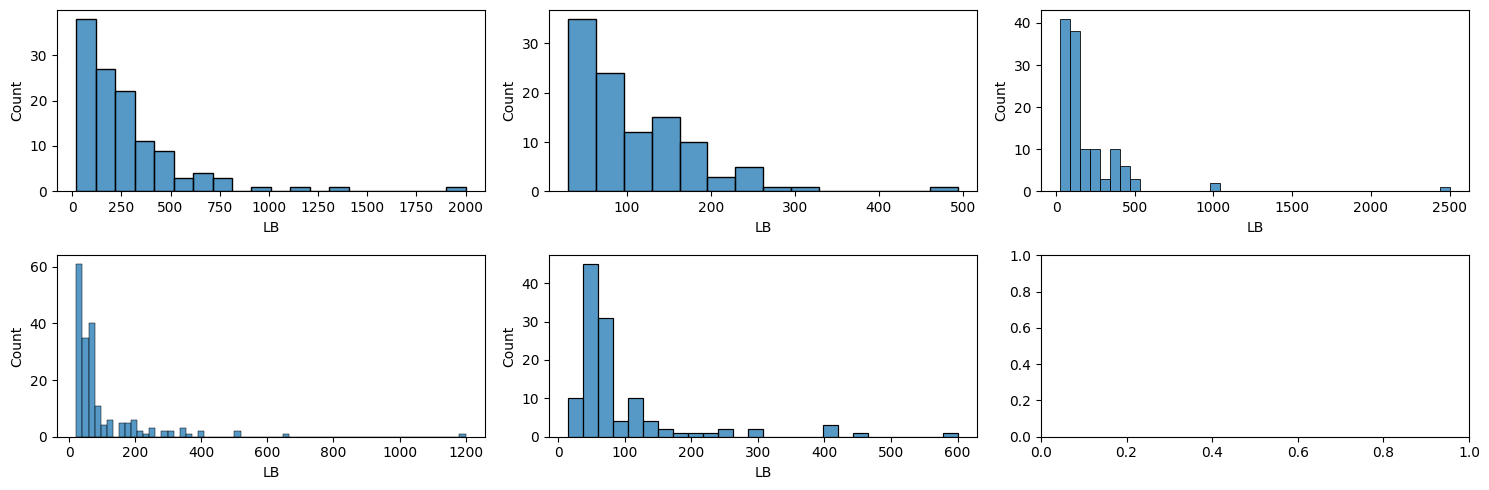

In [ ]:
# Mengecek distribusi kolom LB
fig, axes = plt.subplots(2, 3, figsize=(15, 5), sharey=False)
sns.histplot(dfJ_3['LB'], ax=axes[0, 0])
sns.histplot(dfX_3['LB'], ax=axes[0, 1])
sns.histplot(dfT_3['LB'], ax=axes[0, 2])
sns.histplot(dfB_3['LB'], ax=axes[1, 0])
sns.histplot(dfD_3['LB'], ax=axes[1, 1])
plt.tight_layout()
plt.show()

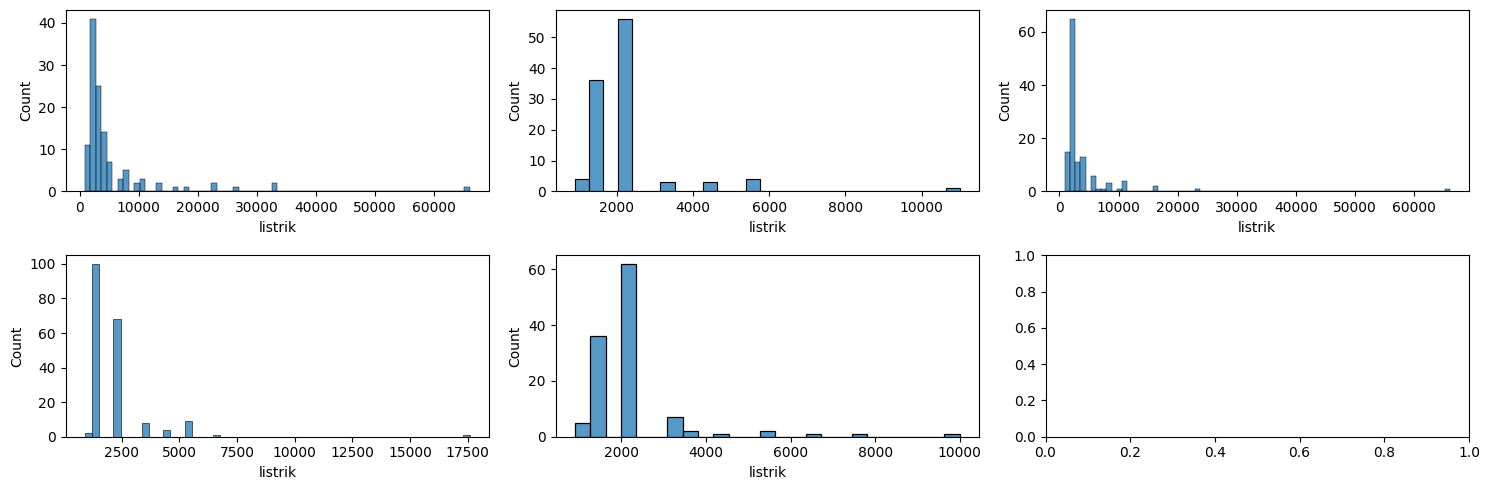

In [ ]:
# Mengecek distribusi kolom listrik
fig, axes = plt.subplots(2, 3, figsize=(15, 5), sharey=False)
sns.histplot(dfJ_3['listrik'], ax=axes[0, 0])
sns.histplot(dfX_3['listrik'], ax=axes[0, 1])
sns.histplot(dfT_3['listrik'], ax=axes[0, 2])
sns.histplot(dfB_3['listrik'], ax=axes[1, 0])
sns.histplot(dfD_3['listrik'], ax=axes[1, 1])
plt.tight_layout()
plt.show()

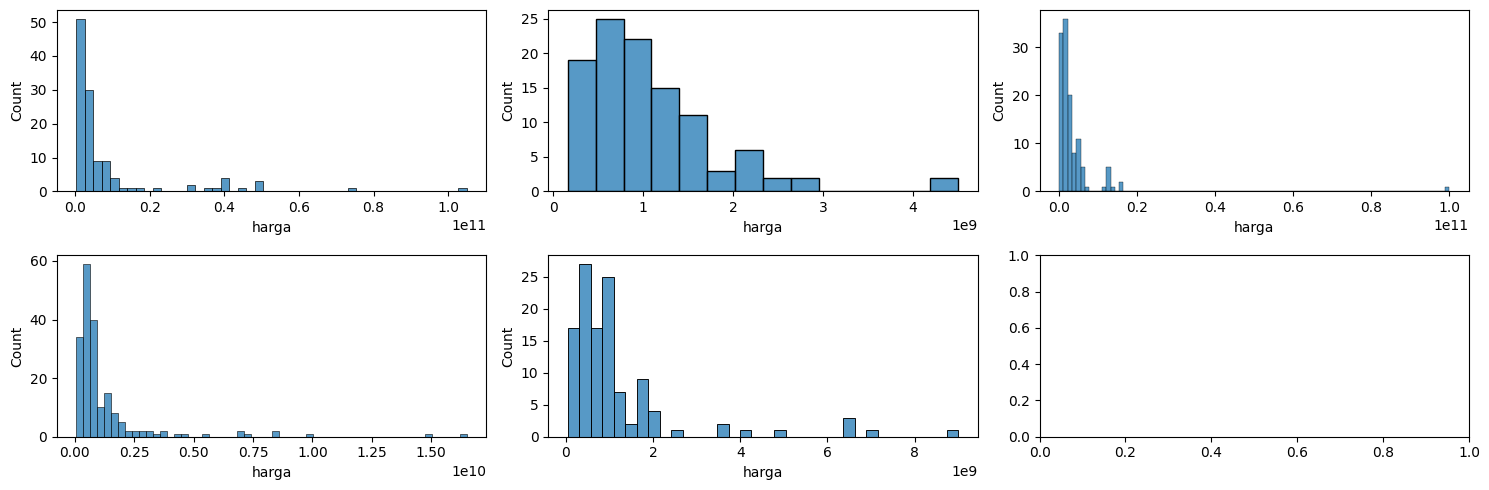

In [ ]:
# Mengecek distribusi kolom harga
fig, axes = plt.subplots(2, 3, figsize=(15, 5), sharey=False)
sns.histplot(dfJ_3['harga'], ax=axes[0, 0])
sns.histplot(dfX_3['harga'], ax=axes[0, 1])
sns.histplot(dfT_3['harga'], ax=axes[0, 2])
sns.histplot(dfB_3['harga'], ax=axes[1, 0])
sns.histplot(dfD_3['harga'], ax=axes[1, 1])
plt.tight_layout()
plt.show()

Melakukan pemeriksaan visualisasi untuk variabel dengan tipe  data kontinu, tujuannya untuk melihat distribusi masing-masing variabel.

# **Menangani Outlier**

## Outlier Kolom Harga

### Iterasi Pertama

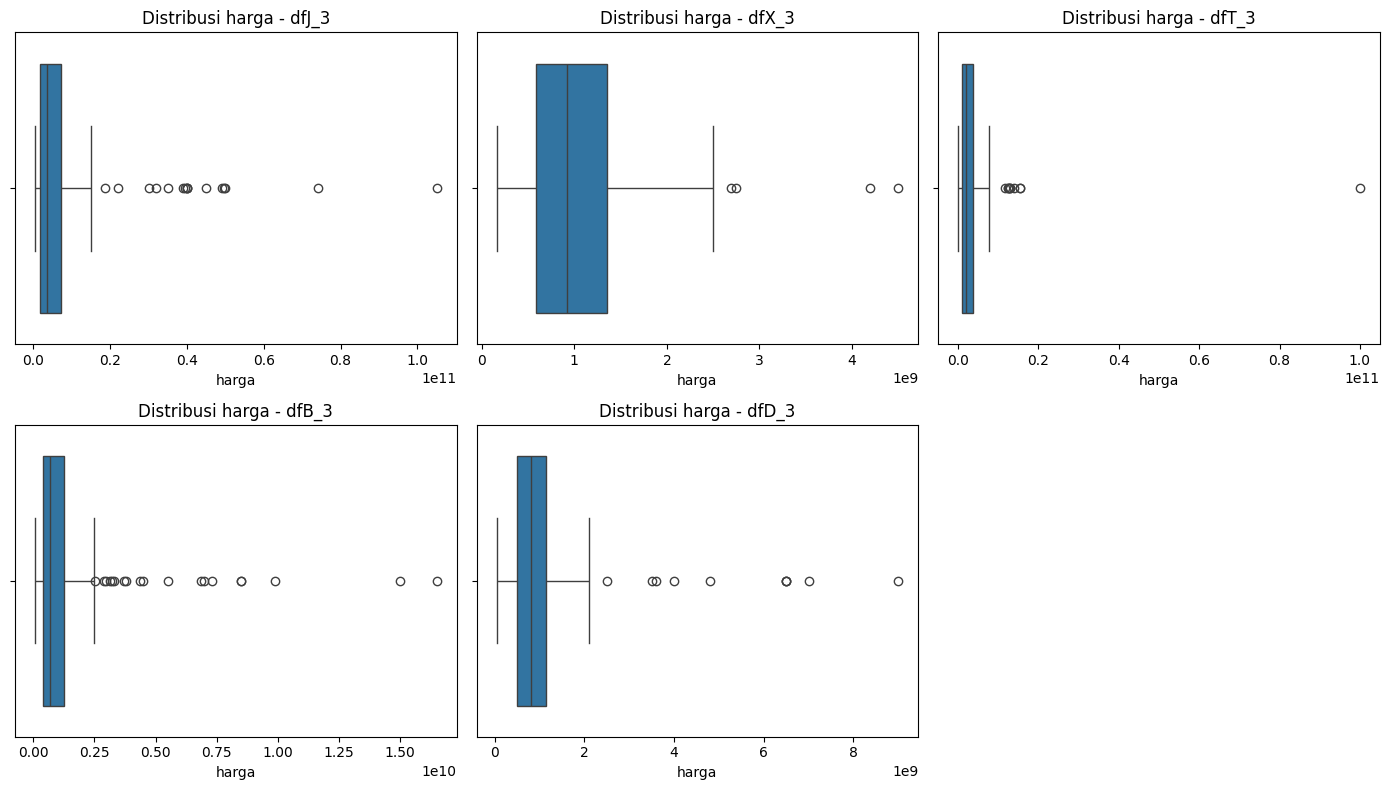

In [ ]:
# Bikin figure
plt.figure(figsize=(14, 8))

# Plot 1
plt.subplot(2, 3, 1)
sns.boxplot(x="harga", data=dfJ_3)
plt.title("Distribusi harga - dfJ_3")

# Plot 2
plt.subplot(2, 3, 2)
sns.boxplot(x="harga", data=dfX_3)
plt.title("Distribusi harga - dfX_3")

# Plot 3
plt.subplot(2, 3, 3)
sns.boxplot(x="harga", data=dfT_3)
plt.title("Distribusi harga - dfT_3")

# Plot 4
plt.subplot(2, 3, 4)
sns.boxplot(x="harga", data=dfB_3)
plt.title("Distribusi harga - dfB_3")

# Plot 5
plt.subplot(2, 3, 5)
sns.boxplot(x="harga", data=dfD_3)
plt.title("Distribusi harga - dfD_3")

plt.tight_layout()
plt.show()

Membuat visualisasi boxplot harga dari beberapa subset data secara berdampingan, supaya distribusi harga antar kota/area bisa dibandingkan dengan mudah.

In [ ]:
# Mengecek banyaknya outlier pada dataset Jakarta
Q1J_harga = dfJ_3['harga'].quantile(0.25)
Q2J_harga = dfJ_3['harga'].quantile(0.50)
Q3J_harga = dfJ_3['harga'].quantile(0.75)
IQRJ_harga = Q3J_harga - Q1J_harga
outlierJ_harga = (dfJ_3['harga'] <= Q1J_harga - 1.5*IQRJ_harga) | (dfJ_3['harga'] >= Q3J_harga + 1.5*IQRJ_harga)
print("Banyaknya outlier = ",sum(outlierJ_harga))

Banyaknya outlier =  16


In [ ]:
# Data outlier
dfJ_3_outlier_harga = dfJ_3[outlierJ_harga]

# Data non-outlier
dfJ_3 = dfJ_3[~outlierJ_harga]

# Menampilkan jumlah baris masing-masing
print("Jumlah data outlier:", len(dfJ_3_outlier_harga))
print("Jumlah data non-outlier:", len(dfJ_3))

Jumlah data outlier: 16
Jumlah data non-outlier: 105


Kami memisahkan data Jakarta (dfJ_3) berdasarkan apakah nilai harga termasuk outlier atau tidak, lalu menghitung jumlah masing-masing kelompok.

In [ ]:
# Mengecek banyaknya outlier pada dataset Bekasi
Q1X_harga = dfX_3['harga'].quantile(0.25)
Q2X_harga = dfX_3['harga'].quantile(0.50)
Q3X_harga = dfX_3['harga'].quantile(0.75)
IQRX_harga = Q3X_harga - Q1X_harga
outlierX_harga = (dfX_3['harga'] <= Q1X_harga - 1.5*IQRX_harga) | (dfX_3['harga'] >= Q3X_harga + 1.5*IQRX_harga)
print("Banyaknya outlier = ",sum(outlierX_harga))

Banyaknya outlier =  4


In [ ]:
# Data outlier
dfX_3_outlier_harga = dfX_3[outlierX_harga]

# Data non-outlier
dfX_3 = dfX_3[~outlierX_harga]

# Menampilkan jumlah baris masing-masing
print("Jumlah data outlier:", len(dfX_3_outlier_harga))
print("Jumlah data non-outlier:", len(dfX_3))

Jumlah data outlier: 4
Jumlah data non-outlier: 103


Kami memisahkan data Bekasi (dfX_3) berdasarkan apakah nilai harga termasuk outlier atau tidak, lalu menghitung jumlah masing-masing kelompok.

In [ ]:
# Mengecek banyaknya outlier pada dataset Tangerang
Q1T_harga = dfT_3['harga'].quantile(0.25)
Q2T_harga = dfT_3['harga'].quantile(0.50)
Q3T_harga = dfT_3['harga'].quantile(0.75)
IQRT_harga = Q3T_harga - Q1T_harga

outlierT_harga = (dfT_3['harga'] <= Q1T_harga - 1.5*IQRT_harga) | (dfT_3['harga'] >= Q3T_harga + 1.5*IQRT_harga)
print("Banyaknya outlier =", sum(outlierT_harga))

Banyaknya outlier = 10


In [ ]:
# Data outlier
dfT_3_outlier_harga = dfT_3[outlierT_harga]

# Data non-outlier
dfT_3 = dfT_3[~outlierT_harga]

# Menampilkan jumlah baris masing-masing
print("Jumlah data outlier:", len(dfT_3_outlier_harga))
print("Jumlah data non-outlier:", len(dfT_3))

Jumlah data outlier: 10
Jumlah data non-outlier: 114


Kami memisahkan data Tangerang (dfT_3) berdasarkan apakah nilai harga termasuk outlier atau tidak, lalu menghitung jumlah masing-masing kelompok.

In [ ]:
# # Mengecek banyaknya outlier pada dataset Bogor
Q1B_harga = dfB_3['harga'].quantile(0.25)
Q2B_harga = dfB_3['harga'].quantile(0.50)
Q3B_harga = dfB_3['harga'].quantile(0.75)
IQRB_harga = Q3B_harga - Q1B_harga

outlierB_harga = (dfB_3['harga'] <= Q1B_harga - 1.5*IQRB_harga) | (dfB_3['harga'] >= Q3B_harga + 1.5*IQRB_harga)
print("Banyaknya outlier dfB_3 =", sum(outlierB_harga))

Banyaknya outlier dfB_3 = 19


In [ ]:
# Data outlier
dfB_3_outlier_harga = dfB_3[outlierB_harga]

# Data non-outlier
dfB_3 = dfB_3[~outlierB_harga]

# Menampilkan jumlah baris masing-masing
print("Jumlah data outlier dfB_3:", len(dfB_3_outlier_harga))
print("Jumlah data non-outlier dfB_3:", len(dfB_3))

Jumlah data outlier dfB_3: 19
Jumlah data non-outlier dfB_3: 174


Kami memisahkan data Bogor (dfB_3) berdasarkan apakah nilai harga termasuk outlier atau tidak, lalu menghitung jumlah masing-masing kelompok.

In [ ]:
# Mengecek banyaknya outlier pada dataset Depok
Q1D_harga = dfD_3['harga'].quantile(0.25)
Q2D_harga = dfD_3['harga'].quantile(0.50)
Q3D_harga = dfD_3['harga'].quantile(0.75)
IQRD_harga = Q3D_harga - Q1D_harga

outlierD_harga = (dfD_3['harga'] <= Q1D_harga - 1.5*IQRD_harga) | (dfD_3['harga'] >= Q3D_harga + 1.5*IQRD_harga)
print("Banyaknya outlier dfD_3 =", sum(outlierD_harga))

Banyaknya outlier dfD_3 = 10


In [ ]:
# Data outlier
dfD_3_outlier_harga = dfD_3[outlierD_harga]

# Data non-outlier
dfD_3 = dfD_3[~outlierD_harga]

# Menampilkan jumlah baris masing-masing
print("Jumlah data outlier dfD_3:", len(dfD_3_outlier_harga))
print("Jumlah data non-outlier dfD_3:", len(dfD_3))

Jumlah data outlier dfD_3: 10
Jumlah data non-outlier dfD_3: 108


Kami memisahkan data Depok (dfD_3) berdasarkan apakah nilai harga termasuk outlier atau tidak, lalu menghitung jumlah masing-masing kelompok.

In [ ]:
# Mengumpulkan semua data outlier harga dari berbagai kota ke satu wadah (harga_outlier_all)
harga_outlier_all = pd.concat([
    dfJ_3_outlier_harga,
    dfX_3_outlier_harga,
    dfT_3_outlier_harga,
    dfB_3_outlier_harga,
    dfD_3_outlier_harga
], ignore_index=True)

In [ ]:
harga_outlier_all

,created_at,LT,LB,KT,KM,carport,lokasi,sertifikat,listrik,harga,URL,deskripsi,kota
0,2021-12-06,424,1000,4.0,5.0,1,Jakarta Pusat,SHM,33000,49500000000,https://www.rumah.com/listing-properti/dijual-...,"Rumah mewah berkonsep hotel bintang 5, interio...",Jakarta Pusat
1,2021-12-06,597,700,5.0,4.0,5,Jakarta Pusat,SHM,8000,40000000000,https://www.rumah.com/listing-properti/dijual-...,Lokasi strategis hanya 5 menit ke pusat kulin...,Jakarta Pusat
2,2021-12-05,652,405,5.0,4.0,4,Jakarta Pusat,SHM,6600,45000000000,https://www.rumah.com/listing-properti/dijual-...,Dapat dinego,Jakarta Pusat
3,2021-12-05,840,800,5.0,3.0,8,Jakarta Pusat,SHGB,6600,39990000000,https://www.rumah.com/listing-properti/dijual-...,"1 Arah, Trotoar Besar, pepohonan rindang asri ...",Jakarta Pusat
4,2021-12-07,700,2000,10.0,10.0,10,Jakarta Pusat,SHM,66000,105000000000,https://www.rumah.com/listing-properti/dijual-...,- 2 menit ke Grand Indonesia (500 meter)\n- 5 ...,Jakarta Pusat
5,2021-12-06,485,550,3.0,5.0,1,Jakarta Selatan,SHM + IMB,18000,22000000000,https://rumahdijual.com/tebet/10851049-rmh-mew...,- Ruang Musik\n- Kitchen set ( dapur kotor dan...,Jakarta Selatan
6,2021-12-06,612,485,5.0,4.0,2,Jakarta Selatan,SHM,13000,18500000000,https://rumahdijual.com/jakarta-selatan/112558...,- Lantai Bawah : Master Bed Room dengan kamar ...,Jakarta Selatan
7,2021-12-06,790,700,6.0,6.0,6,Jakarta Selatan,SHM,7700,32000000000,https://rumahdijual.com/jakarta-selatan/110122...,Ada kolam renang,Jakarta Selatan
8,2021-12-05,950,1400,6.0,4.0,1,Jakarta Selatan,SHM,23000,49000000000,https://rumahdijual.com/jakarta-selatan/955358...,"Lantai 1 :\n- 1 Living Room, Family Room, Dinn...",Jakarta Selatan
9,2021-12-07,738,500,5.0,3.0,2,Jakarta Selatan,SHM + IMB,13200,74000000000,https://rumahdijual.com/jakarta-pusat/6519312-...,- Unfurnished dan Air Jetpump\n- Berada dalam ...,Jakarta Selatan


<Axes: xlabel='harga'>

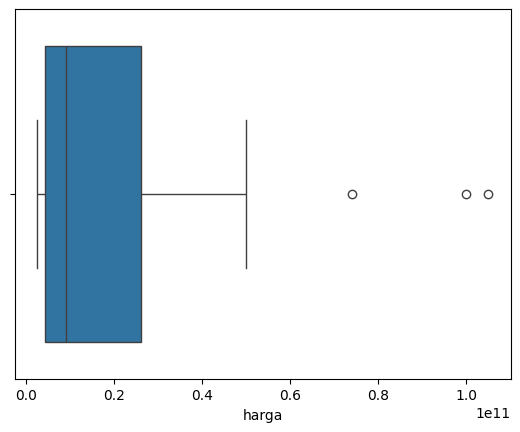

In [ ]:
# Memvisualisasikan distribusi dan ekstremitas harga outlier yang telah dikumpulkan dari semua kota.
sns.boxplot(x='harga', data=harga_outlier_all)

Kemudian outlier dari masing-masing data dikumpulkan menjadi satu data, dan dilakukan visualisasi untuk melihat ekstremitas Harga.

### Iterasi Kedua

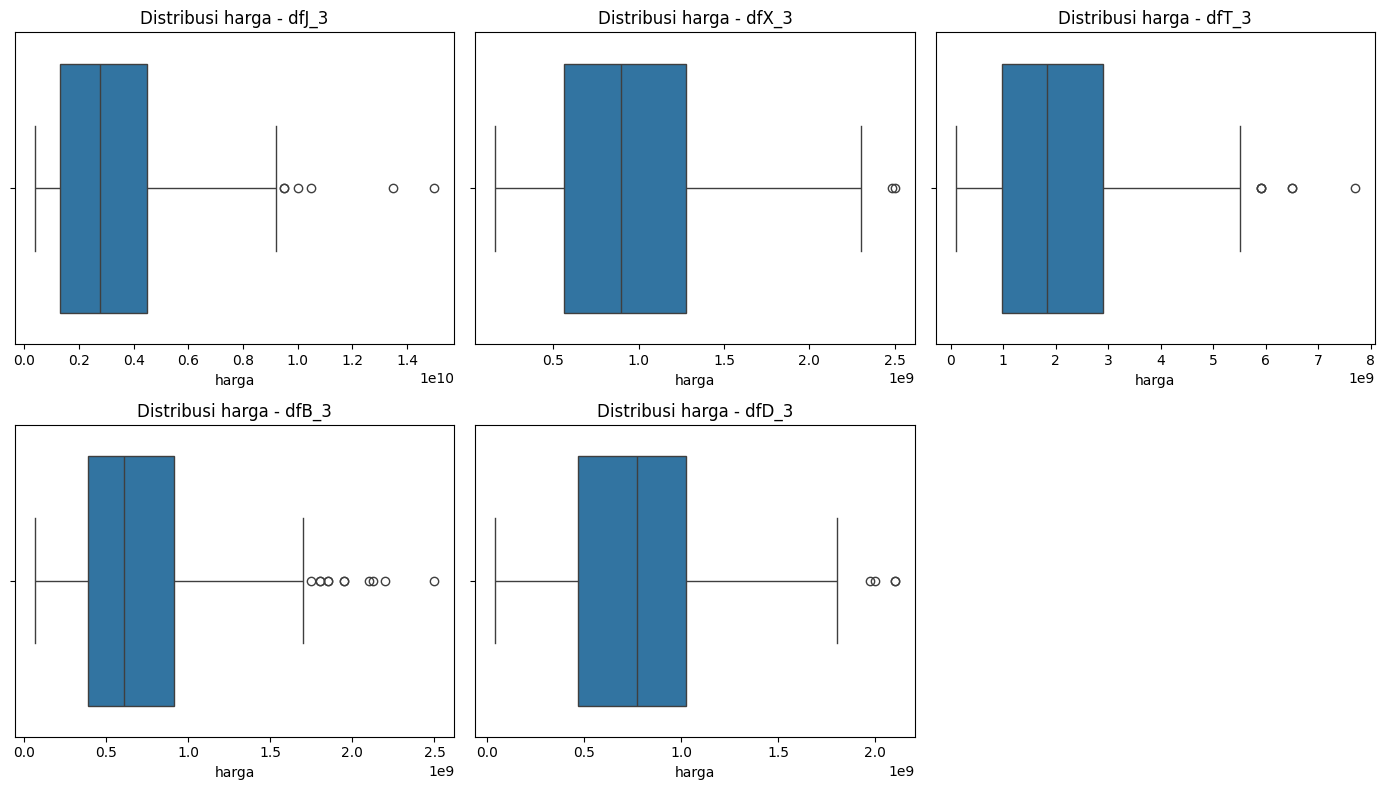

In [ ]:
# Bikin figure
plt.figure(figsize=(14, 8))

# Plot 1
plt.subplot(2, 3, 1)
sns.boxplot(x="harga", data=dfJ_3)
plt.title("Distribusi harga - dfJ_3")

# Plot 2
plt.subplot(2, 3, 2)
sns.boxplot(x="harga", data=dfX_3)
plt.title("Distribusi harga - dfX_3")

# Plot 3
plt.subplot(2, 3, 3)
sns.boxplot(x="harga", data=dfT_3)
plt.title("Distribusi harga - dfT_3")

# Plot 4
plt.subplot(2, 3, 4)
sns.boxplot(x="harga", data=dfB_3)
plt.title("Distribusi harga - dfB_3")

# Plot 5
plt.subplot(2, 3, 5)
sns.boxplot(x="harga", data=dfD_3)
plt.title("Distribusi harga - dfD_3")

plt.tight_layout()
plt.show()

Berdasarkan hasil visualisasi data-data yang telah dipisahkan dari outlier, didapatkan masing-masing data masih memiliki outlier, sehingga perlu dilakukan iterasi kedua.

In [ ]:
# Mengecek banyaknya outlier pada dataset Jakarta
Q1J_harga2 = dfJ_3['harga'].quantile(0.25)
Q2J_harga2 = dfJ_3['harga'].quantile(0.50)
Q3J_harga2 = dfJ_3['harga'].quantile(0.75)
IQRJ_harga2 = Q3J_harga2 - Q1J_harga2
outlierJ_harga2 = (dfJ_3['harga'] <= Q1J_harga2 - 1.5*IQRJ_harga2) | (dfJ_3['harga'] >= Q3J_harga2 + 1.5*IQRJ_harga2)
print("Banyaknya outlier = ",sum(outlierJ_harga2))

Banyaknya outlier =  6


In [ ]:
# Data outlier
dfJ_3_outlier_harga2 = dfJ_3[outlierJ_harga2]

# Data non-outlier
dfJ_3 = dfJ_3[~outlierJ_harga2]

# Menampilkan jumlah baris masing-masing
print("Jumlah data outlier:", len(dfJ_3_outlier_harga2))
print("Jumlah data non-outlier:", len(dfJ_3))

Jumlah data outlier: 6
Jumlah data non-outlier: 99


Dengan menggunakan rentang interquartil didapatkan jumlah outlier pada data Jakarta yaitu 6, dan non-outlier yaitu 99

In [ ]:
# Mengecek banyaknya outlier pada dataset Tangerang
Q1T_harga2 = dfT_3['harga'].quantile(0.25)
Q2T_harga2 = dfT_3['harga'].quantile(0.50)
Q3T_harga2 = dfT_3['harga'].quantile(0.75)
IQRT_harga2 = Q3T_harga2 - Q1T_harga2
outlierT_harga2 = (dfT_3['harga'] <= Q1T_harga2 - 1.5*IQRT_harga2) | (dfT_3['harga'] >= Q3T_harga2 + 1.5*IQRT_harga2)
print("Banyaknya outlier = ",sum(outlierT_harga2))

Banyaknya outlier =  6


In [ ]:
# Data outlier
dfT_3_outlier_harga2 = dfT_3[outlierT_harga2]

# Data non-outlier
dfT_3 = dfT_3[~outlierT_harga2]

# Menampilkan jumlah baris masing-masing
print("Jumlah data outlier:", len(dfT_3_outlier_harga2))
print("Jumlah data non-outlier:", len(dfT_3))

Jumlah data outlier: 6
Jumlah data non-outlier: 108


Dengan menggunakan rentang interquartil didapatkan jumlah outlier pada data Tangerang yaitu 6, dan non-outlier yaitu 108

In [ ]:
# Mengecek banyaknya outlier pada dataset Bogor
Q1B_harga2 = dfB_3['harga'].quantile(0.25)
Q2B_harga2 = dfB_3['harga'].quantile(0.50)
Q3B_harga2 = dfB_3['harga'].quantile(0.75)
IQRB_harga2 = Q3B_harga2 - Q1B_harga2
outlierB_harga2 = (dfB_3['harga'] <= Q1B_harga2 - 1.5*IQRB_harga2) | (dfB_3['harga'] >= Q3B_harga2 + 1.5*IQRB_harga2)
print("Banyaknya outlier = ",sum(outlierB_harga2))

Banyaknya outlier =  11


In [ ]:
# Data outlier
dfB_3_outlier_harga2 = dfB_3[outlierB_harga2]

# Data non-outlier
dfB_3 = dfB_3[~outlierB_harga2]

# Menampilkan jumlah baris masing-masing
print("Jumlah data outlier:", len(dfB_3_outlier_harga2))
print("Jumlah data non-outlier:", len(dfB_3))

Jumlah data outlier: 11
Jumlah data non-outlier: 163


Dengan menggunakan rentang interquartil didapatkan jumlah outlier pada data Bogor yaitu 11, dan non-outlier yaitu 163

In [ ]:
# Mengecek banyaknya outlier pada dataset Depok
Q1D_harga2 = dfD_3['harga'].quantile(0.25)
Q2D_harga2 = dfD_3['harga'].quantile(0.50)
Q3D_harga2 = dfD_3['harga'].quantile(0.75)
IQRD_harga2 = Q3D_harga2 - Q1D_harga2
outlierD_harga2 = (dfD_3['harga'] <= Q1D_harga2 - 1.5*IQRD_harga2) | (dfD_3['harga'] >= Q3D_harga2 + 1.5*IQRD_harga2)
print("Banyaknya outlier = ",sum(outlierD_harga2))

Banyaknya outlier =  4


In [ ]:
# Data outlier
dfD_3_outlier_harga2 = dfD_3[outlierD_harga2]

# Data non-outlier
dfD_3 = dfD_3[~outlierD_harga2]

# Menampilkan jumlah baris masing-masing
print("Jumlah data outlier:", len(dfD_3_outlier_harga2))
print("Jumlah data non-outlier:", len(dfD_3))

Jumlah data outlier: 4
Jumlah data non-outlier: 104


Dengan menggunakan rentang interquartil didapatkan jumlah outlier pada data Depok yaitu 4, dan non-outlier yaitu 104

In [ ]:
# Mengecek banyaknya outlier pada dataset Bekasi
Q1X_harga2 = dfX_3['harga'].quantile(0.25)
Q2X_harga2 = dfX_3['harga'].quantile(0.50)
Q3X_harga2 = dfX_3['harga'].quantile(0.75)
IQRX_harga2 = Q3X_harga2 - Q1X_harga2
outlierX_harga2 = (dfX_3['harga'] <= Q1X_harga2 - 1.5*IQRX_harga2) | (dfX_3['harga'] >= Q3X_harga2 + 1.5*IQRX_harga2)
print("Banyaknya outlier = ",sum(outlierX_harga2))

Banyaknya outlier =  2


In [ ]:
# Data outlier
dfX_3_outlier_harga2 = dfX_3[outlierX_harga2]

# Data non-outlier
dfX_3 = dfX_3[~outlierX_harga2]

# Menampilkan jumlah baris masing-masing
print("Jumlah data outlier:", len(dfX_3_outlier_harga2))
print("Jumlah data non-outlier:", len(dfX_3))

Jumlah data outlier: 2
Jumlah data non-outlier: 101


Dengan menggunakan rentang interquartil didapatkan jumlah outlier pada data Bekasi yaitu 2, dan non-outlier yaitu 101

In [ ]:
# Menambahkan (append) kumpulan data outlier harga yang baru terdeteksi ke dalam DataFrame harga_outlier_all yang sudah ada sebelumnya
harga_outlier_all = pd.concat([
    harga_outlier_all,
    dfJ_3_outlier_harga2,
    dfT_3_outlier_harga2,
    dfB_3_outlier_harga2,
    dfD_3_outlier_harga2,
    dfX_3_outlier_harga2
], ignore_index=True)

In [ ]:
harga_outlier_all

,created_at,LT,LB,KT,KM,carport,lokasi,sertifikat,listrik,harga,URL,deskripsi,kota
0,2021-12-06,424,1000,4.0,5.0,1,Jakarta Pusat,SHM,33000,49500000000,https://www.rumah.com/listing-properti/dijual-...,"Rumah mewah berkonsep hotel bintang 5, interio...",Jakarta Pusat
1,2021-12-06,597,700,5.0,4.0,5,Jakarta Pusat,SHM,8000,40000000000,https://www.rumah.com/listing-properti/dijual-...,Lokasi strategis hanya 5 menit ke pusat kulin...,Jakarta Pusat
2,2021-12-05,652,405,5.0,4.0,4,Jakarta Pusat,SHM,6600,45000000000,https://www.rumah.com/listing-properti/dijual-...,Dapat dinego,Jakarta Pusat
3,2021-12-05,840,800,5.0,3.0,8,Jakarta Pusat,SHGB,6600,39990000000,https://www.rumah.com/listing-properti/dijual-...,"1 Arah, Trotoar Besar, pepohonan rindang asri ...",Jakarta Pusat
4,2021-12-07,700,2000,10.0,10.0,10,Jakarta Pusat,SHM,66000,105000000000,https://www.rumah.com/listing-properti/dijual-...,- 2 menit ke Grand Indonesia (500 meter)\n- 5 ...,Jakarta Pusat
...,...,...,...,...,...,...,...,...,...,...,...,...,...
83,2021-12-06,210,250,4.0,4.0,1,Cimanggis,SHM,7700,2100000000,https://www.rumah123.com/properti/depok/hos928...,RUMAH DALAM KOMPLEK BESAR. JLN LEBAR. DEPOK,Depok Utara
84,2021-12-06,200,150,3.0,2.0,1,Cinere,SHM,2200,2000000000,https://www.rumah123.com/properti/depok/hos928...,"BEBAS BANJIR SEPANJANG MASA, BUKIT CINERE INDA...",Depok Selatan
85,2021-12-05,120,105,3.0,3.0,2,Cinere,SHM,2200,1970000000,https://www.rumah123.com/properti/depok/hos928...,Cluster strategis murah best area Cinere dkt t...,Depok Selatan
86,2021-12-03,364,494,5.0,2.0,1,Kota Bekasi,SHM,11000,2485000000,https://www.iklanrumah.com/list/detail/37392/r...,Rumah Mewah Pondok Pekayon Indah Siap Huni di ...,Kota Bekasi


<Axes: xlabel='harga'>

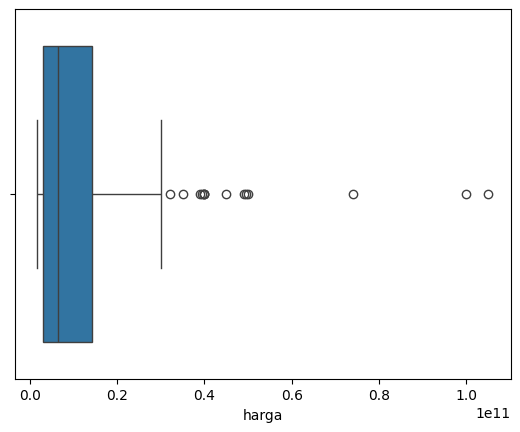

In [ ]:
# Memvisualisasikan distribusi dan ekstremitas harga outlier yang telah dikumpulkan dari semua kota
sns.boxplot(x='harga', data=harga_outlier_all)

### Hasil Penanganan

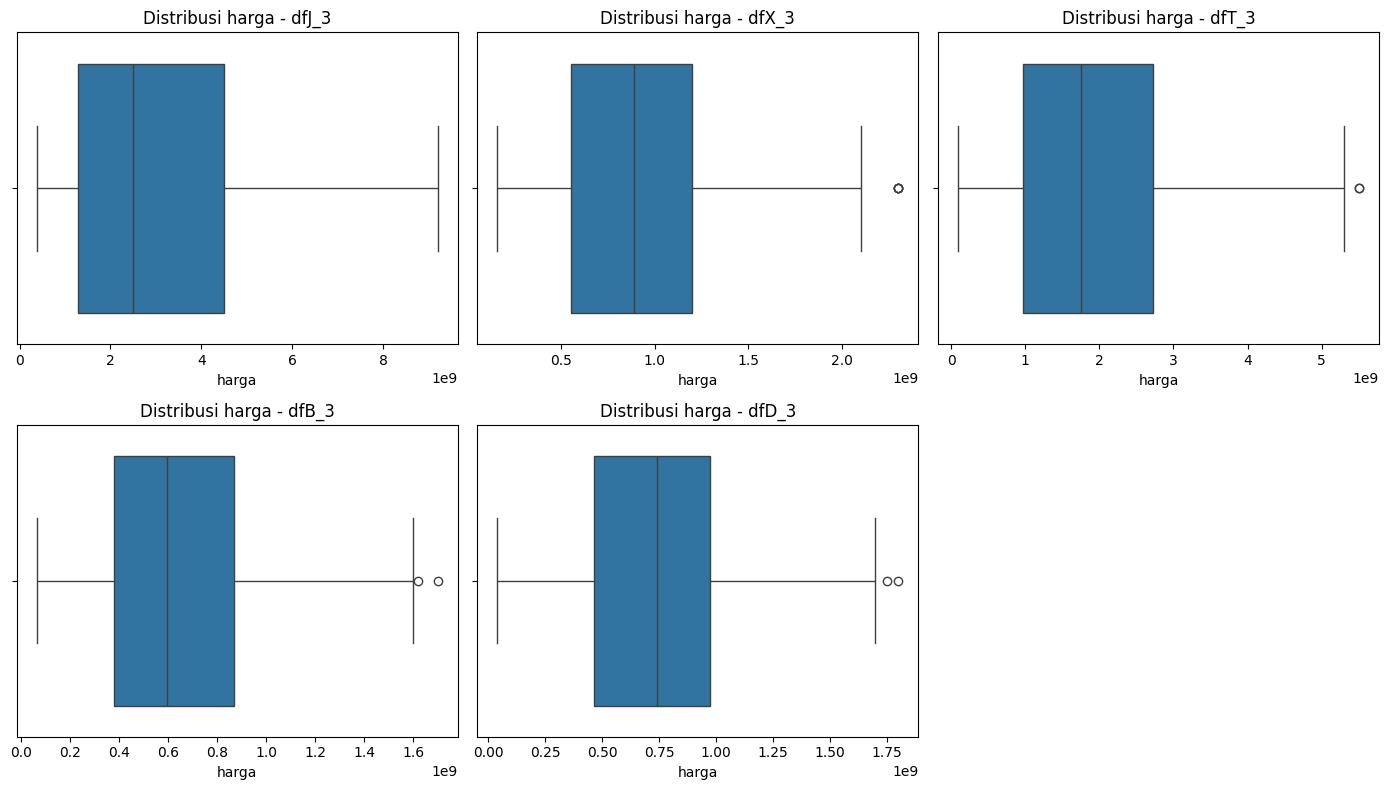

In [ ]:
# Bikin figure
plt.figure(figsize=(14, 8))

# Plot 1
plt.subplot(2, 3, 1)
sns.boxplot(x="harga", data=dfJ_3)
plt.title("Distribusi harga - dfJ_3")

# Plot 2
plt.subplot(2, 3, 2)
sns.boxplot(x="harga", data=dfX_3)
plt.title("Distribusi harga - dfX_3")

# Plot 3
plt.subplot(2, 3, 3)
sns.boxplot(x="harga", data=dfT_3)
plt.title("Distribusi harga - dfT_3")

# Plot 4
plt.subplot(2, 3, 4)
sns.boxplot(x="harga", data=dfB_3)
plt.title("Distribusi harga - dfB_3")

# Plot 5
plt.subplot(2, 3, 5)
sns.boxplot(x="harga", data=dfD_3)
plt.title("Distribusi harga - dfD_3")

plt.tight_layout()
plt.show()

## Outlier Kolom LT

### Iterasi Pertama

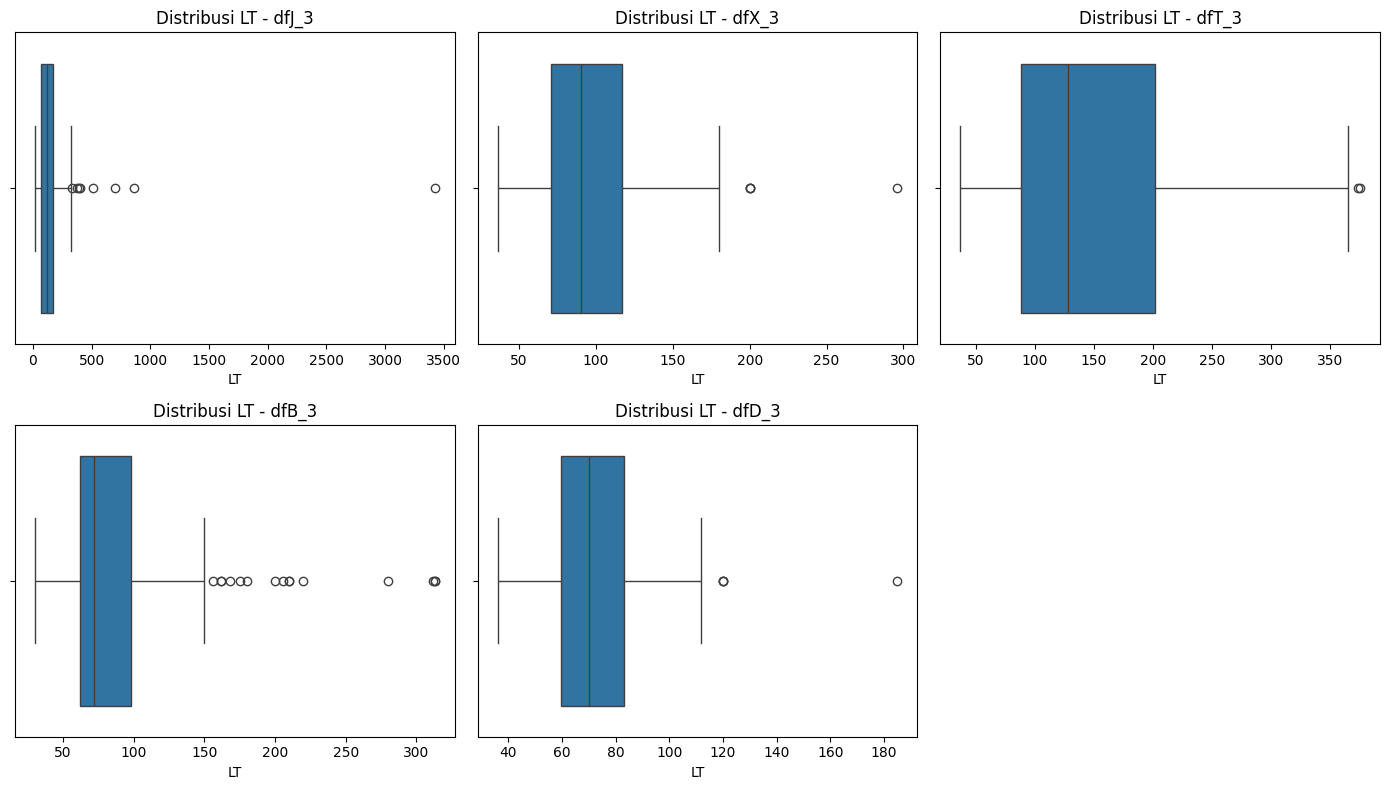

In [ ]:
# Bikin figure
plt.figure(figsize=(14, 8))

# Plot 1
plt.subplot(2, 3, 1)
sns.boxplot(x="LT", data=dfJ_3)
plt.title("Distribusi LT - dfJ_3")

# Plot 2
plt.subplot(2, 3, 2)
sns.boxplot(x="LT", data=dfX_3)
plt.title("Distribusi LT - dfX_3")

# Plot 3
plt.subplot(2, 3, 3)
sns.boxplot(x="LT", data=dfT_3)
plt.title("Distribusi LT - dfT_3")

# Plot 4
plt.subplot(2, 3, 4)
sns.boxplot(x="LT", data=dfB_3)
plt.title("Distribusi LT - dfB_3")

# Plot 5
plt.subplot(2, 3, 5)
sns.boxplot(x="LT", data=dfD_3)
plt.title("Distribusi LT - dfD_3")

plt.tight_layout()
plt.show()

Berikut merupakan visualisasi kolom LT dari masing-masing data, dan didapatkan outlier dimasing-masing boxplot data.

In [ ]:
# Mengecek banyaknya outlier pada dataset Jakarta
Q1J_LT = dfJ_3['LT'].quantile(0.25)
Q2J_LT = dfJ_3['LT'].quantile(0.50)
Q3J_LT = dfJ_3['LT'].quantile(0.75)
IQRJ_LT = Q3J_LT - Q1J_LT
outlierJ_LT = (dfJ_3['LT'] <= Q1J_LT - 1.5*IQRJ_LT) | (dfJ_3['LT'] >= Q3J_LT + 1.5*IQRJ_LT)
print("Banyaknya outlier = ",sum(outlierJ_LT))

Banyaknya outlier =  8


In [ ]:
# Data outlier
dfJ_3_outlier_LT = dfJ_3[outlierJ_LT]

# Data non-outlier
dfJ_3 = dfJ_3[~outlierJ_LT]

# Menampilkan jumlah baris masing-masing
print("Jumlah data outlier:", len(dfJ_3_outlier_LT))
print("Jumlah data non-outlier:", len(dfJ_3))

Jumlah data outlier: 8
Jumlah data non-outlier: 91


Dengan menggunakan rentang interquartil didapatkan jumlah outlier pada data Jakarta yaitu 8, dan non-outlier yaitu 91

In [ ]:
# Mengecek banyaknya outlier pada dataset Bekasi
Q1X_LT = dfX_3['LT'].quantile(0.25)
Q2X_LT = dfX_3['LT'].quantile(0.50)
Q3X_LT = dfX_3['LT'].quantile(0.75)
IQRX_LT = Q3X_LT - Q1X_LT
outlierX_LT = (dfX_3['LT'] <= Q1X_LT - 1.5*IQRX_LT) | (dfX_3['LT'] >= Q3X_LT + 1.5*IQRX_LT)
print("Banyaknya outlier = ",sum(outlierX_LT))

Banyaknya outlier =  4


In [ ]:
# Data outlier
dfX_3_outlier_LT = dfX_3[outlierX_LT]

# Data non-outlier
dfX_3 = dfX_3[~outlierX_LT]

# Menampilkan jumlah baris masing-masing
print("Jumlah data outlier:", len(dfX_3_outlier_LT))
print("Jumlah data non-outlier:", len(dfX_3))

Jumlah data outlier: 4
Jumlah data non-outlier: 97


Dengan menggunakan rentang interquartil didapatkan jumlah outlier pada data Bekasi yaitu 4, dan non-outlier yaitu 97

In [ ]:
# Mengecek banyaknya outlier pada dataset Tangerang
Q1T_LT = dfT_3['LT'].quantile(0.25)
Q2T_LT = dfT_3['LT'].quantile(0.50)
Q3T_LT = dfT_3['LT'].quantile(0.75)
IQRT_LT = Q3T_LT - Q1T_LT
outlierT_LT = (dfT_3['LT'] <= Q1T_LT - 1.5*IQRT_LT) | (dfT_3['LT'] >= Q3T_LT + 1.5*IQRT_LT)
print("Banyaknya outlier = ",sum(outlierT_LT))

Banyaknya outlier =  2


In [ ]:
# Data outlier
dfT_3_outlier_LT = dfT_3[outlierT_LT]

# Data non-outlier
dfT_3 = dfT_3[~outlierT_LT]

# Menampilkan jumlah baris masing-masing
print("Jumlah data outlier:", len(dfT_3_outlier_LT))
print("Jumlah data non-outlier:", len(dfT_3))

Jumlah data outlier: 2
Jumlah data non-outlier: 106


Dengan menggunakan rentang interquartil didapatkan jumlah outlier pada data Tangerang yaitu 2, dan non-outlier yaitu 106

In [ ]:
# Mengecek banyaknya outlier pada dataset Bogor
Q1B_LT = dfB_3['LT'].quantile(0.25)
Q2B_LT = dfB_3['LT'].quantile(0.50)
Q3B_LT = dfB_3['LT'].quantile(0.75)
IQRB_LT = Q3B_LT - Q1B_LT
outlierB_LT = (dfB_3['LT'] <= Q1B_LT - 1.5*IQRB_LT) | (dfB_3['LT'] >= Q3B_LT + 1.5*IQRB_LT)
print("Banyaknya outlier = ",sum(outlierB_LT))

Banyaknya outlier =  15


In [ ]:
# Data outlier
dfB_3_outlier_LT = dfB_3[outlierB_LT]

# Data non-outlier
dfB_3 = dfB_3[~outlierB_LT]

# Menampilkan jumlah baris masing-masing
print("Jumlah data outlier:", len(dfB_3_outlier_LT))
print("Jumlah data non-outlier:", len(dfB_3))

Jumlah data outlier: 15
Jumlah data non-outlier: 148


Dengan menggunakan rentang interquartil didapatkan jumlah outlier pada data Bogor yaitu 15, dan non-outlier yaitu 148

In [ ]:
# Mengecek banyaknya outlier pada dataset Depok
Q1D_LT = dfD_3['LT'].quantile(0.25)
Q2D_LT = dfD_3['LT'].quantile(0.50)
Q3D_LT = dfD_3['LT'].quantile(0.75)
IQRD_LT = Q3D_LT - Q1D_LT
outlierD_LT = (dfD_3['LT'] <= Q1D_LT - 1.5*IQRD_LT) | (dfD_3['LT'] >= Q3D_LT + 1.5*IQRD_LT)
print("Banyaknya outlier = ",sum(outlierD_LT))

Banyaknya outlier =  4


In [ ]:
# Data outlier
dfD_3_outlier_LT = dfD_3[outlierD_LT]

# Data non-outlier
dfD_3 = dfD_3[~outlierD_LT]

# Menampilkan jumlah baris masing-masing
print("Jumlah data outlier:", len(dfD_3_outlier_LT))
print("Jumlah data non-outlier:", len(dfD_3))

Jumlah data outlier: 4
Jumlah data non-outlier: 100


Dengan menggunakan rentang interquartil didapatkan jumlah outlier pada data Depok yaitu 15, dan non-outlier yaitu 148

In [ ]:
# Menggabungkan seluruh data outlier pada kolom LT (luas tanah) dari setiap kota menjadi satu DataFrame baru bernama lt_outlier_all
lt_outlier_all = pd.concat([
    dfJ_3_outlier_LT,
    dfX_3_outlier_LT,
    dfT_3_outlier_LT,
    dfB_3_outlier_LT,
    dfD_3_outlier_LT
], ignore_index=True)

In [ ]:
lt_outlier_all

,created_at,LT,LB,KT,KM,carport,lokasi,sertifikat,listrik,harga,URL,deskripsi,kota
0,2021-12-05,3422,64,1.0,1.0,1,Jakarta Pusat,SHM,2200,1050000000,https://www.rumah.com/listing-properti/dijual-...,Vlaster cempaka merupakan suatu kompleks perum...,Jakarta Pusat
1,2021-12-06,390,200,7.0,2.0,1,Jakarta Selatan,SHM,1300,3500000000,https://rumahdijual.com/tebet/11220328-dijual-...,Bangunan lama,Jakarta Selatan
2,2021-12-02,511,463,6.0,3.0,1,Jakarta Selatan,SHM,33000,4480000000,https://rumahdijual.com/tebet/11748387-jual-ru...,- Pondasi dan konstruksi beton bertulang\n- Ku...,Jakarta Selatan
3,2021-11-18,695,650,8.0,6.0,1,Jakarta Selatan,SHM,5500,9200000000,https://rumahdijual.com/tebet/9514888-rumah-cl...,"- Jumlah AC 8\n- Unfurnish, bangunan tahun 199...",Jakarta Selatan
4,2021-11-22,400,750,4.0,3.0,2,Jakarta Barat,SHM,5500,8000000000,https://www.rumah.com/listing-properti/dijual-...,NaN,Jakarta Barat
5,2021-11-15,863,500,5.0,3.0,3,Jakarta Barat,SHM,3500,8630000000,https://www.rumah.com/listing-properti/dijual-...,"Dijual cepat rumah asri 1 lantai, halaman luas...",Jakarta Barat
6,2021-12-06,330,400,5.0,6.0,3,Jakarta Utara,SHM,9900,8500000000,https://rumahdijual.com/8801692,- 2 meteran Listrik 4400 watt dan 5500 watt\n-...,Jakarta Utara
7,2021-10-06,375,198,7.0,3.0,1,Jakarta Utara,SHM,1300,2400000000,https://www.rumah.com/listing-properti/dijual-...,Dijual Cepat Rumah Koja Di Jakarta Utara Dng L...,Jakarta Utara
8,2021-12-06,296,200,4.0,2.0,1,Kota Bekasi,SHM,5500,2300000000,https://www.rumah123.com/properti/bekasi/hos84...,"Rumah Hoek dalam cluster Aralia, Rumah hadap t...",Kota Bekasi
9,2021-12-06,200,250,4.0,3.0,1,Kota Bekasi,SHM,2200,2300000000,https://www.rumah123.com/properti/bekasi/hos92...,rumah mewah dalam cluster eksklusif di harapan...,Kota Bekasi


<Axes: xlabel='LT'>

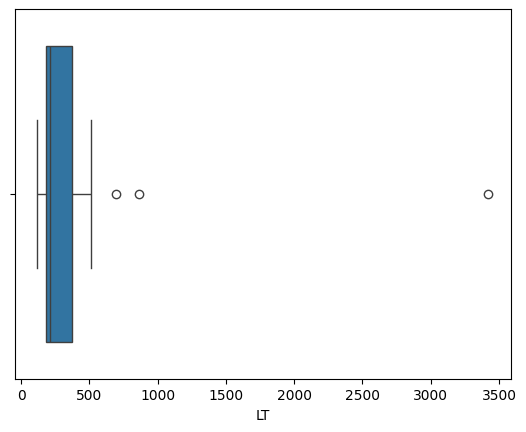

In [ ]:
# Membuat visualisasi boxplot kolom LT (Luas Tanah) dari DataFrame lt_outlier_all
sns.boxplot(x='LT', data=lt_outlier_all)

### Iterasi Kedua

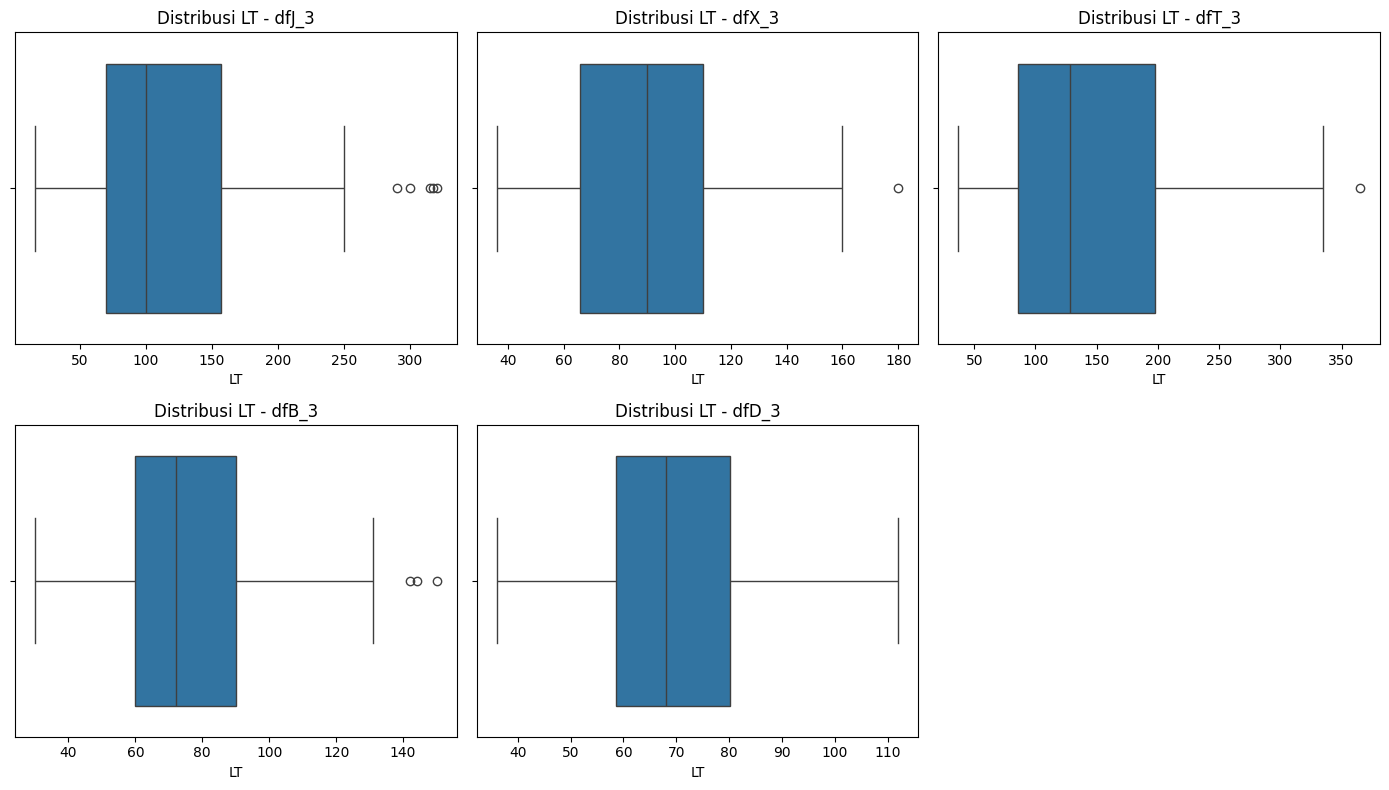

In [ ]:
# Bikin figure
plt.figure(figsize=(14, 8))

# Plot 1
plt.subplot(2, 3, 1)
sns.boxplot(x="LT", data=dfJ_3)
plt.title("Distribusi LT - dfJ_3")

# Plot 2
plt.subplot(2, 3, 2)
sns.boxplot(x="LT", data=dfX_3)
plt.title("Distribusi LT - dfX_3")

# Plot 3
plt.subplot(2, 3, 3)
sns.boxplot(x="LT", data=dfT_3)
plt.title("Distribusi LT - dfT_3")

# Plot 4
plt.subplot(2, 3, 4)
sns.boxplot(x="LT", data=dfB_3)
plt.title("Distribusi LT - dfB_3")

# Plot 5
plt.subplot(2, 3, 5)
sns.boxplot(x="LT", data=dfD_3)
plt.title("Distribusi LT - dfD_3")

plt.tight_layout()
plt.show()

In [ ]:
# Mengecek banyaknya outlier pada dataset Jakarta
Q1J_LT2 = dfJ_3['LT'].quantile(0.25)
Q2J_LT2 = dfJ_3['LT'].quantile(0.50)
Q3J_LT2 = dfJ_3['LT'].quantile(0.75)
IQRJ_LT2 = Q3J_LT2 - Q1J_LT2
outlierJ_LT2 = (dfJ_3['LT'] <= Q1J_LT2 - 1.5*IQRJ_LT2) | (dfJ_3['LT'] >= Q3J_LT2 + 1.5*IQRJ_LT2)
print("Banyaknya outlier = ",sum(outlierJ_LT2))

Banyaknya outlier =  5


In [ ]:
# Data outlier
dfJ_3_outlier_LT2 = dfJ_3[outlierJ_LT2]

# Data non-outlier
dfJ_3 = dfJ_3[~outlierJ_LT2]

# Menampilkan jumlah baris masing-masing
print("Jumlah data outlier:", len(dfJ_3_outlier_LT2))
print("Jumlah data non-outlier:", len(dfJ_3))

Jumlah data outlier: 5
Jumlah data non-outlier: 86


Dengan menggunakan rentang interquartil didapatkan jumlah outlier pada data Jakarta yaitu 5, dan non-outlier yaitu 86

In [ ]:
# Mengecek banyaknya outlier pada dataset Bekasi
Q1X_LT2 = dfX_3['LT'].quantile(0.25)
Q2X_LT2 = dfX_3['LT'].quantile(0.50)
Q3X_LT2 = dfX_3['LT'].quantile(0.75)
IQRX_LT2 = Q3X_LT2 - Q1X_LT2
outlierX_LT2 = (dfX_3['LT'] <= Q1X_LT2 - 1.5*IQRX_LT2) | (dfX_3['LT'] >= Q3X_LT2 + 1.5*IQRX_LT2)
print("Banyaknya outlier = ",sum(outlierX_LT2))

Banyaknya outlier =  1


In [ ]:
# Data outlier
dfX_3_outlier_LT2 = dfX_3[outlierX_LT2]

# Data non-outlier
dfX_3 = dfX_3[~outlierX_LT2]

# Menampilkan jumlah baris masing-masing
print("Jumlah data outlier:", len(dfX_3_outlier_LT2))
print("Jumlah data non-outlier:", len(dfX_3))

Jumlah data outlier: 1
Jumlah data non-outlier: 96


Dengan menggunakan rentang interquartil didapatkan jumlah outlier pada data Bekasi yaitu 1, dan non-outlier yaitu 96.

In [ ]:
# Mengecek banyaknya outlier pada dataset Tangerang
Q1T_LT2 = dfT_3['LT'].quantile(0.25)
Q2T_LT2 = dfT_3['LT'].quantile(0.50)
Q3T_LT2 = dfT_3['LT'].quantile(0.75)
IQRT_LT2 = Q3T_LT2 - Q1T_LT2
outlierT_LT2 = (dfT_3['LT'] <= Q1T_LT2 - 1.5*IQRT_LT2) | (dfT_3['LT'] >= Q3T_LT2 + 1.5*IQRT_LT2)
print("Banyaknya outlier = ",sum(outlierT_LT2))

Banyaknya outlier =  1


In [ ]:
# Data outlier
dfT_3_outlier_LT2 = dfT_3[outlierT_LT2]

# Data non-outlier
dfT_3 = dfT_3[~outlierT_LT2]

# Menampilkan jumlah baris masing-masing
print("Jumlah data outlier:", len(dfT_3_outlier_LT2))
print("Jumlah data non-outlier:", len(dfT_3))

Jumlah data outlier: 1
Jumlah data non-outlier: 105


Dengan menggunakan rentang interquartil didapatkan jumlah outlier pada data Tangerang yaitu 1, dan non-outlier yaitu 105.

In [ ]:
# Mengecek banyaknya outlier pada dataset Bogor
Q1B_LT2 = dfB_3['LT'].quantile(0.25)
Q2B_LT2 = dfB_3['LT'].quantile(0.50)
Q3B_LT2 = dfB_3['LT'].quantile(0.75)
IQRB_LT2 = Q3B_LT2 - Q1B_LT2
outlierB_LT2 = (dfB_3['LT'] <= Q1B_LT2 - 1.5*IQRB_LT2) | (dfB_3['LT'] >= Q3B_LT2 + 1.5*IQRB_LT2)
print("Banyaknya outlier = ",sum(outlierB_LT2))

Banyaknya outlier =  3


In [ ]:
# Data outlier
dfB_3_outlier_LT2 = dfB_3[outlierB_LT2]

# Data non-outlier
dfB_3 = dfB_3[~outlierB_LT2]

# Menampilkan jumlah baris masing-masing
print("Jumlah data outlier:", len(dfB_3_outlier_LT2))
print("Jumlah data non-outlier:", len(dfB_3))

Jumlah data outlier: 3
Jumlah data non-outlier: 145


Dengan menggunakan rentang interquartil didapatkan jumlah outlier pada data Bogor yaitu 3, dan non-outlier yaitu 145.

In [ ]:
# Mengecek banyaknya outlier pada dataset Depok
Q1D_LT2 = dfD_3['LT'].quantile(0.25)
Q2D_LT2 = dfD_3['LT'].quantile(0.50)
Q3D_LT2 = dfD_3['LT'].quantile(0.75)
IQRD_LT2 = Q3D_LT2 - Q1D_LT2
outlierD_LT2 = (dfD_3['LT'] <= Q1D_LT2 - 1.5*IQRD_LT2) | (dfD_3['LT'] >= Q3D_LT2 + 1.5*IQRD_LT2)
print("Banyaknya outlier = ",sum(outlierD_LT2))

Banyaknya outlier =  0


In [ ]:
# Data outlier
dfD_3_outlier_LT2 = dfD_3[outlierD_LT2]

# Data non-outlier
dfD_3 = dfD_3[~outlierD_LT2]

# Menampilkan jumlah baris masing-masing
print("Jumlah data outlier:", len(dfD_3_outlier_LT2))
print("Jumlah data non-outlier:", len(dfD_3))

Jumlah data outlier: 0
Jumlah data non-outlier: 100


Dengan menggunakan rentang interquartil didapatkan jumlah outlier pada data Depok yaitu 0, dan non-outlier yaitu 100.

In [ ]:
# Menambahkan (menggabungkan) data outlier luas tanah (LT) tahap kedua ke dalam DataFrame lt_outlier_all yang sudah berisi outlier tahap pertama
lt_outlier_all = pd.concat([
    lt_outlier_all,
    dfJ_3_outlier_LT2,
    dfX_3_outlier_LT2,
    dfT_3_outlier_LT2,
    dfB_3_outlier_LT2,
    dfD_3_outlier_LT2
], ignore_index=True)

In [ ]:
lt_outlier_all

,created_at,LT,LB,KT,KM,carport,lokasi,sertifikat,listrik,harga,URL,deskripsi,kota
0,2021-12-05,3422,64,1.0,1.0,1,Jakarta Pusat,SHM,2200,1050000000,https://www.rumah.com/listing-properti/dijual-...,Vlaster cempaka merupakan suatu kompleks perum...,Jakarta Pusat
1,2021-12-06,390,200,7.0,2.0,1,Jakarta Selatan,SHM,1300,3500000000,https://rumahdijual.com/tebet/11220328-dijual-...,Bangunan lama,Jakarta Selatan
2,2021-12-02,511,463,6.0,3.0,1,Jakarta Selatan,SHM,33000,4480000000,https://rumahdijual.com/tebet/11748387-jual-ru...,- Pondasi dan konstruksi beton bertulang\n- Ku...,Jakarta Selatan
3,2021-11-18,695,650,8.0,6.0,1,Jakarta Selatan,SHM,5500,9200000000,https://rumahdijual.com/tebet/9514888-rumah-cl...,"- Jumlah AC 8\n- Unfurnish, bangunan tahun 199...",Jakarta Selatan
4,2021-11-22,400,750,4.0,3.0,2,Jakarta Barat,SHM,5500,8000000000,https://www.rumah.com/listing-properti/dijual-...,NaN,Jakarta Barat
5,2021-11-15,863,500,5.0,3.0,3,Jakarta Barat,SHM,3500,8630000000,https://www.rumah.com/listing-properti/dijual-...,"Dijual cepat rumah asri 1 lantai, halaman luas...",Jakarta Barat
6,2021-12-06,330,400,5.0,6.0,3,Jakarta Utara,SHM,9900,8500000000,https://rumahdijual.com/8801692,- 2 meteran Listrik 4400 watt dan 5500 watt\n-...,Jakarta Utara
7,2021-10-06,375,198,7.0,3.0,1,Jakarta Utara,SHM,1300,2400000000,https://www.rumah.com/listing-properti/dijual-...,Dijual Cepat Rumah Koja Di Jakarta Utara Dng L...,Jakarta Utara
8,2021-12-06,296,200,4.0,2.0,1,Kota Bekasi,SHM,5500,2300000000,https://www.rumah123.com/properti/bekasi/hos84...,"Rumah Hoek dalam cluster Aralia, Rumah hadap t...",Kota Bekasi
9,2021-12-06,200,250,4.0,3.0,1,Kota Bekasi,SHM,2200,2300000000,https://www.rumah123.com/properti/bekasi/hos92...,rumah mewah dalam cluster eksklusif di harapan...,Kota Bekasi


<Axes: ylabel='LT'>

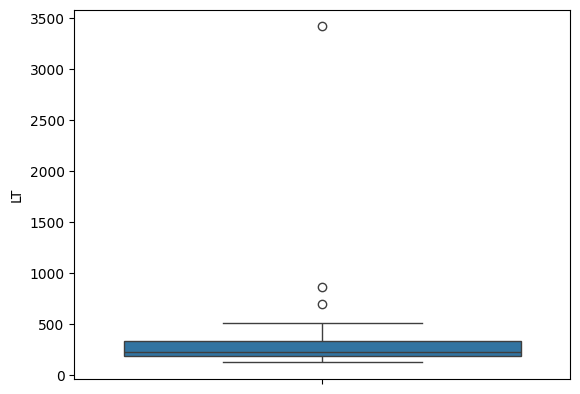

In [ ]:
# Membuat boxplot distribusi nilai kolom LT (luas tanah) dari DataFrame lt_outlier_all
sns.boxplot(lt_outlier_all['LT'])

### Hasil Penanganan

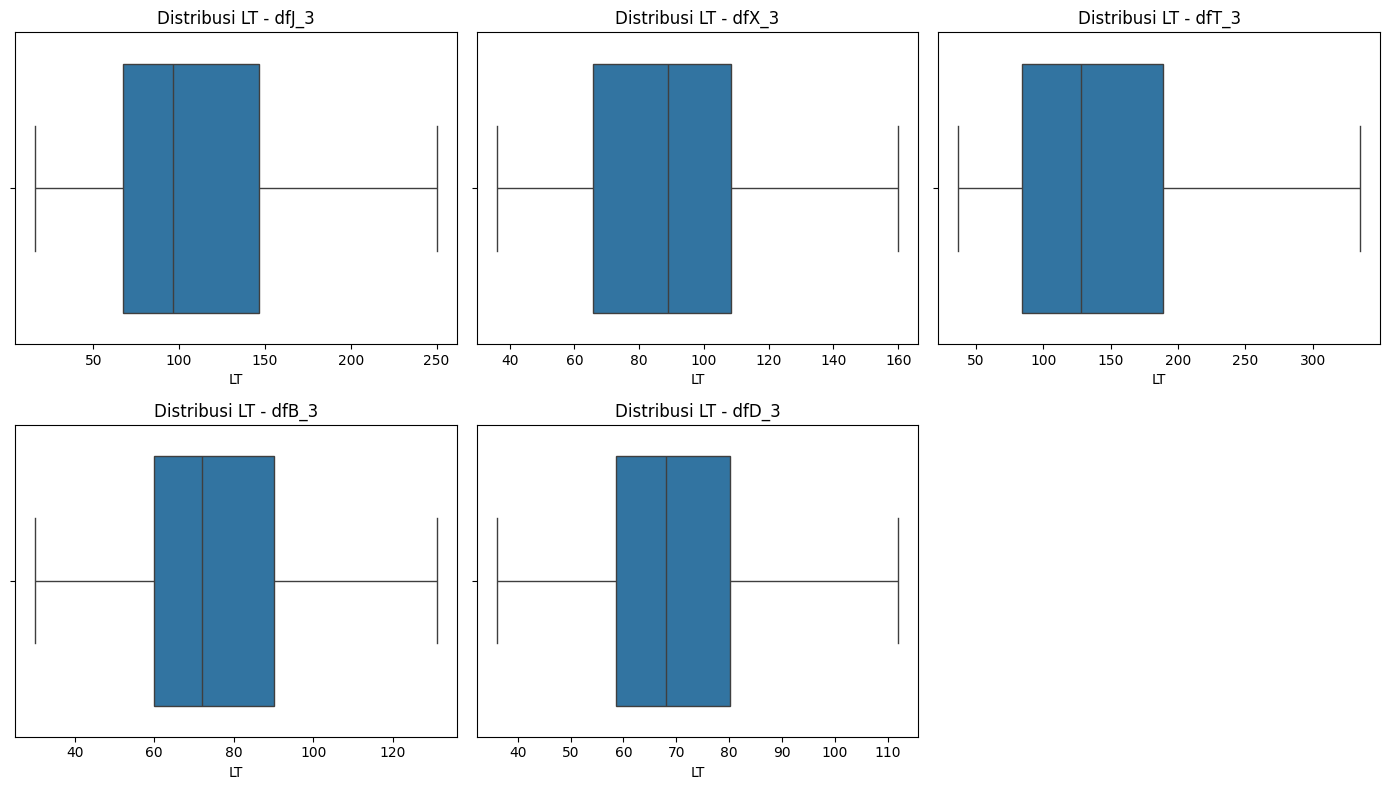

In [ ]:
# Bikin figure
plt.figure(figsize=(14, 8))

# Plot 1
plt.subplot(2, 3, 1)
sns.boxplot(x="LT", data=dfJ_3)
plt.title("Distribusi LT - dfJ_3")

# Plot 2
plt.subplot(2, 3, 2)
sns.boxplot(x="LT", data=dfX_3)
plt.title("Distribusi LT - dfX_3")

# Plot 3
plt.subplot(2, 3, 3)
sns.boxplot(x="LT", data=dfT_3)
plt.title("Distribusi LT - dfT_3")

# Plot 4
plt.subplot(2, 3, 4)
sns.boxplot(x="LT", data=dfB_3)
plt.title("Distribusi LT - dfB_3")

# Plot 5
plt.subplot(2, 3, 5)
sns.boxplot(x="LT", data=dfD_3)
plt.title("Distribusi LT - dfD_3")

plt.tight_layout()
plt.show()

## Outlier Kolom LB

### Iterasi Pertama

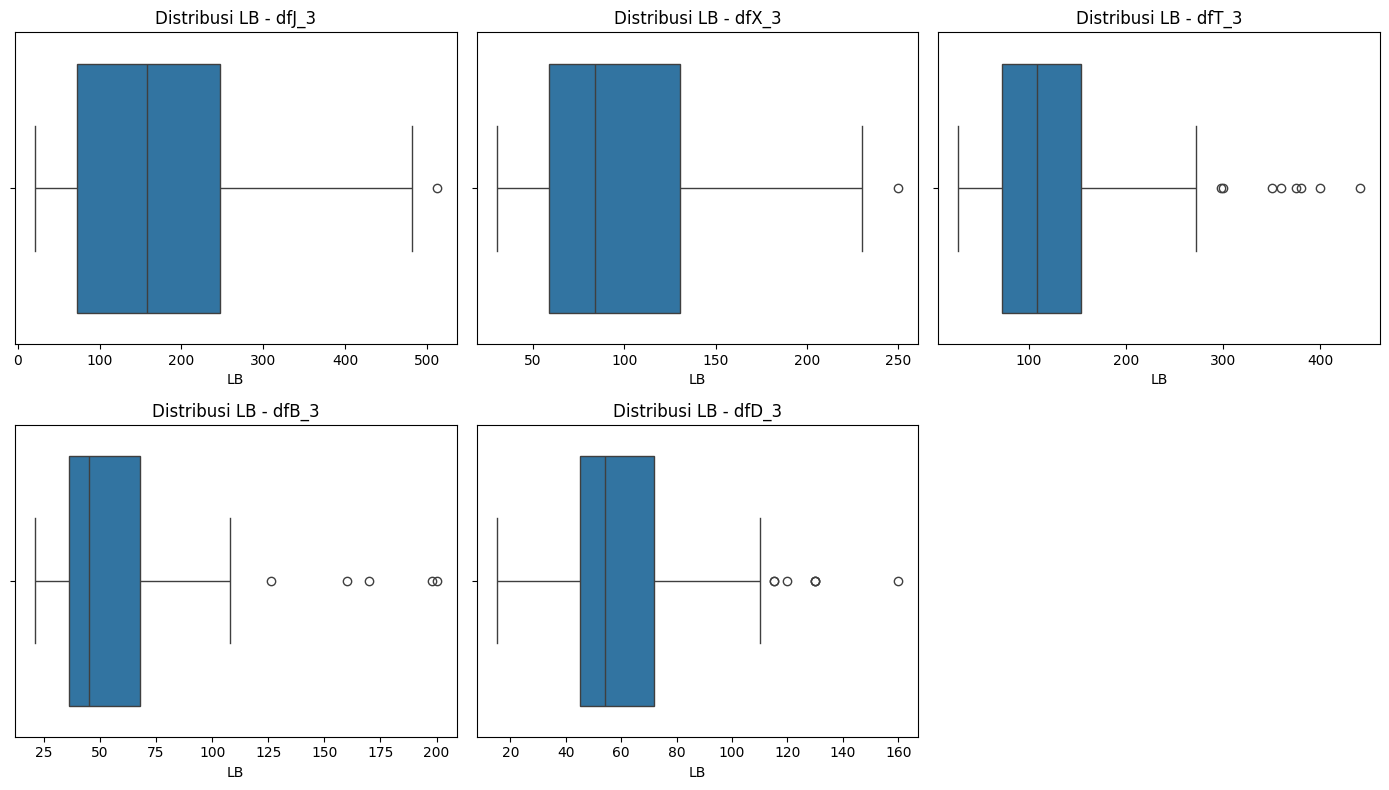

In [ ]:
# Bikin figure
plt.figure(figsize=(14, 8))

# Plot 1
plt.subplot(2, 3, 1)
sns.boxplot(x="LB", data=dfJ_3)
plt.title("Distribusi LB - dfJ_3")

# Plot 2
plt.subplot(2, 3, 2)
sns.boxplot(x="LB", data=dfX_3)
plt.title("Distribusi LB - dfX_3")

# Plot 3
plt.subplot(2, 3, 3)
sns.boxplot(x="LB", data=dfT_3)
plt.title("Distribusi LB - dfT_3")

# Plot 4
plt.subplot(2, 3, 4)
sns.boxplot(x="LB", data=dfB_3)
plt.title("Distribusi LB - dfB_3")

# Plot 5
plt.subplot(2, 3, 5)
sns.boxplot(x="LB", data=dfD_3)
plt.title("Distribusi LB - dfD_3")

plt.tight_layout()
plt.show()

In [ ]:
# Mengecek banyaknya outlier pada dataset Jakarta
Q1J_LB = dfJ_3['LB'].quantile(0.25)
Q2J_LB = dfJ_3['LB'].quantile(0.50)
Q3J_LB = dfJ_3['LB'].quantile(0.75)
IQRJ_LB = Q3J_LB - Q1J_LB
outlierJ_LB = (dfJ_3['LB'] <= Q1J_LB - 1.5*IQRJ_LB) | (dfJ_3['LB'] >= Q3J_LB + 1.5*IQRJ_LB)
print("Banyaknya outlier = ",sum(outlierJ_LB))

Banyaknya outlier =  1


In [ ]:
# Data outlier
dfJ_3_outlier_LB = dfJ_3[outlierJ_LB]

# Data non-outlier
dfJ_3 = dfJ_3[~outlierJ_LB]

# Menampilkan jumlah baris masing-masing
print("Jumlah data outlier:", len(dfJ_3_outlier_LB))
print("Jumlah data non-outlier:", len(dfJ_3))

Jumlah data outlier: 1
Jumlah data non-outlier: 85


Dengan menggunakan rentang interquartil didapatkan jumlah outlier pada data Jakarta yaitu 1, dan non-outlier yaitu 85.

In [ ]:
# Mengecek banyaknya outlier pada dataset Bekasi
Q1X_LB = dfX_3['LB'].quantile(0.25)
Q2X_LB = dfX_3['LB'].quantile(0.50)
Q3X_LB = dfX_3['LB'].quantile(0.75)
IQRX_LB = Q3X_LB - Q1X_LB
outlierX_LB = (dfX_3['LB'] <= Q1X_LB - 1.5*IQRX_LB) | (dfX_3['LB'] >= Q3X_LB + 1.5*IQRX_LB)
print("Banyaknya outlier = ",sum(outlierX_LB))

Banyaknya outlier =  1


In [ ]:
# Data outlier
dfX_3_outlier_LB = dfX_3[outlierX_LB]

# Data non-outlier
dfX_3 = dfX_3[~outlierX_LB]

# Menampilkan jumlah baris masing-masing
print("Jumlah data outlier:", len(dfX_3_outlier_LB))
print("Jumlah data non-outlier:", len(dfX_3))

Jumlah data outlier: 1
Jumlah data non-outlier: 95


Dengan menggunakan rentang interquartil didapatkan jumlah outlier pada data Bekasi yaitu 1, dan non-outlier yaitu 95.

In [ ]:
# Mengecek banyaknya outlier pada dataset Tangerang
Q1T_LB = dfT_3['LB'].quantile(0.25)
Q2T_LB = dfT_3['LB'].quantile(0.50)
Q3T_LB = dfT_3['LB'].quantile(0.75)
IQRT_LB = Q3T_LB - Q1T_LB
outlierT_LB = (dfT_3['LB'] <= Q1T_LB - 1.5*IQRT_LB) | (dfT_3['LB'] >= Q3T_LB + 1.5*IQRT_LB)
print("Banyaknya outlier = ",sum(outlierT_LB))

Banyaknya outlier =  8


In [ ]:
# Data outlier
dfT_3_outlier_LB = dfT_3[outlierT_LB]

# Data non-outlier
dfT_3 = dfT_3[~outlierT_LB]

# Menampilkan jumlah baris masing-masing
print("Jumlah data outlier:", len(dfT_3_outlier_LB))
print("Jumlah data non-outlier:", len(dfT_3))

Jumlah data outlier: 8
Jumlah data non-outlier: 97


Dengan menggunakan rentang interquartil didapatkan jumlah outlier pada data Tangerang yaitu 8, dan non-outlier yaitu 97.

In [ ]:
# Mengecek banyaknya outlier pada dataset Bogor
Q1B_LB = dfB_3['LB'].quantile(0.25)
Q2B_LB = dfB_3['LB'].quantile(0.50)
Q3B_LB = dfB_3['LB'].quantile(0.75)
IQRB_LB = Q3B_LB - Q1B_LB
outlierB_LB = (dfB_3['LB'] <= Q1B_LB - 1.5*IQRB_LB) | (dfB_3['LB'] >= Q3B_LB + 1.5*IQRB_LB)
print("Banyaknya outlier = ",sum(outlierB_LB))

Banyaknya outlier =  5


In [ ]:
# Data outlier
dfB_3_outlier_LB = dfB_3[outlierB_LB]

# Data non-outlier
dfB_3 = dfB_3[~outlierB_LB]

# Menampilkan jumlah baris masing-masing
print("Jumlah data outlier:", len(dfB_3_outlier_LB))
print("Jumlah data non-outlier:", len(dfB_3))

Jumlah data outlier: 5
Jumlah data non-outlier: 140


Dengan menggunakan rentang interquartil didapatkan jumlah outlier pada data Bogor yaitu 5, dan non-outlier yaitu 140.

In [ ]:
# Mengecek banyaknya outlier pada dataset Depok
Q1D_LB = dfD_3['LB'].quantile(0.25)
Q2D_LB = dfD_3['LB'].quantile(0.50)
Q3D_LB = dfD_3['LB'].quantile(0.75)
IQRD_LB = Q3D_LB - Q1D_LB
outlierD_LB = (dfD_3['LB'] <= Q1D_LB - 1.5*IQRD_LB) | (dfD_3['LB'] >= Q3D_LB + 1.5*IQRD_LB)
print("Banyaknya outlier = ",sum(outlierD_LB))

Banyaknya outlier =  7


In [ ]:
# Data outlier
dfD_3_outlier_LB = dfD_3[outlierD_LB]

# Data non-outlier
dfD_3 = dfD_3[~outlierD_LB]

# Menampilkan jumlah baris masing-masing
print("Jumlah data outlier:", len(dfD_3_outlier_LB))
print("Jumlah data non-outlier:", len(dfD_3))

Jumlah data outlier: 7
Jumlah data non-outlier: 93


Dengan menggunakan rentang interquartil didapatkan jumlah outlier pada data Depok yaitu 7, dan non-outlier yaitu 93.

In [ ]:
# Menggabungkan semua data outlier pada kolom LB (luas bangunan) dari berbagai kota ke dalam satu DataFrame bernama lb_outlier_all.
lb_outlier_all = pd.concat([
    dfJ_3_outlier_LB,
    dfX_3_outlier_LB,
    dfT_3_outlier_LB,
    dfB_3_outlier_LB,
    dfD_3_outlier_LB
], ignore_index=True)

In [ ]:
lb_outlier_all

,created_at,LT,LB,KT,KM,carport,lokasi,sertifikat,listrik,harga,URL,deskripsi,kota
0,2021-11-15,175,512,6.0,5.0,1,Jakarta Utara,SHM,5500,7250000000,https://www.rumah.com/listing-properti/dijual-...,Rumah Bagus Strategis Komplek Perumahan Sunter...,Jakarta Utara
1,2021-12-01,140,250,3.0,2.0,1,Kabupaten Bekasi,SHM,2200,850000000,https://www.rumah123.com/properti/bekasi/hos92...,"DIJUAL RUMAH, Taman Kebalen bekasi cluster, Ju...",Kabupaten Bekasi
2,2021-12-06,250,360,5.0,4.0,1,"BENDA, TANGERANG",SHM,4400,2900000000,https://www.rumah123.com/properti/tangerang/ho...,"Memiliki lantai granit, 1 gudang, Water heater...",KOTA TANGERANG
3,2021-12-06,205,298,4.0,4.0,2,"BSD CITY, TANGERANG",SHM,4400,4700000000,https://www.rumah123.com/properti/tangerang/ho...,Rumah Baru di The Green Cluster Vineyard BSD C...,KOTA TANGERANG SELATAN
4,2021-12-06,250,380,6.0,4.0,1,"BSD, TANGERANG",SHM,5500,5050000000,https://www.rumah123.com/properti/tangerang/ho...,"Rumah di kawasan BSD, Luas tanah : 250 m2, Lua...",KOTA TANGERANG SELATAN
5,2021-12-06,234,300,5.0,5.0,2,"BSD, TANGERANG",HGB,4400,3900000000,https://www.rumah123.com/properti/tangerang/ho...,"Dijual Rumah Cluster Anthea BSD, Luas tanah 23...",KOTA TANGERANG SELATAN
6,2021-12-06,300,400,4.0,4.0,2,"BSD CITY, TANGERANG",SHM,4400,4700000000,https://www.rumah123.com/properti/tangerang/ho...,"LT 300, LB 400, KT 4+2, KM 4+2, SHM, PAM, Line...",KOTA TANGERANG SELATAN
7,2021-12-06,240,350,4.0,4.0,1,"BSD CITY, TANGERANG",SHM,7700,5200000000,https://www.rumah123.com/properti/tangerang/ho...,"Lt 240, Lb 350, Kt 4+2, Km. 4+1, 5300 watt, Le...",KOTA TANGERANG SELATAN
8,2021-12-07,300,375,4.0,2.0,3,"BSD, TANGERANG",SHM,2200,5500000000,https://www.rumah123.com/properti/tangerang/ho...,Dekat dengan berbagai fasilitas seperti : Seko...,KOTA TANGERANG SELATAN
9,2021-12-07,276,441,4.0,4.0,2,"BSD, TANGERANG",SHM,11000,1260000000,https://www.rumah123.com/properti/tangerang/ho...,Cluster Laurel at Navapark. Modern Tropical Li...,KOTA TANGERANG SELATAN


<Axes: xlabel='LB'>

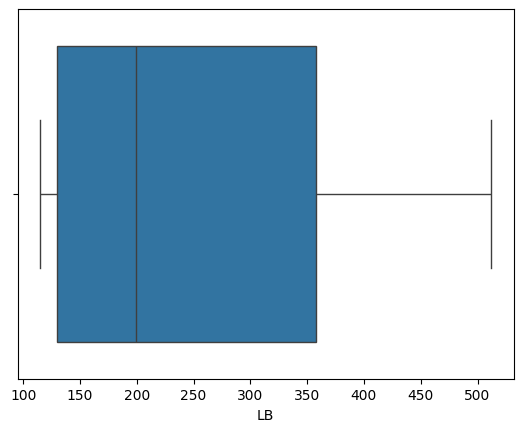

In [ ]:
# Melihat distribusi dan sebaran outlier Luas Bangunan (LB)
sns.boxplot(x='LB', data=lb_outlier_all)

### Iterasi Kedua

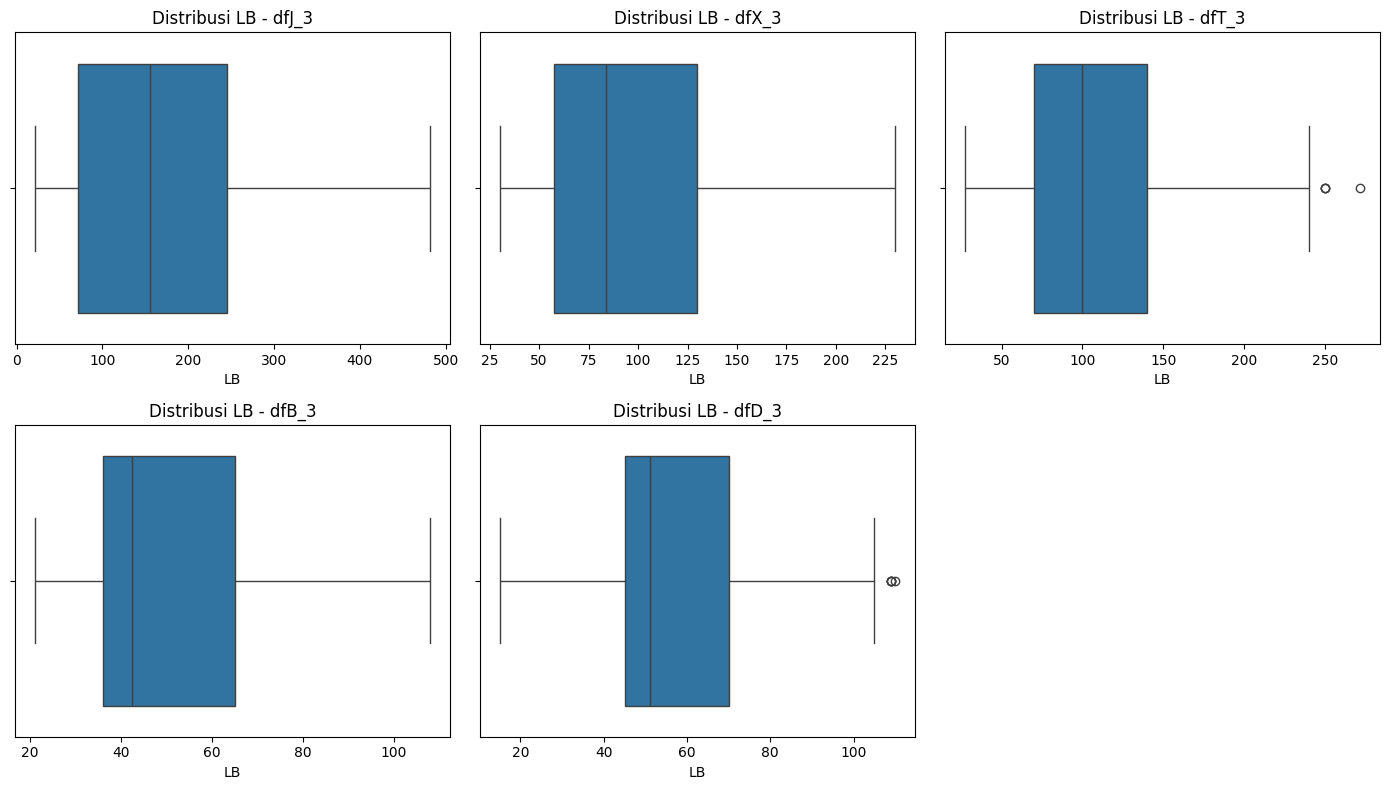

In [ ]:
# Bikin figure
plt.figure(figsize=(14, 8))

# Plot 1
plt.subplot(2, 3, 1)
sns.boxplot(x="LB", data=dfJ_3)
plt.title("Distribusi LB - dfJ_3")

# Plot 2
plt.subplot(2, 3, 2)
sns.boxplot(x="LB", data=dfX_3)
plt.title("Distribusi LB - dfX_3")

# Plot 3
plt.subplot(2, 3, 3)
sns.boxplot(x="LB", data=dfT_3)
plt.title("Distribusi LB - dfT_3")

# Plot 4
plt.subplot(2, 3, 4)
sns.boxplot(x="LB", data=dfB_3)
plt.title("Distribusi LB - dfB_3")

# Plot 5
plt.subplot(2, 3, 5)
sns.boxplot(x="LB", data=dfD_3)
plt.title("Distribusi LB - dfD_3")

plt.tight_layout()
plt.show()

In [ ]:
# Mengecek banyaknya outlier pada dataset Tangerang
Q1T_LB2 = dfT_3['LB'].quantile(0.25)
Q2T_LB2 = dfT_3['LB'].quantile(0.50)
Q3T_LB2 = dfT_3['LB'].quantile(0.75)
IQRT_LB2 = Q3T_LB2 - Q1T_LB2
outlierT_LB2 = (dfT_3['LB'] <= Q1T_LB2 - 1.5*IQRT_LB2) | (dfT_3['LB'] >= Q3T_LB2 + 1.5*IQRT_LB2)
print("Banyaknya outlier = ",sum(outlierT_LB2))

Banyaknya outlier =  4


In [ ]:
# Data outlier
dfT_3_outlier_LB2 = dfT_3[outlierT_LB2]

# Data non-outlier
dfT_3 = dfT_3[~outlierT_LB2]

# Menampilkan jumlah baris masing-masing
print("Jumlah data outlier:", len(dfT_3_outlier_LB2))
print("Jumlah data non-outlier:", len(dfT_3))

Jumlah data outlier: 4
Jumlah data non-outlier: 93


Dengan menggunakan rentang interquartil didapatkan jumlah outlier pada data Tangerang yaitu 4, dan non-outlier yaitu 93.

In [ ]:
# Mengecek banyaknya outlier pada dataset Depok
Q1D_LB2 = dfD_3['LB'].quantile(0.25)
Q2D_LB2 = dfD_3['LB'].quantile(0.50)
Q3D_LB2 = dfD_3['LB'].quantile(0.75)
IQRD_LB2 = Q3D_LB2 - Q1D_LB2
outlierD_LB2 = (dfD_3['LB'] <= Q1D_LB2 - 1.5*IQRD_LB2) | (dfD_3['LB'] >= Q3D_LB2 + 1.5*IQRD_LB2)
print("Banyaknya outlier = ",sum(outlierD_LB2))

Banyaknya outlier =  5


In [ ]:
# Data outlier
dfD_3_outlier_LB2 = dfD_3[outlierD_LB2]

# Data non-outlier
dfD_3 = dfD_3[~outlierD_LB2]

# Menampilkan jumlah baris masing-masing
print("Jumlah data outlier:", len(dfD_3_outlier_LB2))
print("Jumlah data non-outlier:", len(dfD_3))

Jumlah data outlier: 5
Jumlah data non-outlier: 88


Dengan menggunakan rentang interquartil didapatkan jumlah outlier pada data Depok yaitu 5, dan non-outlier yaitu 88.

In [ ]:
# Memperbarui (menambahkan) daftar outlier pada kolom LB (luas bangunan) dengan outlier tambahan dari tahap baru.
lb_outlier_all = pd.concat([
    lb_outlier_all,
    dfT_3_outlier_LB2,
    dfD_3_outlier_LB2
], ignore_index=True)

In [ ]:
lb_outlier_all

,created_at,LT,LB,KT,KM,carport,lokasi,sertifikat,listrik,harga,URL,deskripsi,kota
0,2021-11-15,175,512,6.0,5.0,1,Jakarta Utara,SHM,5500,7250000000,https://www.rumah.com/listing-properti/dijual-...,Rumah Bagus Strategis Komplek Perumahan Sunter...,Jakarta Utara
1,2021-12-01,140,250,3.0,2.0,1,Kabupaten Bekasi,SHM,2200,850000000,https://www.rumah123.com/properti/bekasi/hos92...,"DIJUAL RUMAH, Taman Kebalen bekasi cluster, Ju...",Kabupaten Bekasi
2,2021-12-06,250,360,5.0,4.0,1,"BENDA, TANGERANG",SHM,4400,2900000000,https://www.rumah123.com/properti/tangerang/ho...,"Memiliki lantai granit, 1 gudang, Water heater...",KOTA TANGERANG
3,2021-12-06,205,298,4.0,4.0,2,"BSD CITY, TANGERANG",SHM,4400,4700000000,https://www.rumah123.com/properti/tangerang/ho...,Rumah Baru di The Green Cluster Vineyard BSD C...,KOTA TANGERANG SELATAN
4,2021-12-06,250,380,6.0,4.0,1,"BSD, TANGERANG",SHM,5500,5050000000,https://www.rumah123.com/properti/tangerang/ho...,"Rumah di kawasan BSD, Luas tanah : 250 m2, Lua...",KOTA TANGERANG SELATAN
5,2021-12-06,234,300,5.0,5.0,2,"BSD, TANGERANG",HGB,4400,3900000000,https://www.rumah123.com/properti/tangerang/ho...,"Dijual Rumah Cluster Anthea BSD, Luas tanah 23...",KOTA TANGERANG SELATAN
6,2021-12-06,300,400,4.0,4.0,2,"BSD CITY, TANGERANG",SHM,4400,4700000000,https://www.rumah123.com/properti/tangerang/ho...,"LT 300, LB 400, KT 4+2, KM 4+2, SHM, PAM, Line...",KOTA TANGERANG SELATAN
7,2021-12-06,240,350,4.0,4.0,1,"BSD CITY, TANGERANG",SHM,7700,5200000000,https://www.rumah123.com/properti/tangerang/ho...,"Lt 240, Lb 350, Kt 4+2, Km. 4+1, 5300 watt, Le...",KOTA TANGERANG SELATAN
8,2021-12-07,300,375,4.0,2.0,3,"BSD, TANGERANG",SHM,2200,5500000000,https://www.rumah123.com/properti/tangerang/ho...,Dekat dengan berbagai fasilitas seperti : Seko...,KOTA TANGERANG SELATAN
9,2021-12-07,276,441,4.0,4.0,2,"BSD, TANGERANG",SHM,11000,1260000000,https://www.rumah123.com/properti/tangerang/ho...,Cluster Laurel at Navapark. Modern Tropical Li...,KOTA TANGERANG SELATAN


### Hasil Penanganan

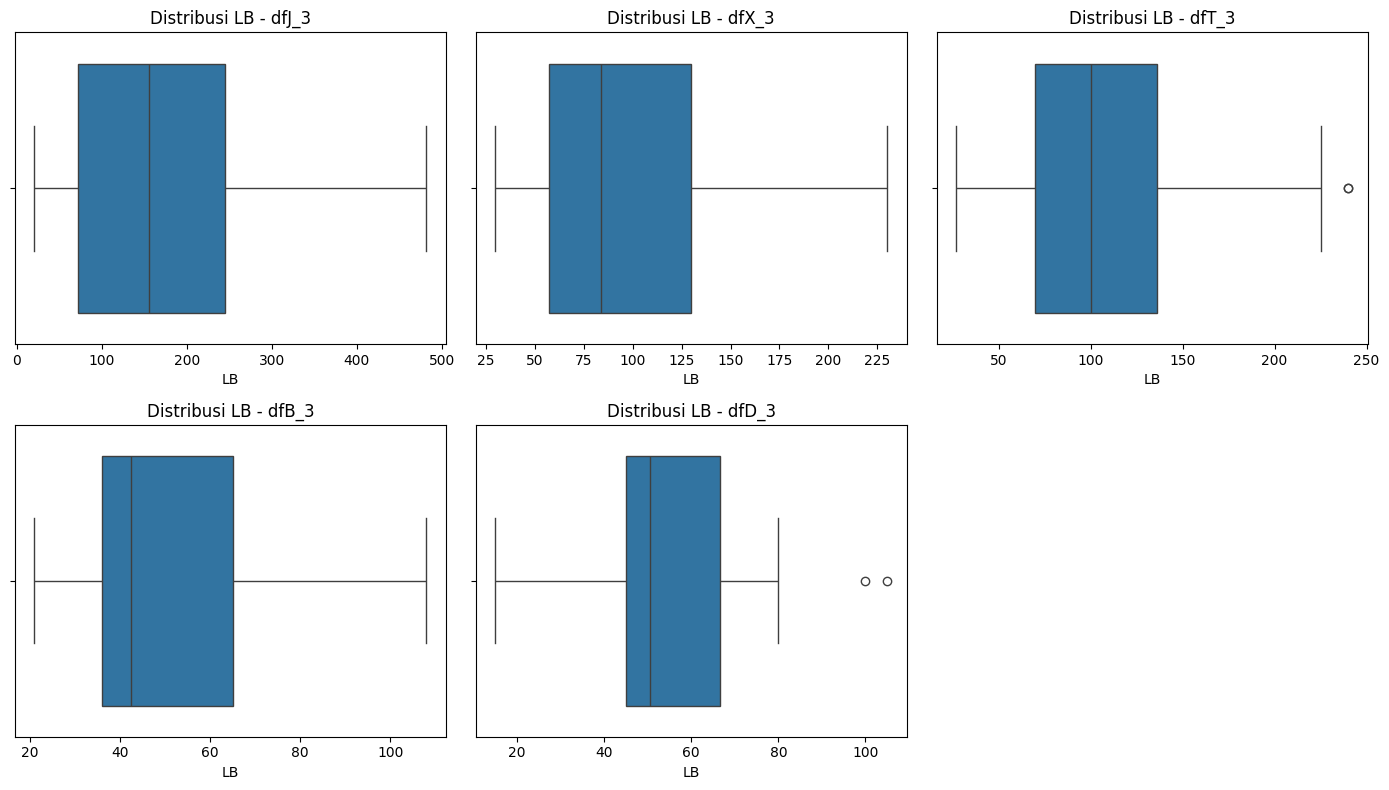

In [ ]:
# Bikin figure
plt.figure(figsize=(14, 8))

# Plot 1
plt.subplot(2, 3, 1)
sns.boxplot(x="LB", data=dfJ_3)
plt.title("Distribusi LB - dfJ_3")

# Plot 2
plt.subplot(2, 3, 2)
sns.boxplot(x="LB", data=dfX_3)
plt.title("Distribusi LB - dfX_3")

# Plot 3
plt.subplot(2, 3, 3)
sns.boxplot(x="LB", data=dfT_3)
plt.title("Distribusi LB - dfT_3")

# Plot 4
plt.subplot(2, 3, 4)
sns.boxplot(x="LB", data=dfB_3)
plt.title("Distribusi LB - dfB_3")

# Plot 5
plt.subplot(2, 3, 5)
sns.boxplot(x="LB", data=dfD_3)
plt.title("Distribusi LB - dfD_3")

plt.tight_layout()
plt.show()

## Outlier Kolom Listrik

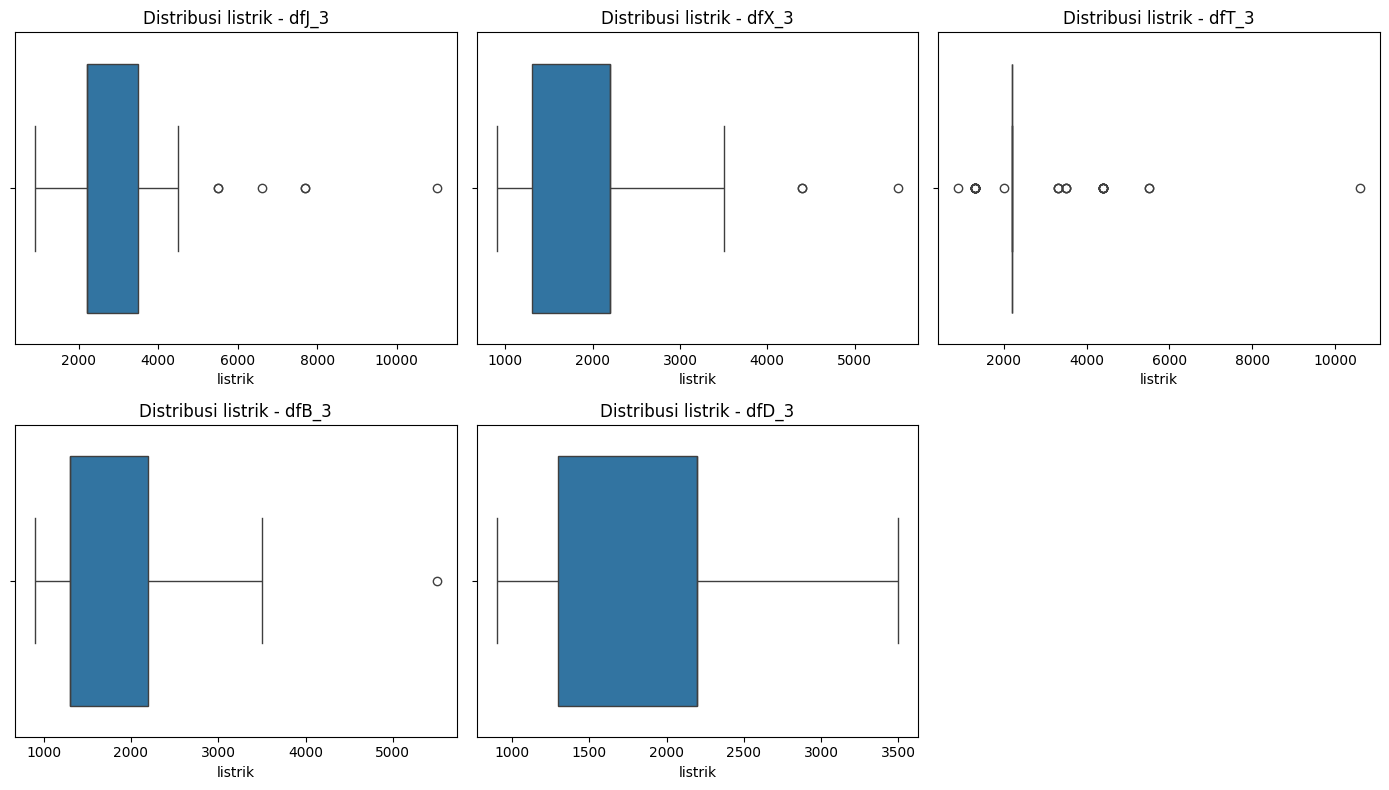

In [ ]:
# Bikin figure
plt.figure(figsize=(14, 8))

# Plot 1
plt.subplot(2, 3, 1)
sns.boxplot(x="listrik", data=dfJ_3)
plt.title("Distribusi listrik - dfJ_3")

# Plot 2
plt.subplot(2, 3, 2)
sns.boxplot(x="listrik", data=dfX_3)
plt.title("Distribusi listrik - dfX_3")

# Plot 3
plt.subplot(2, 3, 3)
sns.boxplot(x="listrik", data=dfT_3)
plt.title("Distribusi listrik - dfT_3")

# Plot 4
plt.subplot(2, 3, 4)
sns.boxplot(x="listrik", data=dfB_3)
plt.title("Distribusi listrik - dfB_3")

# Plot 5
plt.subplot(2, 3, 5)
sns.boxplot(x="listrik", data=dfD_3)
plt.title("Distribusi listrik - dfD_3")

plt.tight_layout()
plt.show()

In [ ]:
# Mengecek banyaknya outlier pada dataset Jakarta
Q1J_listrik = dfJ_3['listrik'].quantile(0.25)
Q2J_listrik = dfJ_3['listrik'].quantile(0.50)
Q3J_listrik = dfJ_3['listrik'].quantile(0.75)
IQRJ_listrik = Q3J_listrik - Q1J_listrik
outlierJ_listrik = (dfJ_3['listrik'] <= Q1J_listrik - 1.5*IQRJ_listrik) | (dfJ_3['listrik'] >= Q3J_listrik + 1.5*IQRJ_listrik)
print("Banyaknya outlier = ",sum(outlierJ_listrik))

Banyaknya outlier =  6


In [ ]:
# Data outlier
dfJ_3_outlier_listrik = dfJ_3[outlierJ_listrik]

# Data non-outlier
dfJ_3 = dfJ_3[~outlierJ_listrik]

# Menampilkan jumlah baris masing-masing
print("Jumlah data outlier:", len(dfJ_3_outlier_listrik))
print("Jumlah data non-outlier:", len(dfJ_3))

Jumlah data outlier: 6
Jumlah data non-outlier: 79


Dengan menggunakan rentang interquartil didapatkan jumlah outlier pada data Jakarta yaitu 6, dan non-outlier yaitu 79.

In [ ]:
# Mengecek banyaknya outlier pada dataset Bekasi
Q1X_listrik = dfX_3['listrik'].quantile(0.25)
Q2X_listrik = dfX_3['listrik'].quantile(0.50)
Q3X_listrik = dfX_3['listrik'].quantile(0.75)
IQRX_listrik = Q3X_listrik - Q1X_listrik
outlierX_listrik = (dfX_3['listrik'] <= Q1X_listrik - 1.5*IQRX_listrik) | (dfX_3['listrik'] >= Q3X_listrik + 1.5*IQRX_listrik)
print("Banyaknya outlier = ",sum(outlierX_listrik))

Banyaknya outlier =  3


In [ ]:
# Data outlier
dfX_3_outlier_listrik = dfX_3[outlierX_listrik]

# Data non-outlier
dfX_3 = dfX_3[~outlierX_listrik]

# Menampilkan jumlah baris masing-masing
print("Jumlah data outlier:", len(dfX_3_outlier_listrik))
print("Jumlah data non-outlier:", len(dfX_3))

Jumlah data outlier: 3
Jumlah data non-outlier: 92


Dengan menggunakan rentang interquartil didapatkan jumlah outlier pada data Bekasi yaitu 3, dan non-outlier yaitu 92.

In [ ]:
# Mengecek banyaknya outlier pada dataset Tangerang
Q1T_listrik = dfT_3['listrik'].quantile(0.25)
#Q2T_listrik = dfT_3['listrik'].quantile(0.50)
Q3T_listrik = dfT_3['listrik'].quantile(0.75)
#IQRT_listrik = Q3T_listrik - Q1T_listrik
#outlierT_listrik = (dfT_3['listrik'] <= Q1T_listrik - 1.5*IQRT_listrik) | (dfT_3['listrik'] >= Q3T_listrik + 1.5*IQRT_listrik)
#print("Banyaknya outlier = ",sum(outlierT_listrik))

In [ ]:
Q1T_listrik

np.float64(2200.0)

In [ ]:
Q3T_listrik

np.float64(2200.0)

In [ ]:
#IQRT_listrik

In [ ]:
#dfX_3['listrik'].value_counts()

In [ ]:
# Data outlier
#dfT_3_outlier_listrik = dfT_3[outlierT_listrik]

# Data non-outlier
#dfT_3 = dfT_3[~outlierT_listrik]

# Menampilkan jumlah baris masing-masing
#print("Jumlah data outlier:", len(dfT_3_outlier_listrik))
#print("Jumlah data non-outlier:", len(dfT_3))

Karena nilai kuartil 1 (Q1) dan kuartil 3 (Q3) sama, maka IQR-nya menjadi 0. Akibatnya, batas atas dan batas bawah boxplot sama-sama berada di angka 2200, sehingga semua data dianggap outlier. Oleh karena itu, kami memutuskan **tidak menggunakan metode deteksi outlier** untuk kolom *listrik* pada data Tangerang dan menganggap nilai listrik sebagai data normal dengan kategori numerik ordinal berdasarkan banyaknya daya pada 2200.

In [ ]:
# Mengecek banyaknya outlier pada dataset Bogor
Q1B_listrik = dfB_3['listrik'].quantile(0.25)
Q2B_listrik = dfB_3['listrik'].quantile(0.50)
Q3B_listrik = dfB_3['listrik'].quantile(0.75)
IQRB_listrik = Q3B_listrik - Q1B_listrik
outlierB_listrik = (dfB_3['listrik'] <= Q1B_listrik - 1.5*IQRB_listrik) | (dfB_3['listrik'] >= Q3B_listrik + 1.5*IQRB_listrik)
print("Banyaknya outlier = ",sum(outlierB_listrik))

Banyaknya outlier =  1


In [ ]:
# Data outlier
dfB_3_outlier_listrik = dfB_3[outlierB_listrik]

# Data non-outlier
dfB_3 = dfB_3[~outlierB_listrik]

# Menampilkan jumlah baris masing-masing
print("Jumlah data outlier:", len(dfB_3_outlier_listrik))
print("Jumlah data non-outlier:", len(dfB_3))

Jumlah data outlier: 1
Jumlah data non-outlier: 139


Dengan menggunakan rentang interquartil didapatkan jumlah outlier pada data Bogor yaitu 1, dan non-outlier yaitu 139.

In [ ]:
# Menggabungkan seluruh data outlier pada kolom listrik (daya listrik) dari beberapa kota menjadi satu DataFrame baru bernama listrik_outlier_all.
listrik_outlier_all = pd.concat([
    dfJ_3_outlier_listrik,
    dfX_3_outlier_listrik,
    dfB_3_outlier_listrik
], ignore_index=True)

In [ ]:
listrik_outlier_all

,created_at,LT,LB,KT,KM,carport,lokasi,sertifikat,listrik,harga,URL,deskripsi,kota
0,2021-12-07,124,330,5.0,3.0,1,Jakarta Selatan,SHM,6600,6500000000,https://rumahdijual.com/kemang/2729469-bangka-...,- Bebas banjir\n- Lokasi strategis dekat denga...,Jakarta Selatan
1,2021-12-06,97,311,4.0,4.0,1,Jakarta Selatan,SHM,11000,6500000000,https://rumahdijual.com/kemang/9292101-townhou...,- Bangunan 4 lantai\n- Semi furnished unit 8AC...,Jakarta Selatan
2,2021-12-05,85,180,3.0,2.0,1,Jakarta Barat,SHM,5500,2400000000,https://www.rumah.com/listing-properti/dijual-...,COCOK BUAT KONVEKSI,Jakarta Barat
3,2021-12-04,160,400,5.0,5.0,2,Jakarta Barat,SHM,7700,5150000000,https://www.rumah.com/listing-properti/dijual-...,"Rumah hadap taman, tidak berhadapan dengan rum...",Jakarta Barat
4,2021-12-04,128,250,4.0,3.0,2,Jakarta Barat,SHGB,5500,3099000000,https://www.rumah.com/listing-properti/dijual-...,NaN,Jakarta Barat
5,2021-12-06,232,300,5.0,3.0,3,Jakarta Timur,SHM + IMB,7700,4200000000,https://www.rumah.com/listing-properti/dijual-...,"Rumah di Pinggir Jalan Raya Cipinang Jaya, Coc...",Jakarta Timur
6,2021-12-08,160,230,4.0,4.0,1,Kabupaten Bekasi,SHM,5500,1850000000,https://www.realoka.com/208348-rumah-luas-hada...,(Harapan Indah) Cluster Aralia Perumahan Kota ...,Kabupaten Bekasi
7,2021-12-06,153,180,5.0,4.0,1,Kabupaten Bekasi,SHM,4400,1300000000,https://www.rumah123.com/properti/bekasi/hos92...,"Di lelang Tidak Bergerak, Tanah berikut bangun...",Kabupaten Bekasi
8,2021-12-02,160,160,3.0,3.0,1,Kota Bekasi,SHM,4400,1950000000,https://www.99.co/id/properti/rumah-di-cluster...,"LT 160 m2, KT 3 , KM. 3, Hadap utara, Toren at...",Kota Bekasi
9,2021-12-07,98,49,2.0,1.0,1,Bogor Utara,SHM,5500,840950000,https://www.rumah.com/listing-properti/dijual-...,"500 m dari pintu toll, keamanan 24 jam",Kota Bogor


<Axes: xlabel='LB'>

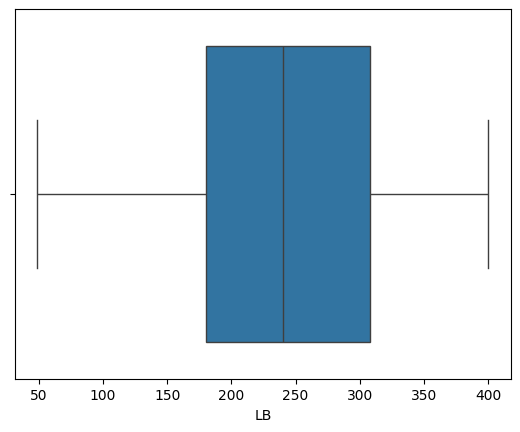

In [ ]:
# Membuat boxplot dari kolom LB (luas bangunan) khusus pada dataset listrik_outlier_all
sns.boxplot(x='LB', data=listrik_outlier_all)

### Hasil Penanganan

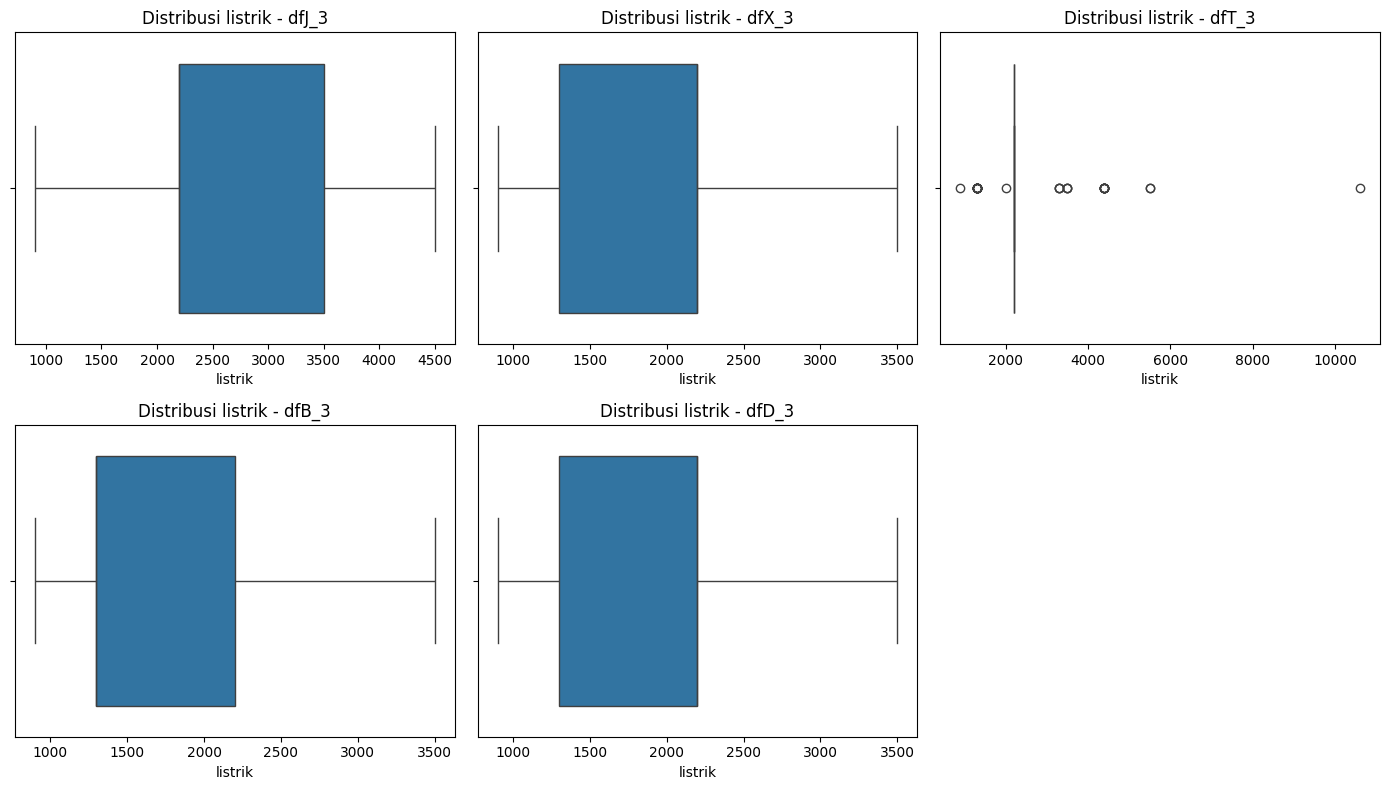

In [ ]:
# Bikin figure
plt.figure(figsize=(14, 8))

# Plot 1
plt.subplot(2, 3, 1)
sns.boxplot(x="listrik", data=dfJ_3)
plt.title("Distribusi listrik - dfJ_3")

# Plot 2
plt.subplot(2, 3, 2)
sns.boxplot(x="listrik", data=dfX_3)
plt.title("Distribusi listrik - dfX_3")

# Plot 3
plt.subplot(2, 3, 3)
sns.boxplot(x="listrik", data=dfT_3)
plt.title("Distribusi listrik - dfT_3")

# Plot 4
plt.subplot(2, 3, 4)
sns.boxplot(x="listrik", data=dfB_3)
plt.title("Distribusi listrik - dfB_3")

# Plot 5
plt.subplot(2, 3, 5)
sns.boxplot(x="listrik", data=dfD_3)
plt.title("Distribusi listrik - dfD_3")

plt.tight_layout()
plt.show()

# **Mengecek Korelasi Tiap Variabel Numerik**

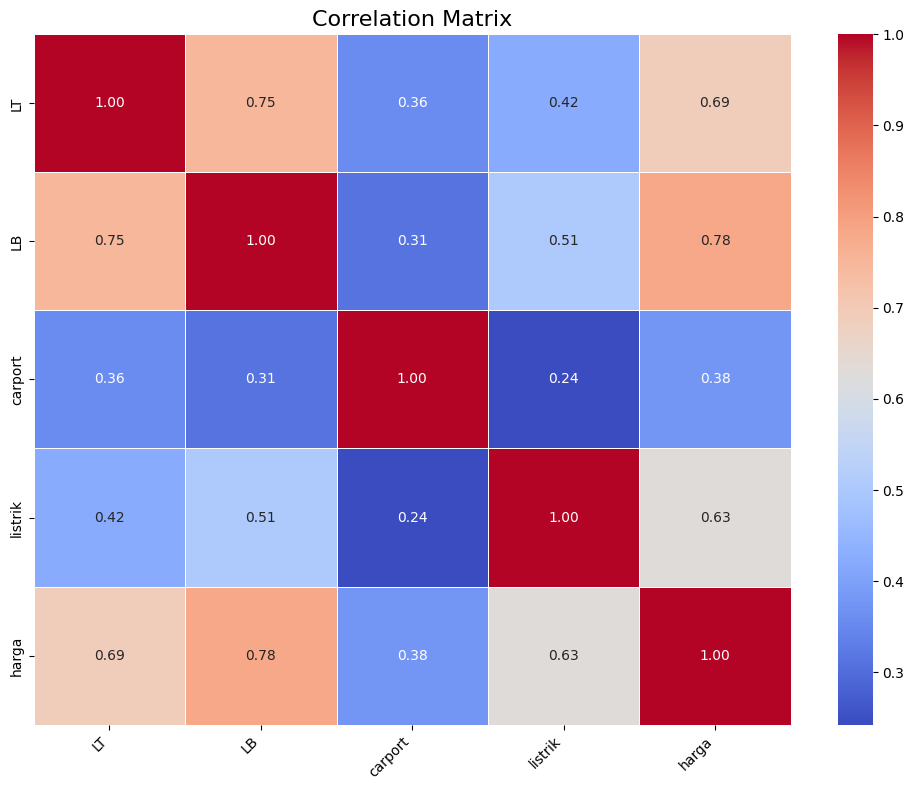

In [ ]:
# Membuat visualisasi correlation matrix dalam bentuk heatmap pada dataset Jakarta
plt.figure(figsize=(10, 8))
sns.heatmap(
    dfJ_3.select_dtypes(include=np.number).corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)
plt.title("Correlation Matrix", fontsize=16)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout()
plt.show()

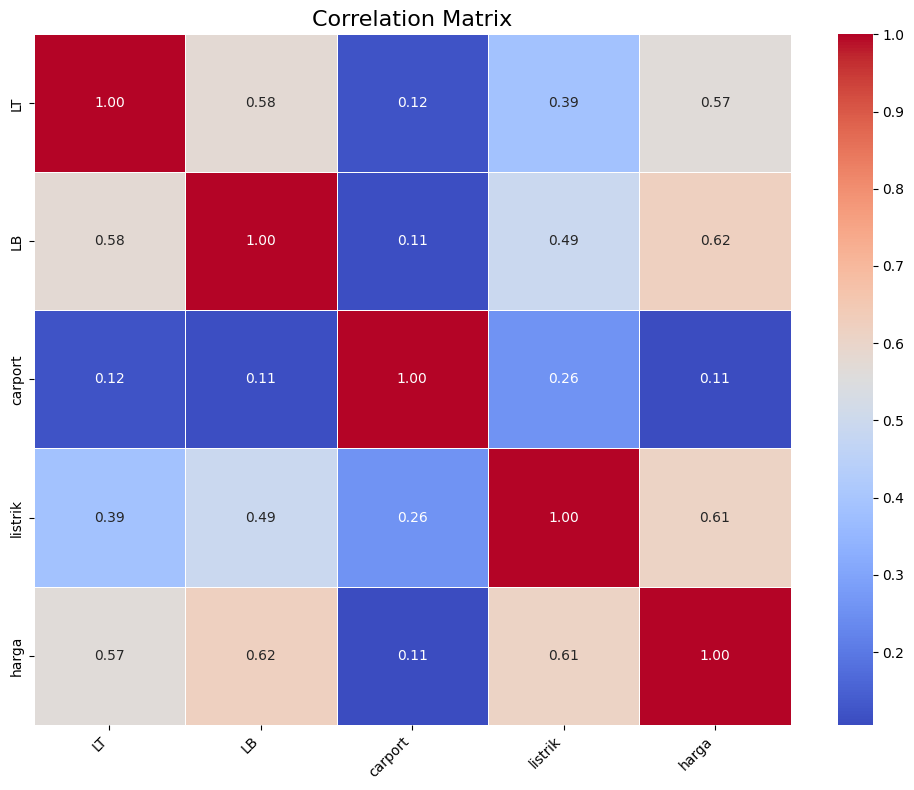

In [ ]:
# Membuat visualisasi correlation matrix dalam bentuk heatmap pada dataset Bekasi
plt.figure(figsize=(10, 8))
sns.heatmap(
    dfX_3.select_dtypes(include=np.number).corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)
plt.title("Correlation Matrix", fontsize=16)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout()
plt.show()

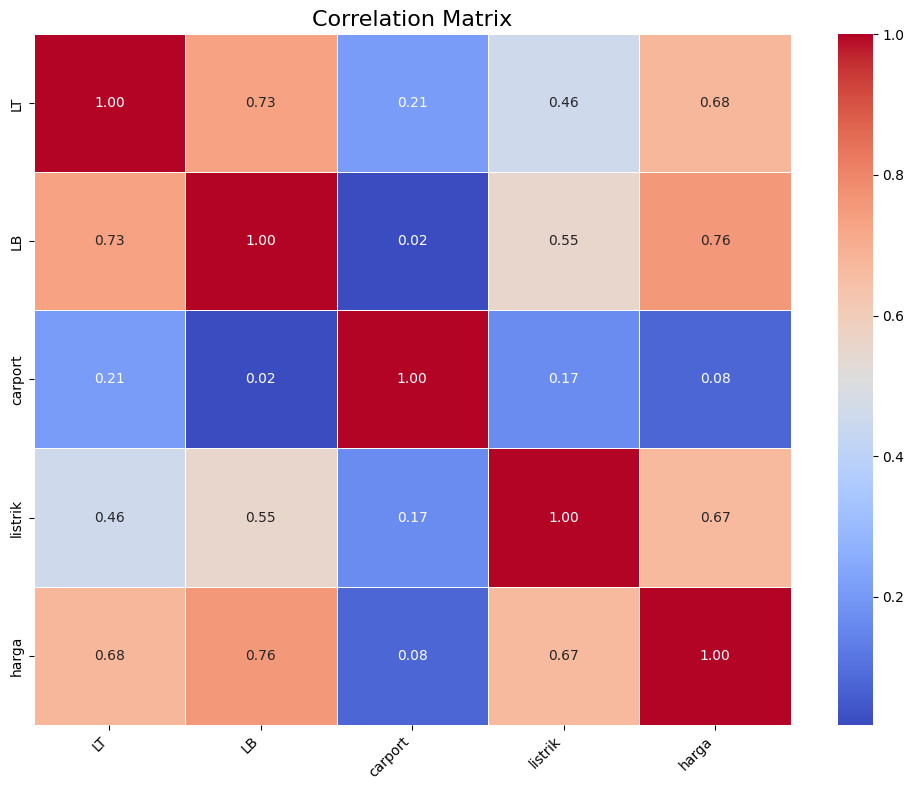

In [ ]:
# Membuat visualisasi correlation matrix dalam bentuk heatmap pada dataset Tangerang
plt.figure(figsize=(10, 8))
sns.heatmap(
    dfT_3.select_dtypes(include=np.number).corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)
plt.title("Correlation Matrix", fontsize=16)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout()
plt.show()

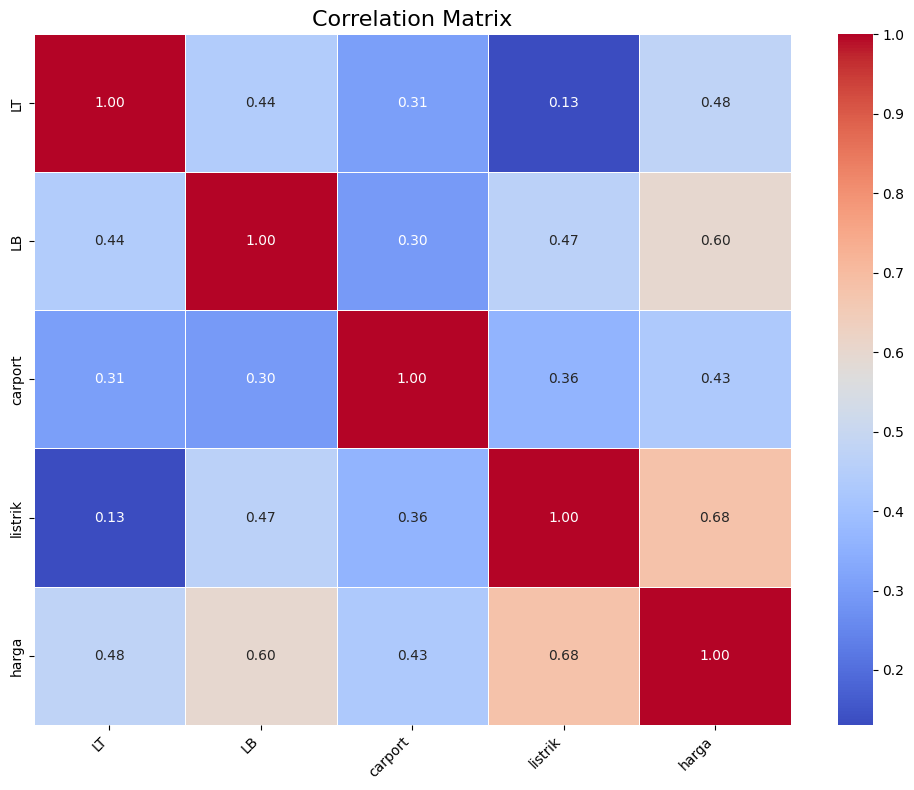

In [ ]:
# Membuat visualisasi correlation matrix dalam bentuk heatmap pada dataset Bogor
plt.figure(figsize=(10, 8))
sns.heatmap(
    dfB_3.select_dtypes(include=np.number).corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)
plt.title("Correlation Matrix", fontsize=16)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout()
plt.show()

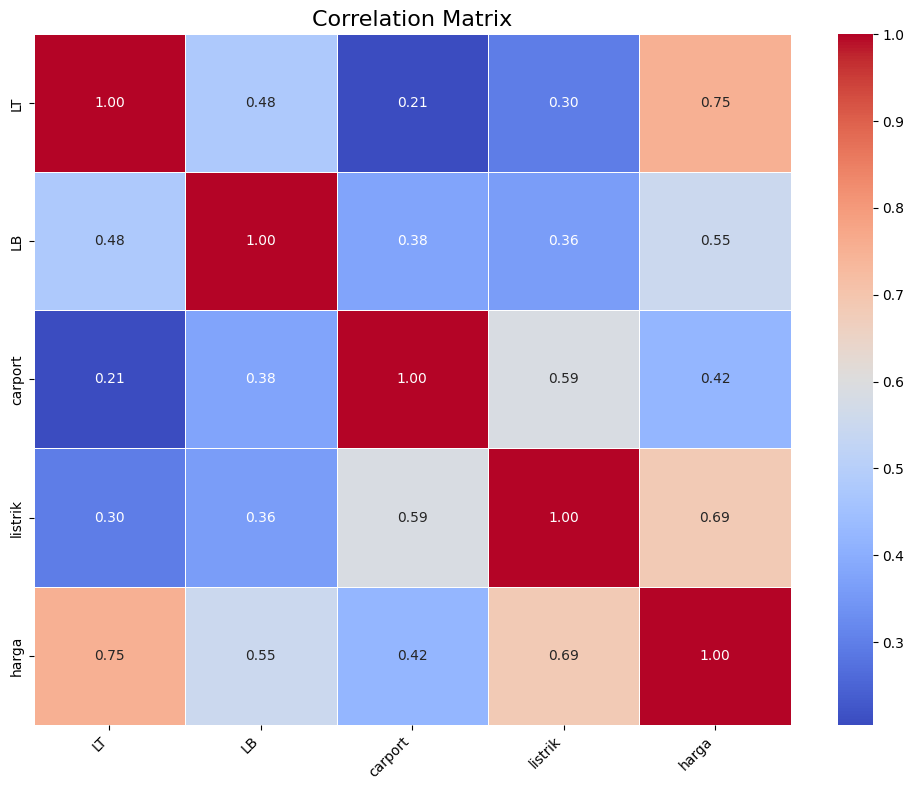

In [ ]:
# Membuat visualisasi correlation matrix dalam bentuk heatmap pada dataset Depok
plt.figure(figsize=(10, 8))
sns.heatmap(
    dfD_3.select_dtypes(include=np.number).corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)
plt.title("Correlation Matrix", fontsize=16)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout()
plt.show()

In [ ]:
# Menggabungkan seluruh dataset utama dari masing-masing kota menjadi satu DataFrame besar bernama df_all
df_all = pd.concat([
    dfJ_3,
    dfX_3,
    dfT_3,
    dfB_3,
    dfD_3
], ignore_index=True)

In [ ]:
df_all

,created_at,LT,LB,KT,KM,carport,lokasi,sertifikat,listrik,harga,URL,deskripsi,kota
0,2021-12-06,202,198,8.0,3.0,1,Jakarta Pusat,SHM,2200,4500000000,https://www.rumah.com/listing-properti/dijual-...,Dekat Cikini Salemba Taman Isamail Marzuki Kam...,Jakarta Pusat
1,2021-12-02,30,55,2.0,1.0,1,Jakarta Pusat,SHM,2200,1100000000,https://www.rumah.com/listing-properti/dijual-...,"Mengusung konsep minimalis, dan didukung denga...",Jakarta Pusat
2,2021-12-06,19,35,2.0,1.0,1,Jakarta Pusat,SHM,2200,395000000,https://www.rumah.com/listing-properti/dijual-...,"Dekat dengan Mall Atrium Senen, dekat dengan a...",Jakarta Pusat
3,2021-12-06,33,42,2.0,2.0,1,Jakarta Pusat,SHM,2200,835000000,https://www.rumah.com/listing-properti/dijual-...,"Berlokasi sangat strategis, sangat dekat ke Tu...",Jakarta Pusat
4,2021-12-06,30,55,2.0,2.0,1,Jakarta Pusat,SHM,2200,1100000000,https://www.rumah.com/listing-properti/dijual-...,"Bisa request ubah tata ruang, beli 2 unit mend...",Jakarta Pusat
...,...,...,...,...,...,...,...,...,...,...,...,...,...
486,2021-12-04,80,80,2.0,2.0,1,Cilodong,SHM,900,320000000,https://www.rumah123.com/properti/depok/hos928...,DIJUAL KONTRAKAN 2 PINTU FULL TERISI YG NGONTR...,Depok Utara
487,2021-12-04,72,45,2.0,1.0,1,Cimanggis,SHM,1300,1000000000,https://www.rumah123.com/properti/depok/hos928...,PERUMAHAN NUANSA PERMAI DEPOK,Depok Utara
488,2021-12-04,40,40,2.0,1.0,1,Cipayung,SHM,1300,195000000,https://www.rumah123.com/properti/depok/hos928...,rumah semi minimalis manis harga ekonomis di c...,Depok Tengah
489,2021-12-04,50,50,2.0,1.0,1,Cipayung,SHM,1300,185000000,https://www.rumah123.com/properti/depok/hos927...,rumah semi minimalis dua kamar siap huni di ci...,Depok Tengah


In [ ]:
df_all_outlier = pd.concat([
    lt_outlier_all,
    lb_outlier_all,
    listrik_outlier_all,
    harga_outlier_all,
], ignore_index=True)

In [ ]:
df_all_outlier[df_all_outlier['kota'] == "Kabupaten Bogor - Barat"]


,created_at,LT,LB,KT,KM,carport,lokasi,sertifikat,listrik,harga,URL,deskripsi,kota
16,2021-12-06,200,170,2.0,1.0,0,Parung,Lainnya,1300,500000000,https://www.rumah.com/listing-properti/dijual-...,1 unit rumah minimalis beserta 3 unit rumah pe...,Kabupaten Bogor - Barat


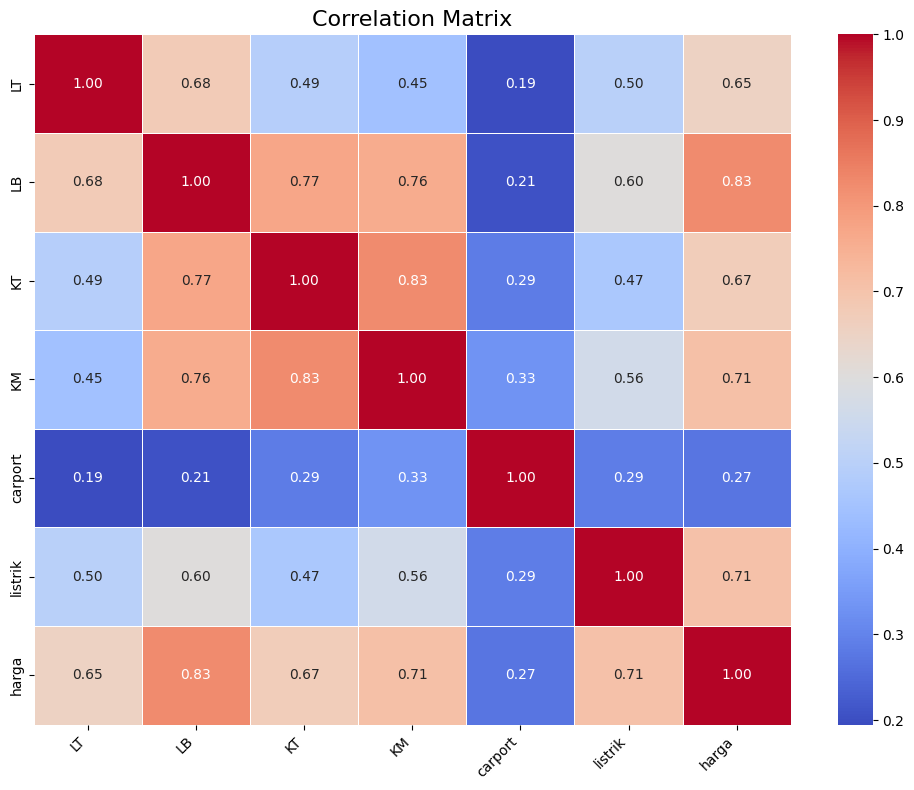

In [ ]:
plt.figure(figsize=(10, 8))
sns.heatmap(
    df_all.select_dtypes(include=np.number).corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)
plt.title("Correlation Matrix", fontsize=16)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout()
plt.show()

In [ ]:
df_all

,created_at,LT,LB,KT,KM,carport,lokasi,sertifikat,listrik,harga,URL,deskripsi,kota
0,2021-12-06,202,198,8.0,3.0,1,Jakarta Pusat,SHM,2200,4500000000,https://www.rumah.com/listing-properti/dijual-...,Dekat Cikini Salemba Taman Isamail Marzuki Kam...,Jakarta Pusat
1,2021-12-02,30,55,2.0,1.0,1,Jakarta Pusat,SHM,2200,1100000000,https://www.rumah.com/listing-properti/dijual-...,"Mengusung konsep minimalis, dan didukung denga...",Jakarta Pusat
2,2021-12-06,19,35,2.0,1.0,1,Jakarta Pusat,SHM,2200,395000000,https://www.rumah.com/listing-properti/dijual-...,"Dekat dengan Mall Atrium Senen, dekat dengan a...",Jakarta Pusat
3,2021-12-06,33,42,2.0,2.0,1,Jakarta Pusat,SHM,2200,835000000,https://www.rumah.com/listing-properti/dijual-...,"Berlokasi sangat strategis, sangat dekat ke Tu...",Jakarta Pusat
4,2021-12-06,30,55,2.0,2.0,1,Jakarta Pusat,SHM,2200,1100000000,https://www.rumah.com/listing-properti/dijual-...,"Bisa request ubah tata ruang, beli 2 unit mend...",Jakarta Pusat
...,...,...,...,...,...,...,...,...,...,...,...,...,...
486,2021-12-04,80,80,2.0,2.0,1,Cilodong,SHM,900,320000000,https://www.rumah123.com/properti/depok/hos928...,DIJUAL KONTRAKAN 2 PINTU FULL TERISI YG NGONTR...,Depok Utara
487,2021-12-04,72,45,2.0,1.0,1,Cimanggis,SHM,1300,1000000000,https://www.rumah123.com/properti/depok/hos928...,PERUMAHAN NUANSA PERMAI DEPOK,Depok Utara
488,2021-12-04,40,40,2.0,1.0,1,Cipayung,SHM,1300,195000000,https://www.rumah123.com/properti/depok/hos928...,rumah semi minimalis manis harga ekonomis di c...,Depok Tengah
489,2021-12-04,50,50,2.0,1.0,1,Cipayung,SHM,1300,185000000,https://www.rumah123.com/properti/depok/hos927...,rumah semi minimalis dua kamar siap huni di ci...,Depok Tengah


In [ ]:
df_all_outlier

,created_at,LT,LB,KT,KM,carport,lokasi,sertifikat,listrik,harga,URL,deskripsi,kota
0,2021-12-05,3422,64,1.0,1.0,1,Jakarta Pusat,SHM,2200,1050000000,https://www.rumah.com/listing-properti/dijual-...,Vlaster cempaka merupakan suatu kompleks perum...,Jakarta Pusat
1,2021-12-06,390,200,7.0,2.0,1,Jakarta Selatan,SHM,1300,3500000000,https://rumahdijual.com/tebet/11220328-dijual-...,Bangunan lama,Jakarta Selatan
2,2021-12-02,511,463,6.0,3.0,1,Jakarta Selatan,SHM,33000,4480000000,https://rumahdijual.com/tebet/11748387-jual-ru...,- Pondasi dan konstruksi beton bertulang\n- Ku...,Jakarta Selatan
3,2021-11-18,695,650,8.0,6.0,1,Jakarta Selatan,SHM,5500,9200000000,https://rumahdijual.com/tebet/9514888-rumah-cl...,"- Jumlah AC 8\n- Unfurnish, bangunan tahun 199...",Jakarta Selatan
4,2021-11-22,400,750,4.0,3.0,2,Jakarta Barat,SHM,5500,8000000000,https://www.rumah.com/listing-properti/dijual-...,NaN,Jakarta Barat
...,...,...,...,...,...,...,...,...,...,...,...,...,...
167,2021-12-06,210,250,4.0,4.0,1,Cimanggis,SHM,7700,2100000000,https://www.rumah123.com/properti/depok/hos928...,RUMAH DALAM KOMPLEK BESAR. JLN LEBAR. DEPOK,Depok Utara
168,2021-12-06,200,150,3.0,2.0,1,Cinere,SHM,2200,2000000000,https://www.rumah123.com/properti/depok/hos928...,"BEBAS BANJIR SEPANJANG MASA, BUKIT CINERE INDA...",Depok Selatan
169,2021-12-05,120,105,3.0,3.0,2,Cinere,SHM,2200,1970000000,https://www.rumah123.com/properti/depok/hos928...,Cluster strategis murah best area Cinere dkt t...,Depok Selatan
170,2021-12-03,364,494,5.0,2.0,1,Kota Bekasi,SHM,11000,2485000000,https://www.iklanrumah.com/list/detail/37392/r...,Rumah Mewah Pondok Pekayon Indah Siap Huni di ...,Kota Bekasi


In [ ]:
df_all_outlier.duplicated().sum()

np.int64(0)

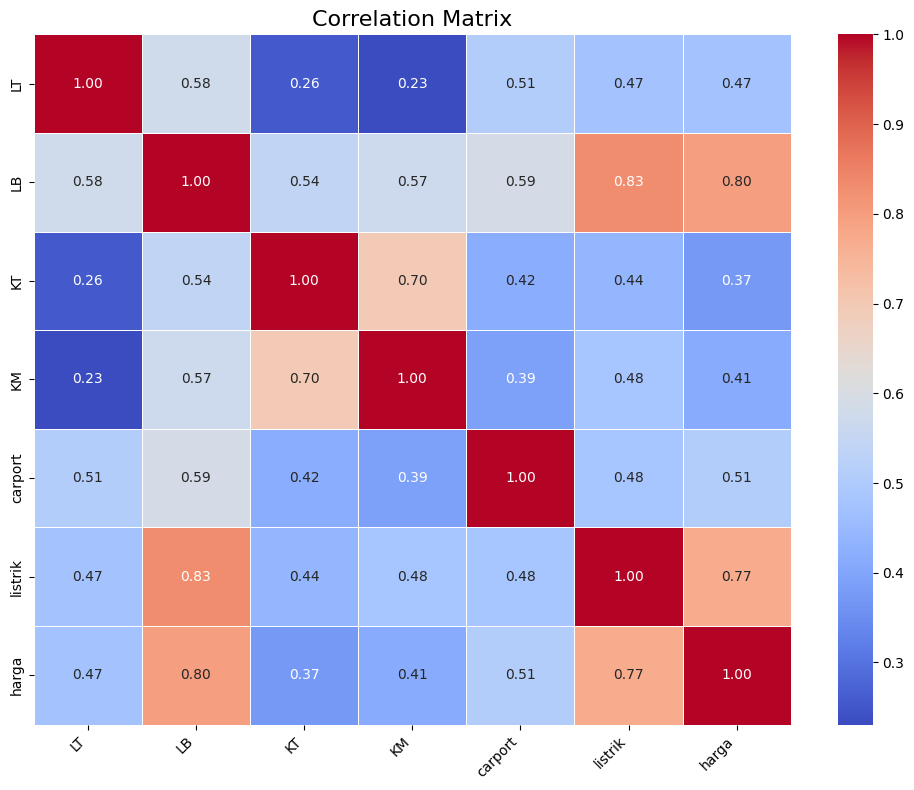

In [ ]:
plt.figure(figsize=(10, 8))
sns.heatmap(
    df_all_outlier.select_dtypes(include=np.number).corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)
plt.title("Correlation Matrix", fontsize=16)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout()
plt.show()

In [ ]:
df_all_outlier['kota'].value_counts()

,count
kota,
KOTA TANGERANG SELATAN,29
Kota Bogor,21
Jakarta Selatan,18
Kabupaten Bogor - Selatan,18
Depok Selatan,16
Kabupaten Bogor - Timur,14
Kota Bekasi,11
Depok Tengah,10
Jakarta Barat,8


In [ ]:
# Statistik harga per kota
df_all_outlier.groupby("kota")["harga"].describe()


,count,mean,std,min,25%,50%,75%,max
kota,,,,,,,,
Depok Selatan,16.0,3.123125e+09,2.328925e+09,1.100000e+09,1.700000e+09,1.885000e+09,3.900000e+09,9.000000e+09
Depok Tengah,10.0,2.247500e+09,2.052872e+09,4.050000e+08,8.600000e+08,1.460000e+09,3.150000e+09,7.000000e+09
Depok Utara,4.0,2.790000e+09,2.503358e+09,1.280000e+09,1.280000e+09,1.690000e+09,3.200000e+09,6.500000e+09
Jakarta Barat,8.0,8.934875e+09,8.939058e+09,2.400000e+09,3.924750e+09,6.575000e+09,8.972500e+09,3.000000e+10
Jakarta Pusat,6.0,4.675667e+10,3.341687e+10,1.050000e+09,3.999250e+10,4.250000e+10,4.837500e+10,1.050000e+11
Jakarta Selatan,18.0,2.121833e+10,1.983884e+10,3.500000e+09,8.487500e+09,1.200000e+10,2.950000e+10,7.400000e+10
Jakarta Timur,3.0,4.000000e+09,4.358899e+08,3.500000e+09,3.850000e+09,4.200000e+09,4.250000e+09,4.300000e+09
Jakarta Utara,7.0,1.987857e+10,1.696550e+10,2.400000e+09,7.375000e+09,8.500000e+09,3.700000e+10,3.950000e+10
KABUPATEN TANGERANG,1.0,1.160000e+10,NaN,1.160000e+10,1.160000e+10,1.160000e+10,1.160000e+10,1.160000e+10


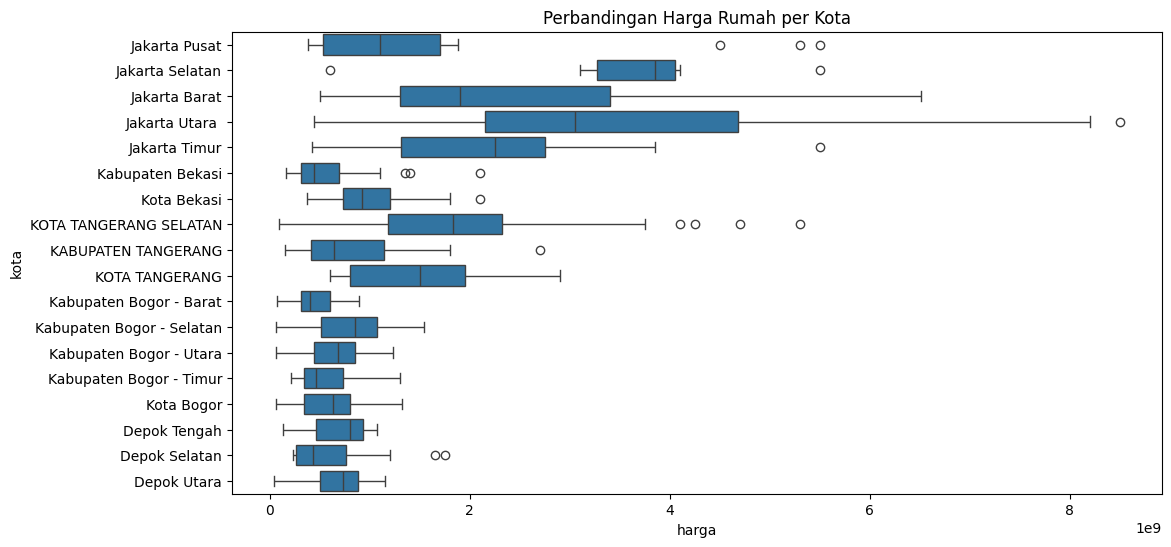

In [ ]:
# Visualisasi boxplot
plt.figure(figsize=(12,6))
sns.boxplot(x="harga", y="kota", data=df_all)
plt.xticks(rotation=0)
plt.title("Perbandingan Harga Rumah per Kota")
plt.show()

# Pertanyaan

# **1. Kualitas data yang dimiliki perusahaan.**

In [ ]:
#Missing Value
dfs1 = {
    "dfJ_2": dfJ_2,
    "dfX_2": dfX_2,
    "dfT_2": dfT_2,
    "dfB_2": dfB_2,
    "dfD_2": dfD_2
}

# Gabungkan jumlah NaN (hasilnya otomatis horizontal)
null_count = pd.DataFrame({name: df.isnull().sum() for name, df in dfs1.items()})
display(null_count)

,dfJ_2,dfX_2,dfT_2,dfB_2,dfD_2
created_at,0,0,0,0,1
LT,0,0,0,0,0
LB,0,0,0,0,2
KT,0,0,0,0,2
KM,0,1,0,0,2
garasi,77,74,86,0,95
carport,31,26,32,0,26
lokasi,0,0,0,0,2
sertifikat,2,1,2,0,2
listrik,1,6,13,0,17


Kualitas data perusahaan masih perlu ditingkatkan. Ditemukan missing values pada beberapa kolom penting di lima dataset awal, terutama pada kolom garasi, carport, dan hadap yang jumlahnya cukup banyak. Selain itu, terdapat inkonsistensi format tanggal pada kolom created_at: pada empat dataset formatnya sudah konsisten menggunakan tanggal-bulan-tahun, sedangkan pada dataset Tangerang masih menggunakan bulan-tanggal-tahun.

Beberapa outlier pada harga rumah juga terdeteksi dan berpotensi memengaruhi hasil analisis. Dari sisi data kategori, ditemukan inkonsistensi pada kolom lokasi:

- Di dataset Jakarta hanya menggunakan pembagian Jakarta Utara, Selatan, Pusat, Barat, dan Timur.

- Di dataset Bekasi hanya mencakup Kota Bekasi dan Kabupaten Bekasi.

- Sementara pada dataset Tangerang, Bogor, dan Depok, lokasi sudah lebih detail dengan pembagian berdasarkan kecamatan.

Selain itu, terdapat pula inkonsistensi pada data numerik di kolom harga, di mana dataset Tangerang dan Depok masih menggunakan format per jutaan, sedangkan dataset lain sudah dalam nilai penuh.

Secara umum, data masih dapat digunakan, namun perlu dilakukan proses data cleaning dan standarisasi agar hasil analisis lebih valid dan konsisten.

# **2. Apakah ada saran perbaikan data ke DE/DBA perusahaan agar RPPI menjadi data driven company yang unggul.**

Saran dari kami kepada DE/DBA perusahaan adalah melakukan EDA lanjutan dengan beberapa langkah perbaikan data, antara lain:

1. Menangani missing value, khususnya pada kolom garasi, carport, dan hadap yang memiliki jumlah missing cukup banyak. Untuk kolom sertifikat dan listrik dapat dilakukan imputasi dengan menggunakan modus (untuk sertifikat) dan prediksi berbasis rasio (untuk listrik). Pada tahap ini, dilakukan pengecekan missing value pada kolom listrik di setiap dataset.
- Kategori daya listrik yang ditemukan yaitu: 450, 900, 1300, 2200, 3300, 3500, 4400, 5500, 6600, 7700, 8000, 9900, 10600, 11000, 13200, 16500, 18000, 23000, 33000, dan 66000.
- Imputasi dilakukan dengan memprediksi nilai awal listrik menggunakan median rasio listrik/LB dikalikan dengan LB. Nilai prediksi tersebut kemudian dibulatkan ke kategori resmi terdekat. Misalnya, jika prediksi awal adalah 1400 maka dibulatkan ke 1300.

2. Menyeragamkan format tanggal pada kolom created_at di data Tangerang agar konsisten dengan dataset lain (menggunakan format dd-mm-yyyy).

3. Menyelaraskan kategori lokasi dengan membuat kolom baru kota.

- Untuk data Depok: kecamatan dikelompokkan menjadi Depok Selatan, Depok Utara, dan Depok Tengah.

- Untuk data Tangerang: dibagi menjadi Kota Tangerang Selatan, Kabupaten Tangerang, dan Kota Tangerang.

- Untuk data Bogor: dibagi menjadi Kabupaten Bogor Barat, Kabupaten Bogor Timur, Kabupaten Bogor Selatan, Kabupaten Bogor Utara, dan Kota Bogor.

- Untuk Jakarta dan Bekasi: karena datanya sudah berbentuk kota, maka kolom kota diisi sama dengan kolom lokasi.

4. Memperbaiki inkonsistensi format harga pada data Tangerang dan Depok, di mana harga masih dalam bentuk per jutaan. Perlu dilakukan normalisasi dengan mengalikan nilai harga dengan 1.000.000 agar konsisten dengan dataset lain.

# **3. Dari data yang ada, apakah ada kecenderungan rumah disuatu kota lebih mahal/murah dibandingkan kota lain?**

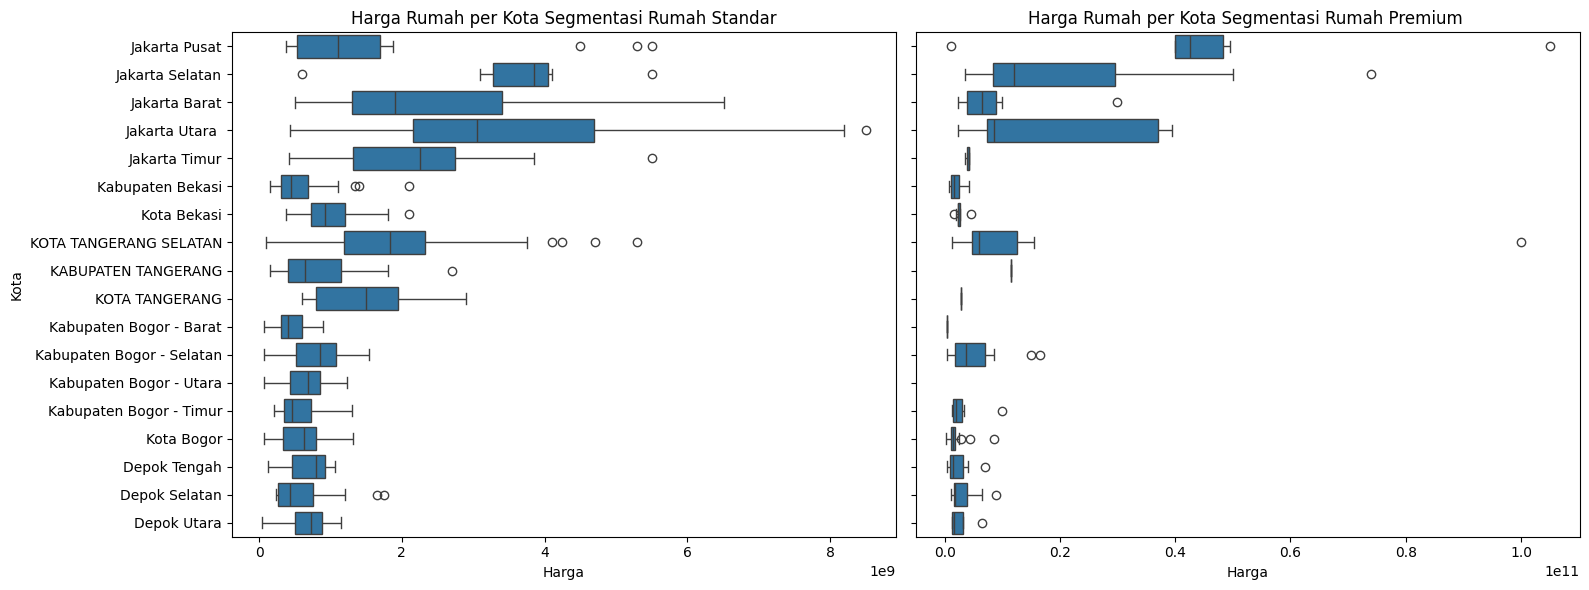

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(16,6), sharey=True)

# Plot untuk data non-outlier
sns.boxplot(x="harga", y="kota", data=df_all, ax=axes[0])
axes[0].set_title("Harga Rumah per Kota Segmentasi Rumah Standar")
axes[0].set_xlabel("Harga")
axes[0].set_ylabel("Kota")

# Plot untuk data outlier
sns.boxplot(x="harga", y="kota", data=df_all_outlier, ax=axes[1])
axes[1].set_title("Harga Rumah per Kota Segmentasi Rumah Premium ")
axes[1].set_xlabel("Harga")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()


Dari hasil visualisasi, dapat dilihat bahwa terdapat perbedaan kecenderungan harga rumah antara dua segmen:

- Segmentasi Rumah Standar (non-outlier)

Pada segmen ini, harga rumah relatif terkonsentrasi pada rentang yang lebih sempit. Kota dengan kecenderungan harga rumah lebih tinggi dibandingkan kota lain adalah Jakarta Selatan, Jakarta Pusat, dan Jakarta Utara. Sementara itu, rumah di wilayah Bogor dan Bekasi cenderung berada pada kisaran harga yang lebih rendah. Tangerang dan Depok berada di posisi menengah, dengan harga yang tidak semahal Jakarta namun lebih tinggi daripada Bogor/Bekasi.

- Segmentasi Rumah Premium (outlier)


Pada segmen premium, terlihat bahwa Jakarta (khususnya Selatan dan Utara) mendominasi dengan harga rumah jauh lebih tinggi dibandingkan kota lain. Sementara itu, kota-kota lain seperti Depok, Bekasi, Bogor, maupun Tangerang memang memiliki rumah premium, namun tidak sebanyak dan tidak semahal Jakarta.

- Kesimpulan:
Ada kecenderungan bahwa Jakarta menjadi pusat rumah dengan harga tertinggi, baik pada segmen standar maupun premium, sedangkan Bogor dan Bekasi lebih banyak menawarkan rumah dengan harga terjangkau.

# **4. Dari data yang ada, apakah bisa dibuat rekomendasi sebaiknya RPPI membuat kantor cabang berikutnya di kota mana? Mengapa? (Asumsikan RPPI belum memiliki cabang di kota-kota yang disebutkan di data).**

In [ ]:

df_all['Harga_per_m2'] = df_all['harga'] / df_all['LT']
df_all.head(
)
summary = df_all.groupby('kota').agg(
    median_harga=('harga','median'),
    median_harga_per_m2=('Harga_per_m2','median'),
    jumlah_listing=('harga','count')
).reset_index()
summary['median_harga'] = summary['median_harga']/1000000000 #miliar
summary['median_harga_per_m2'] = summary['median_harga_per_m2']/1000000 #juta
print(summary)


                         kota  median_harga  median_harga_per_m2  \
0               Depok Selatan        0.4275             6.889407   
1                Depok Tengah        0.7995            10.915480   
2                 Depok Utara        0.7280             9.919781   
3               Jakarta Barat        1.9000            21.008403   
4               Jakarta Pusat        1.1000            25.345622   
5             Jakarta Selatan        3.8500            28.414634   
6               Jakarta Timur        2.2500            18.333333   
7              Jakarta Utara         3.0500            24.303922   
8         KABUPATEN TANGERANG        0.6375             7.222222   
9              KOTA TANGERANG        1.5000            13.541667   
10     KOTA TANGERANG SELATAN        1.8300            13.082481   
11           Kabupaten Bekasi        0.4450             6.416667   
12    Kabupaten Bogor - Barat        0.4000             5.909091   
13  Kabupaten Bogor - Selatan        0.8500     

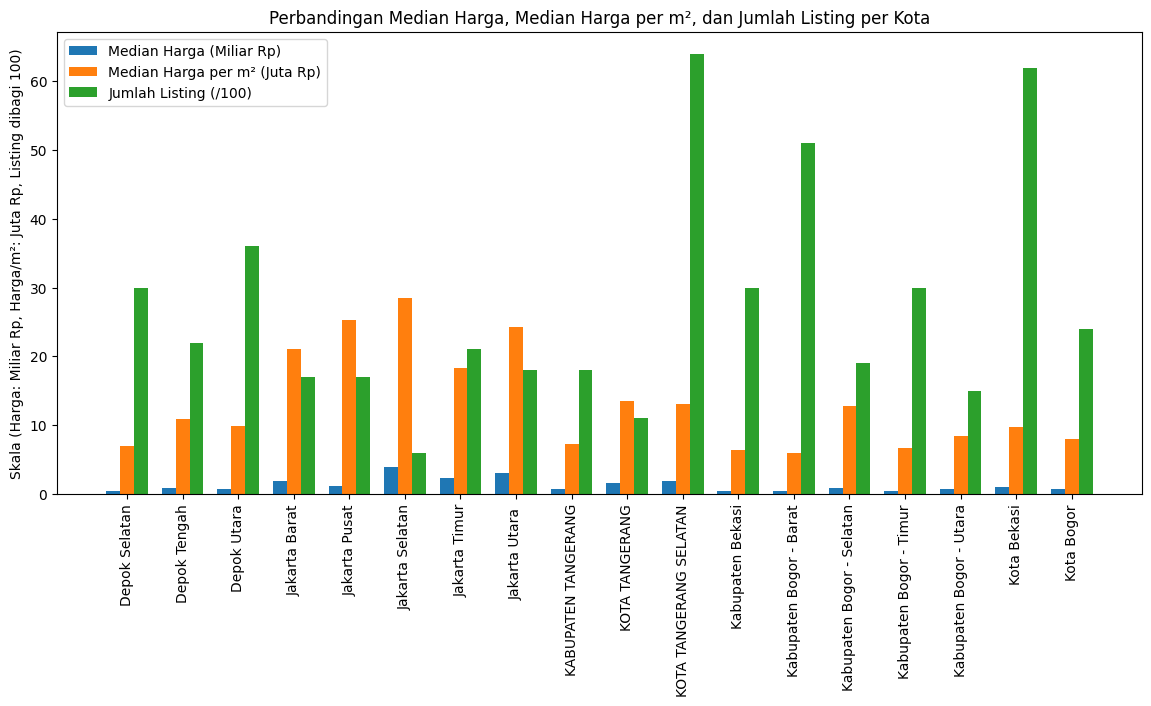

<Figure size 800x600 with 0 Axes>

In [ ]:

x = np.arange(len(summary["kota"]))  # posisi kota
width = 0.25  # lebar bar

fig, ax = plt.subplots(figsize=(14,6))

ax.bar(x - width, summary["median_harga"], width, label="Median Harga (Miliar Rp)")
ax.bar(x, summary["median_harga_per_m2"], width, label="Median Harga per m² (Juta Rp)")
ax.bar(x + width, summary["jumlah_listing"], width, label="Jumlah Listing (/100)")

ax.set_xticks(x)
ax.set_xticklabels(summary["kota"], rotation=90)
ax.set_title("Perbandingan Median Harga, Median Harga per m², dan Jumlah Listing per Kota")
ax.set_ylabel("Skala (Harga: Miliar Rp, Harga/m²: Juta Rp, Listing dibagi 100)")
ax.legend()
plt.figure(figsize=(8,6))
plt.tight_layout()
plt.show()


Berdasarkan Visualisasi diatas, kami merekomendasikan Kota Tangerang Selatan, dengan mempertimbangkan banyaknya jumlah rumah yang dijual, Median harga, dan median dari harga tanah per meter perseginya di masing-masing Kota. Dengan asumsi :


*   Banyaknya rumah yang dijual disetiap Kotanya menggambarkan seberapa aktif pasar properti di Kota tersebut.
*   Median harga rumah digunakan untuk mempertimbangkan harga aset-aset terdekat yang memungkinkan untuk di investasi.




# **5. Rumah dengan karakteristik seperti apa yang paling banyak dijual?**

In [ ]:
# Ringkasan per kota
print("\n=== Jumlah penjualan per kota ===")
print(df_all['kota'].value_counts().head(10))

# Ringkasan harga (misal rata-rata harga per kota)
print("\n=== Rata-rata harga per kota (Top 10 kota) ===")
print(df_all.groupby('kota')['harga'].mean().sort_values(ascending=False).head(10))

# Ringkasan luas tanah (misal median per kota)
print("\n=== Median LT per kota (Top 10 kota) ===")
print(df_all.groupby('kota')['LT'].median().sort_values(ascending=False).head(10))




=== Jumlah penjualan per kota ===
kota
KOTA TANGERANG SELATAN     64
Kota Bekasi                62
Kabupaten Bogor - Barat    51
Depok Utara                36
Kabupaten Bogor - Timur    30
Depok Selatan              30
Kabupaten Bekasi           30
Kota Bogor                 24
Depok Tengah               22
Jakarta Timur              21
Name: count, dtype: int64

=== Rata-rata harga per kota (Top 10 kota) ===
kota
Jakarta Utara                3.586468e+09
Jakarta Selatan              3.500000e+09
Jakarta Barat                2.459067e+09
Jakarta Timur                2.218238e+09
KOTA TANGERANG SELATAN       1.937250e+09
Jakarta Pusat                1.662235e+09
KOTA TANGERANG               1.536364e+09
Kota Bekasi                  9.857249e+08
KABUPATEN TANGERANG          8.500556e+08
Kabupaten Bogor - Selatan    8.382632e+08
Name: harga, dtype: float64

=== Median LT per kota (Top 10 kota) ===
kota
Jakarta Utara              147.0
Jakarta Selatan            132.5
KOTA TANGERANG SELAT

Kota dengan jumlah listing/penjualan terbanyak adalah Kota Tangerang Selatan,
diikuti Kota Bekasi, Kabupaten Bogor (Barat/Timur), dan Depok Utara.

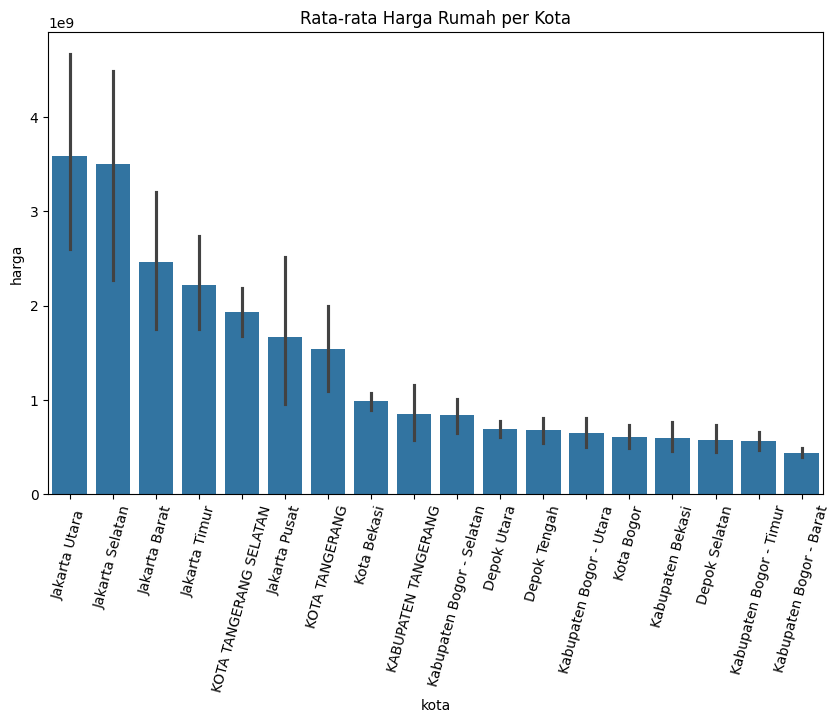

In [ ]:
# Membandingkan rata-rata harga rumah antar kota
plt.figure(figsize=(10,6))
sns.barplot(
    data=df_all,
    x='kota',
    y='harga',
    order=df_all.groupby('kota')['harga'].mean().sort_values(ascending=False).index
)
plt.xticks(rotation=75)
plt.title('Rata-rata Harga Rumah per Kota')
plt.show()

Jakarta Utara dan Jakarta Selatan memiliki harga rata-rata rumah tertinggi, sekitar ±4–5 miliar, sedangkan kota dengan volume penjualan tinggi seperti Tangerang Selatan dan Bekasi justru menawarkan harga rata-rata lebih terjangkau, yakni sekitar 1–2 miliar.


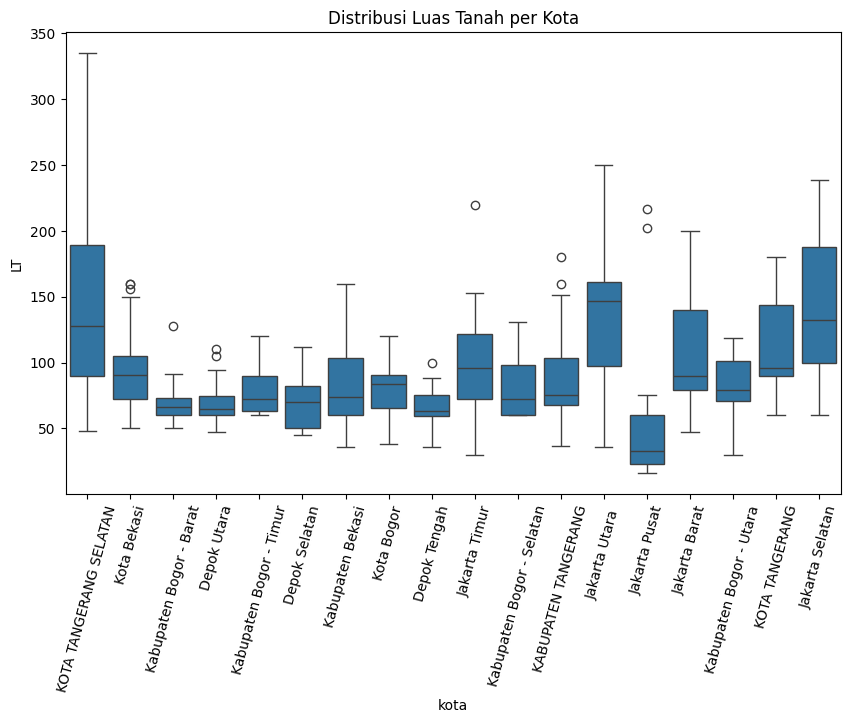

In [ ]:
# Membuat visualisasi boxplot yang menampilkan distribusi Luas Tanah (LT) untuk setiap kota dalam dataset gabungan
plt.figure(figsize=(10,6))
sns.boxplot(
    data=df_all,
    x='kota',
    y='LT',
    order=df_all['kota'].value_counts().index
)
plt.xticks(rotation=75)
plt.title('Distribusi Luas Tanah per Kota')
plt.show()

Sebagian besar kota (terutama Bekasi, Bogor, dan Depok) memiliki median luas tanah sekitar 50–100 m², sedangkan Tangerang Selatan menampilkan variasi luas tanah yang lebih lebar meskipun median-nya tetap berada pada kisaran menengah.


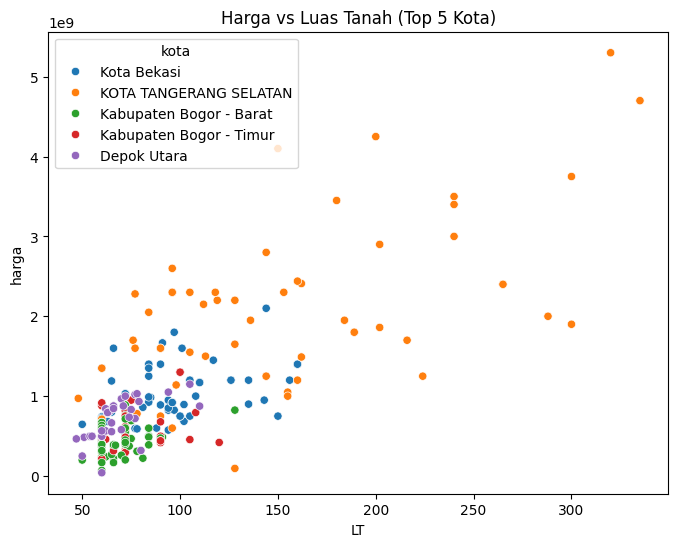

In [ ]:
# Gabungan harga dan LT dengan kota top
# Ambil hanya kota dengan penjualan terbanyak (top 5)
top_cities = df_all['kota'].value_counts().head(5).index
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=df_all[df_all['kota'].isin(top_cities)],
    x='LT', y='harga', hue='kota'
)
plt.title('Harga vs Luas Tanah (Top 5 Kota)')
plt.show()

Scatterplot menunjukkan bahwa semakin luas tanah (LT) semakin tinggi harga rumah, dengan Tangerang Selatan menampilkan sebaran harga yang lebih beragam dari kelas menengah hingga tinggi, sedangkan Bekasi dan Bogor umumnya terkonsentrasi pada harga dan luas tanah kelas menengah.

# **6. Jika RPPI ingin melakukan investasi (max) Rp. 25 Milyar minggu besok, apakah dari data anda dapat memberikan rekomendasi rumah mana saja yang akan berpotensi menghasilkan keuntungan bagi perusahaan?**

In [ ]:
# jumlah listing per kota (pasar paling aktif)
listing_per_kota = df_all['kota'].value_counts().rename_axis('kota').reset_index(name='count')
listing_per_kota


,kota,count
0,KOTA TANGERANG SELATAN,64
1,Kota Bekasi,62
2,Kabupaten Bogor - Barat,51
3,Depok Utara,36
4,Kabupaten Bogor - Timur,30
5,Depok Selatan,30
6,Kabupaten Bekasi,30
7,Kota Bogor,24
8,Depok Tengah,22
9,Jakarta Timur,21


Dapat dilihat diatas pasar yang lebih aktif ada di kota tanggerang selatan dengan 64 iklan rumah, maka kita akan merekomendasikan perumahan yang ada di kota tanggerang selatan

In [ ]:
# Filter rumah di Tangerang Selatan dengan sertifikat SHM
shortlist_tsl_shm = df_all[
    (df_all['kota'] == "KOTA TANGERANG SELATAN") &
    (df_all['sertifikat'].str.contains("SHM", case=False, na=False))
].copy()

Memfilter rumah di kota tanggerang selatan dengan sertifikat SHM karena minim resiko sengketa hukum

In [ ]:
# Urutkan harga dari yang paling murah
shortlist_tsl_shm = shortlist_tsl_shm.sort_values(by="harga", ascending=True)
shortlist_tsl_shm

,created_at,LT,LB,KT,KM,carport,lokasi,sertifikat,listrik,harga,URL,deskripsi,kota,Harga_per_m2
171,2021-12-06,60,50,3.0,2.0,1,"BSD CITY, TANGERANG",SHM,1300,500000000,https://www.rumah123.com/properti/tangerang/ho...,"Rumah 2 Lantai Akses Strategis, Keamanan 24jam...",KOTA TANGERANG SELATAN,8.333333e+06
181,2021-12-06,60,48,3.0,2.0,2,"PONDOK JAGUNG, TANGERANG",SHM,2200,600000000,https://www.rumah123.com/properti/tangerang/ho...,Memiliki lokasi yang strategis yaitu 100 meter...,KOTA TANGERANG SELATAN,1.000000e+07
189,2021-12-06,60,48,3.0,2.0,1,"SERPONG, TANGERANG SELATAN",SHM,2200,600000000,https://rumahdijual.com/bintaro/11733088-rumah...,"memiliki type hunian boston village, berdiri d...",KOTA TANGERANG SELATAN,1.000000e+07
206,2021-12-06,60,48,3.0,2.0,2,"BSD CITY, TANGERANG",SHM,2200,600000000,https://www.rumah123.com/properti/tangerang/ho...,BOSTON VILLAGE BSD- BINTARO\nAkses 100 Meter d...,KOTA TANGERANG SELATAN,1.000000e+07
218,2021-12-06,96,75,3.0,2.0,1,"BSD, TANGERANG",SHM,2200,600000000,https://www.rumah123.com/properti/tangerang/ho...,"Green Grass Ciater Bsd City, Harga di atas typ...",KOTA TANGERANG SELATAN,6.250000e+06
229,2021-12-06,90,60,2.0,1.0,1,"LIPPO KARAWACI, TANGERANG",SHM,2200,750000000,https://www.rumah123.com/properti/tangerang/ho...,"Dekat dengan halte karawaci, dekat dengan Lipp...",KOTA TANGERANG SELATAN,8.333333e+06
224,2021-12-06,72,70,3.0,2.0,1,"KARAWACI, TANGERANG",SHM,2200,756000000,https://www.rumah123.com/properti/tangerang/ho...,Lokasi strategis dekat ke Supermall Lippo Kara...,KOTA TANGERANG SELATAN,1.050000e+07
233,2021-12-06,78,40,2.0,1.0,1,"GADING SERPONG, TANGERANG",SHM,2200,780000000,https://www.rumah123.com/properti/tangerang/ho...,Dijual rumah cluster baleria,KOTA TANGERANG SELATAN,1.000000e+07
260,2021-12-08,66,70,3.0,2.0,1,"Ciater, Tangerang",SHM,1300,850000000,https://www.rumah123.com/properti/tangerang/ho...,"Berlian Ciater, Hunian 2 Lantai Nyaman dan Asr...",KOTA TANGERANG SELATAN,1.287879e+07
216,2021-12-06,78,125,4.0,2.0,1,"BSD DUTA BINTARO, TANGERANG",SHM,1300,950000000,https://www.rumah123.com/properti/tangerang/ho...,"Rumah di jual cepat, Perumahan Duta Bintaro, L...",KOTA TANGERANG SELATAN,1.217949e+07


Mengurutkan harga rumah dari yang paling murah agar mudah dalam pencarian kombinasi investasinya

In [ ]:
# Ambil 25 rumah termurah
top_tsl_shm = shortlist_tsl_shm.head(23)

# Hitung total harga
total_harga_tsl_shm = top_tsl_shm['harga'].sum()

print("Total harga rumah termurah (sertifikat SHM) di Tangerang Selatan:", total_harga_tsl_shm)

# Cek apakah sesuai budget
if total_harga_tsl_shm <= 25_000_000_000:
    print("Bisa dibeli semua dengan budget Rp 25 Miliar")
else:
    print("Tidak bisa dibeli semua, perlu kombinasi lebih kecil")

Total harga rumah termurah (sertifikat SHM) di Tangerang Selatan: 23898000000
Bisa dibeli semua dengan budget Rp 25 Miliar


In [ ]:
top_tsl_shm

,created_at,LT,LB,KT,KM,carport,lokasi,sertifikat,listrik,harga,URL,deskripsi,kota,Harga_per_m2
171,2021-12-06,60,50,3.0,2.0,1,"BSD CITY, TANGERANG",SHM,1300,500000000,https://www.rumah123.com/properti/tangerang/ho...,"Rumah 2 Lantai Akses Strategis, Keamanan 24jam...",KOTA TANGERANG SELATAN,8.333333e+06
181,2021-12-06,60,48,3.0,2.0,2,"PONDOK JAGUNG, TANGERANG",SHM,2200,600000000,https://www.rumah123.com/properti/tangerang/ho...,Memiliki lokasi yang strategis yaitu 100 meter...,KOTA TANGERANG SELATAN,1.000000e+07
189,2021-12-06,60,48,3.0,2.0,1,"SERPONG, TANGERANG SELATAN",SHM,2200,600000000,https://rumahdijual.com/bintaro/11733088-rumah...,"memiliki type hunian boston village, berdiri d...",KOTA TANGERANG SELATAN,1.000000e+07
206,2021-12-06,60,48,3.0,2.0,2,"BSD CITY, TANGERANG",SHM,2200,600000000,https://www.rumah123.com/properti/tangerang/ho...,BOSTON VILLAGE BSD- BINTARO\nAkses 100 Meter d...,KOTA TANGERANG SELATAN,1.000000e+07
218,2021-12-06,96,75,3.0,2.0,1,"BSD, TANGERANG",SHM,2200,600000000,https://www.rumah123.com/properti/tangerang/ho...,"Green Grass Ciater Bsd City, Harga di atas typ...",KOTA TANGERANG SELATAN,6.250000e+06
229,2021-12-06,90,60,2.0,1.0,1,"LIPPO KARAWACI, TANGERANG",SHM,2200,750000000,https://www.rumah123.com/properti/tangerang/ho...,"Dekat dengan halte karawaci, dekat dengan Lipp...",KOTA TANGERANG SELATAN,8.333333e+06
224,2021-12-06,72,70,3.0,2.0,1,"KARAWACI, TANGERANG",SHM,2200,756000000,https://www.rumah123.com/properti/tangerang/ho...,Lokasi strategis dekat ke Supermall Lippo Kara...,KOTA TANGERANG SELATAN,1.050000e+07
233,2021-12-06,78,40,2.0,1.0,1,"GADING SERPONG, TANGERANG",SHM,2200,780000000,https://www.rumah123.com/properti/tangerang/ho...,Dijual rumah cluster baleria,KOTA TANGERANG SELATAN,1.000000e+07
260,2021-12-08,66,70,3.0,2.0,1,"Ciater, Tangerang",SHM,1300,850000000,https://www.rumah123.com/properti/tangerang/ho...,"Berlian Ciater, Hunian 2 Lantai Nyaman dan Asr...",KOTA TANGERANG SELATAN,1.287879e+07
216,2021-12-06,78,125,4.0,2.0,1,"BSD DUTA BINTARO, TANGERANG",SHM,1300,950000000,https://www.rumah123.com/properti/tangerang/ho...,"Rumah di jual cepat, Perumahan Duta Bintaro, L...",KOTA TANGERANG SELATAN,1.217949e+07


Berdasarkan analisis terhadap 5 dataset properti, strategi investasi terbaik dengan alokasi maksimal Rp25 miliar adalah fokus pada Kota Tangerang Selatan yang memiliki jumlah listing terbanyak (64 unit). Dari kota ini, dipilih 23 rumah termurah dengan sertifikat SHM sehingga total nilai investasi mencapai ±Rp23,8 miliar, masih dalam batas anggaran.

Strategi ini logis karena:

- Kuantitas pasar: Tangerang Selatan memiliki listing terbanyak sehingga potensi penguasaan pasar lebih tinggi.

- Legalitas terjamin: Pemilihan rumah dengan sertifikat SHM meminimalkan risiko hukum.

- Harga kompetitif: Dengan membeli rumah-rumah termurah, perusahaan bisa menguasai pasar di segmen harga bawah–menengah yang perputaran transaksi cenderung lebih cepat.

- Diversifikasi risiko: Membeli banyak unit (23 rumah) di satu kota lebih aman dibandingkan membeli sedikit unit dengan harga sangat tinggi.

- Kota berkembang pesat: Tangerang Selatan merupakan kawasan yang terus bertumbuh, dengan pusat pengembangan modern seperti BSD City yang menjadikannya lokasi strategis dengan potensi kenaikan nilai properti di masa depan.

Dengan demikian, RPPI direkomendasikan untuk mengalokasikan investasinya pada 23 unit rumah SHM termurah di Tangerang Selatan sebagai strategi optimal dengan anggaran Rp25 miliar, sekaligus memanfaatkan momentum perkembangan kota yang pesat.

# **7. Dan yang terpenting, informasi berharga apa lagi yang bisa anda dapatkan dari data?**

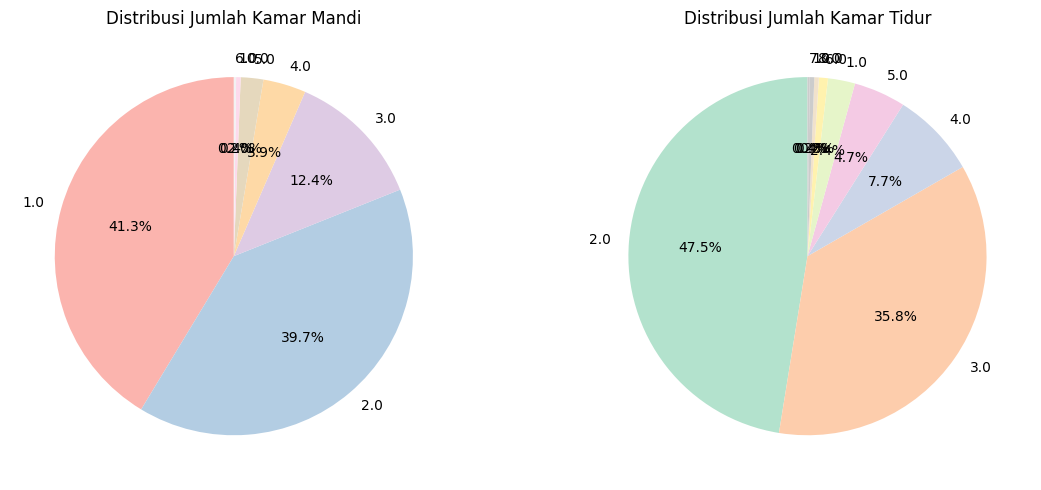

In [ ]:
# Menunjukkan proporsi tiap kategori jumlah kamar mandi dan kamar tidur
# Pie chart kamar mandi
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
df_all['KM'].value_counts().plot.pie(
    autopct='%1.1f%%', startangle=90, cmap='Pastel1'
)
plt.title('Distribusi Jumlah Kamar Mandi')
plt.ylabel('')  # menghilangkan label sumbu Y

# Pie chart kamar tidur
plt.subplot(1,2,2)
df_all['KT'].value_counts().plot.pie(
    autopct='%1.1f%%', startangle=90, cmap='Pastel2'
)
plt.title('Distribusi Jumlah Kamar Tidur')
plt.ylabel('')

plt.tight_layout()
plt.show()

Berdasarkan kedua pie chart, terlihat bahwa jumlah kamar mandi terbanyak adalah 1 kamar mandi (40,8%) disusul 2 kamar mandi (39,2%), sedangkan kategori 3 kamar mandi ke atas hanya sebagian kecil. Hal ini menunjukkan mayoritas rumah berada pada tipe yang relatif kecil hingga menengah, cocok untuk pasangan muda, keluarga kecil, atau pembeli mandiri yang belum memerlukan banyak fasilitas. Untuk jumlah kamar tidur, komposisi terbesar adalah 2 kamar tidur (46,5%) diikuti 3 kamar tidur (36,4%), sementara rumah dengan 4 kamar atau lebih sangat sedikit. Pola ini menguatkan bahwa permintaan terbesar berasal dari segmen keluarga kecil, di mana 2–3 kamar tidur dan 1–2 kamar mandi sudah dianggap memadai untuk kebutuhan sehari-hari.

/tmp/ipython-input-38364749.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_all, x='segmen_harga', order=labels, palette='Set2')


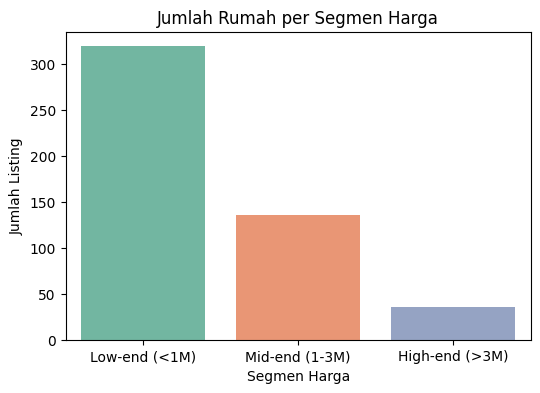

In [ ]:
# Membuat visualisasi jumlah listing rumah per segmen harga.
# Membuat kategori harga
bins = [0, 1_000_000_000, 3_000_000_000, df_all['harga'].max()]
labels = ['Low-end (<1M)', 'Mid-end (1-3M)', 'High-end (>3M)']
df_all['segmen_harga'] = pd.cut(df_all['harga'], bins=bins, labels=labels)

plt.figure(figsize=(6,4))
sns.countplot(data=df_all, x='segmen_harga', order=labels, palette='Set2')
plt.title('Jumlah Rumah per Segmen Harga')
plt.xlabel('Segmen Harga')
plt.ylabel('Jumlah Listing')
plt.show()

Berdasarkan visualisasi tersebut, dapat disimpulkan bahwa segmen low-end (<1 M) mendominasi jumlah listing rumah, diikuti segmen mid-end (1–3 M), sedangkan segmen high-end (>3 M) hanya sebagian kecil. Visualisasi ini menunjukkan bahwa pasar perumahan yang paling aktif dan potensial berada di kelas low-end, Oleh karena itu, RPPI disarankan untuk memfokuskan strategi investasi dan pemasaran pada rumah di segmen harga tersebut, karena memiliki potensi penyerapan pasar lebih tinggi dan mampu menjangkau mayoritas calon pembeli.